# Quantum Fisher information — how fast a quantum state changes under a small parameter shift

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 10 — Quantum metrology protocols*

## 1. Introduction and motivation

Optical atomic clocks, gravitational-wave interferometers and atomic magnetometers are among the most precise
instruments in physics. All three do the same thing:

1. **prepare** a quantum state,
2. let an unknown physical quantity $\theta$ (a frequency, a phase, a magnetic field) **imprint** itself on that state,
3. **measure** the state and **estimate** $\theta$ from the clicks.

This notebook determines the best precision that any measurement on a given prepared state can reach. It is set by a
single number attached to the state and to the way $\theta$ enters — the
**quantum Fisher information** $F_Q$ — and it bounds the error of every conceivable experiment through the
**quantum Cramér–Rao bound**

$$\Delta\theta \;\ge\; \frac{1}{\sqrt{M\,F_Q}},$$

where $M$ is the number of repetitions and $\Delta\theta$ the standard deviation of an unbiased estimator. Everything else in Chapter 10 — Ramsey interferometry, GHZ interferometry,
spin squeezing — is an attempt to make $F_Q$ as large as possible and then to actually reach the bound with a
realistic readout.

There is a second reason physicists care about $F_Q$. For $N$ qubits prepared independently $F_Q$ cannot exceed $N$;
any state that beats this value *must* be entangled. The quantum Fisher information is therefore an **entanglement
witness with an operational meaning**: besides certifying entanglement, it states how much that entanglement is worth
in a laboratory.

**Road map.**

* **Sections 3–4 — estimation theory for any meter.** The estimation problem (parameter, meter, readings, estimator,
  bias, variance), the score and the classical Fisher information in its two forms, additivity over repetitions, and the
  Cramér–Rao bound derived from the Cauchy–Schwarz inequality, with efficient estimators and the asymptotic efficiency
  of maximum likelihood. The running examples are two classical meters, a thermometer read with Gaussian noise and a
  biased coin.
* **Sections 5–6 — the quantum meter.** The Born rule turns $\rho_\theta$ into a distribution of readings; the symmetric
  logarithmic derivative and the quantum Fisher information; the Braunstein–Caves inequality $F_C\le F_Q$ proved step by
  step; for pure states the analytic reduction $F_Q=4\,\mathrm{Var}(G)$ and its meaning as the speed of the state.
* **Sections 7–10 — the protocol and the two limits.** Prepare, encode, measure, estimate; error propagation; the
  product state and the standard quantum limit $F_Q=N$, the GHZ state and the Heisenberg limit $F_Q=N^2$, checked on state
  vectors and in a simulated estimation; then the fragility of the GHZ advantage under particle loss, independent and
  collective dephasing, and imperfect readout.
* **Sections 11–13 — many-body states.** A zoo of standard states and Ising ground states, the $3\times3$ QFI matrix and
  the optimal generator direction, and the QFI as an entanglement witness.
* **Sections 14–16 — noise, loss and cost.** QFI of mixed states under three noise channels, QFI of a subsystem after
  particle loss with a Schmidt-compression algorithm, and measured run times.

### What you will learn

*Physics*

* how any measuring device is described by a statistical model, what the score and the Fisher information are, and why
  an unbiased estimator cannot do better than the Fisher information allows;
* what the symmetric logarithmic derivative is, why the quantum Fisher information bounds every measurement, and why for
  pure states it equals four times the variance of the generator;
* why a product state of $N$ qubits gives $F_Q\le N$ (the standard quantum limit) and why no state gives more than $N^2$
  (the Heisenberg limit), with both proofs, and why the GHZ advantage is destroyed by a single lost particle and decays
  at a rate growing with $N$ under dephasing, with $N^2$ under collective noise;
* which many-body states are metrologically useful, which are not, and why a highly entangled state can offer no
  gain over a product state (Haar-random states, and cluster states up to a boundary term, are the instructive
  counter-examples);

*Numerical methods*

* the Cauchy–Schwarz proofs of the Cramér–Rao bound and of the Braunstein–Caves inequality, additivity of Fisher
  information, asymptotic efficiency of maximum likelihood;
* variance of a collective operator computed matrix-free in $O(N2^N)$ instead of $O(4^N)$;
* a $3\times3$ eigenvalue problem that replaces an optimisation over the sphere of generator directions;
* the symmetric-logarithmic-derivative formula in the eigenbasis of $\rho$, plus a rank-revealing **QR compression** that reduces an
  $O(8^{K})$ eigendecomposition to $O(8^{N-K})$ for the reduced state of $K$ kept qubits.

*Implementation practice*

* `jax.vmap` over Monte-Carlo repetitions, random states and parameter sweeps; explicit PRNG keys;
* `jax.jit` with static qubit indices and traced arrays; compile time separated from run time;
* validating a physical quantity three ways (matrix-free, dense, analytic) before trusting a single plot.

### Prerequisites
* [01 — JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, PRNG keys;
* [02 — einsum from scratch](../ch01_computational_toolbox/02_einsum_from_scratch.ipynb): index notation as executable code;
* [05 — matrix-free operators](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb): states as rank-$N$ tensors, `apply_gate`;
* [06 — states, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb): reduced density
  matrices, Schmidt decomposition;
* [07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb):
  density tensors, Kraus channels;
* [08 — measurements](../ch03_matrix_free_engine/08_measurements.ipynb): Born rule, sampling, shot noise;
* helpful: [22 — GHZ states and decoherence](../ch08_quantum_information_protocols/22_ghz_states_and_decoherence.ipynb).

**What comes next.** The notebook that follows,
[30 — QFI from the SLD: prepare, encode, estimate](../ch10_quantum_metrology_protocols/30_qfi_from_the_sld_prepare_encode_estimate.ipynb),
builds the symmetric logarithmic derivative of mixed states numerically, treats the kernel of $\rho$, and constructs
the optimal measurement explicitly.
Then come the protocols: [31 — Ramsey interferometry](../ch10_quantum_metrology_protocols/31_ramsey_interferometry.ipynb),
[32 — GHZ interferometry and the Heisenberg limit](../ch10_quantum_metrology_protocols/32_ghz_interferometry_heisenberg_limit.ipynb),
[33 — spin squeezing by one-axis twisting](../ch10_quantum_metrology_protocols/33_spin_squeezing_one_axis_twisting.ipynb) and
[34 — the full one-axis-twisting to GHZ protocol](../ch10_quantum_metrology_protocols/34_oat_to_ghz_full_metrology_protocol.ipynb).
This notebook supplies the theory they all use.

**Conventions.** Qubit $q$ = tensor axis $q$; $\vert 0\rangle$ is the $+1$ eigenstate of $Z$. Collective spin operators are
$J_a=\tfrac12\sum_{q}\sigma^a_q$ for $a=x,y,z$, so a single qubit carries spin $1/2$ and $J_a$ has eigenvalues between
$-N/2$ and $+N/2$. The parameter is imprinted by $U(\theta)=e^{-i\theta G}$ with a Hermitian **generator** $G$; unless
said otherwise $G=J_{\mathbf n}=\mathbf n\cdot\mathbf J$ for a unit vector $\mathbf n$. With this convention the two
limits read $F_Q\le N$ and $F_Q\le N^2$ without factors of $4$.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and notebook helpers

From the engine we reuse the state constructors, `apply_gate` / `apply_gate_dm` (the einsum that applies a small matrix to
chosen axes of a state or density tensor), the Kraus channels, `apply_collective` (the matrix-free
$\sum_q P_q$), `qfi_pure`, `qfi_mixed`, `collective_dense`, `spin_moments`, and the Lanczos ground-state solver.
Everything specific to this notebook is built below from scratch.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; g = Kraus index, summed!)
        "gea,gfc,abcd->ebfd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1; e, f = new ket0, bra0]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def dicke_state(N, k):
    """Symmetric Dicke state |D_N^k>: equal superposition of all basis states with exactly k ones.
    Implementation: mask of the flat indices with popcount == k, normalised by sqrt(binom(N,k))."""
    idx = np.arange(2 ** N)
    pop = np.array([bin(i).count("1") for i in idx])
    v = (pop == k).astype(np.complex128)
    return jnp.asarray(v / np.linalg.norm(v), dtype=CDTYPE).reshape((2,) * N)

def w_state(N):
    """W state = Dicke state with one excitation: (|10..0> + |01..0> + ... + |0..01>)/sqrt(N)."""
    return dicke_state(N, 1)

def cluster_state(N, periodic=False):
    """1D cluster (graph) state: |+>^N followed by CZ on every bond.  Stabilisers K_i = Z_{i-1} X_i Z_{i+1}."""
    psi = product_state("+" * N)
    for q in range(N - 1):
        psi = apply_gate(psi, CZ, [q, q + 1])
    if periodic and N > 2:
        psi = apply_gate(psi, CZ, [N - 1, 0])
    return psi

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string(psi, ops):
    """<psi|P|psi> = <psi | (P psi)> : apply the string, then ONE inner product (jnp.vdot conjugates its
    first argument).  Works for strings of any weight, e.g. the N-body correlator <X X ... X>."""
    return jnp.real(jnp.vdot(psi, apply_pauli_string(psi, ops)))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def purity(rho_mat):
    """Tr(rho^2): 1 for pure states, 1/d for the maximally mixed state in dimension d."""
    return jnp.real(jnp.trace(rho_mat @ rho_mat))

def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_depolarizing(p):
    """Depolarising channel  rho -> (1-p) rho + (p/3)(X rho X + Y rho Y + Z rho Z).
    Kraus: sqrt(1-p) 1, sqrt(p/3) X, sqrt(p/3) Y, sqrt(p/3) Z.   Bloch vector shrinks by 1 - 4p/3."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p / 3) * X, jnp.sqrt(p / 3) * Y, jnp.sqrt(p / 3) * Z])

def kraus_dephasing(p):
    """Dephasing (phase-flip) channel  rho -> (1-p) rho + p Z rho Z : coherences rho_01 -> (1-2p) rho_01."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p) * Z])

def kraus_amplitude_damping(g):
    """Amplitude damping (T1 decay |1> -> |0> with probability g):
        K0 = [[1,0],[0,sqrt(1-g)]]   (no decay -- but the amplitude of |1> shrinks: 'no click' is information)
        K1 = [[0,sqrt(g)],[0,0]]     (decay event = sqrt(g) sigma^-)."""
    K0 = jnp.array([[1, 0], [0, jnp.sqrt(1 - g)]], dtype=CDTYPE)
    K1 = jnp.array([[0, jnp.sqrt(g)], [0, 0]], dtype=CDTYPE)
    return jnp.stack([K0, K1])


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)

def lanczos_ground_state(terms, N, m=80, key=None, restarts=3):
    """Ground state (E_0, |psi_0>) from restarted Lanczos: diagonalise the small T, map its lowest
    eigenvector back with V, use it as the next start vector.  Extremal eigenvalues converge first."""
    key = jax.random.PRNGKey(0) if key is None else key
    v = haar_state(key, N)
    mv = jax.jit(lambda p: apply_hamiltonian(terms, p))
    E = None
    for _ in range(restarts):
        a, b, V = lanczos(mv, v, m)
        w, S_ = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
        v = jnp.tensordot(jnp.asarray(S_[:, 0], dtype=CDTYPE), V, axes=1)
        v = v / jnp.linalg.norm(v)
        E = w[0]
    return float(E), v


# ----------------------------------------------------------------------------
# 11. Collective spins, spin squeezing, quantum Fisher information
# ----------------------------------------------------------------------------
def apply_collective(psi, P, qubits=None):
    """(sum_q P_q)|psi> for a single-qubit operator P -- N einsums, O(N 2^N).  Note: NO factor 1/2 here;
    the collective spin is J_a = (1/2) sum_q sigma^a_q."""
    qubits = range(psi.ndim) if qubits is None else qubits
    out = jnp.zeros_like(psi)
    for q in qubits:
        out = out + apply_gate(psi, P, [q])
    return out

def qfi_pure(psi, P=Z, qubits=None):
    """Quantum Fisher information of a pure state for the phase imprinted by exp(-i theta J),
    J = (1/2) sum_q P_q:
        F_Q = 4 Var(J) = <G^2> - <G>^2   with G = sum_q P_q = 2J.
    Cramer-Rao: Delta theta >= 1/sqrt(M F_Q).  Product states F_Q <= N (standard quantum limit);
    GHZ: F_Q = N^2 (Heisenberg limit).   Matrix-free: |phi> = G|psi>,  <G^2> = <phi|phi>,  <G> = <psi|phi>."""
    phi = apply_collective(psi, P, qubits)
    return jnp.real(jnp.vdot(phi, phi)) - jnp.real(jnp.vdot(psi, phi)) ** 2

def qfi_mixed(rho_mat, G_mat, tol=1e-12):
    """QFI of a MIXED state (symmetric-logarithmic-derivative formula), rho = sum_m l_m |m><m|:
        F_Q = 2 sum_{m,n : l_m+l_n>0} (l_m - l_n)^2/(l_m + l_n) |<m|G|n>|^2       (G = generator, e.g. J).
    Reduces to 4 Var(G) for pure states.  Dense eigendecomposition -> use on small / reduced states."""
    lam, v = jnp.linalg.eigh(rho_mat)
    G = v.conj().T @ G_mat @ v
    num = (lam[:, None] - lam[None, :]) ** 2
    den = lam[:, None] + lam[None, :]
    return 2 * jnp.sum(jnp.where(den > tol, num / jnp.where(den > tol, den, 1.0), 0.0) * jnp.abs(G) ** 2)

def collective_dense(P, n):
    """Dense J = (1/2) sum_q P_q on n qubits (input of `qfi_mixed`), built from the matrix-free action
    on the basis vectors (vmap), exactly like `dense_hamiltonian`."""
    eye = jnp.eye(2 ** n, dtype=CDTYPE).reshape((2 ** n,) + (2,) * n)
    return 0.5 * jax.vmap(lambda e: apply_collective(e, P).reshape(-1))(eye).T

def spin_moments(psi):
    """Mean collective spin <J_a> (shape 3) and symmetrised covariance matrix
        C_ab = (1/2)<J_a J_b + J_b J_a> - <J_a><J_b>          (shape 3x3).
    Trick: |phi_a> = J_a|psi>  =>  <J_a J_b> = <phi_a|phi_b>, and its real part is the symmetrised moment."""
    phis = [0.5 * apply_collective(psi, P) for P in (X, Y, Z)]
    mean = jnp.stack([jnp.real(jnp.vdot(psi, p)) for p in phis])
    second = jnp.stack([jnp.stack([jnp.real(jnp.vdot(a, b)) for b in phis]) for a in phis])
    return mean, second - jnp.outer(mean, mean)

def oat_evolve(psi, chi_t):
    """One-axis twisting  exp(-i chi t J_z^2)  applied EXACTLY.
    J_z is diagonal in the computational basis with eigenvalue m(s) = sum_q (1/2 - s_q), so the evolution
    multiplies each amplitude by a phase exp(-i chi t m^2): O(2^N), no Trotter error, no gates.
    m(s) is assembled by BROADCASTING N arrays of shape (1,..,2,..,1) -- a tensor-network-free way of
    writing a sum over sites.   [Note: chi sum_{i<j} Z_i Z_j = 2 chi J_z^2 - chi N/2.]"""
    N = psi.ndim
    m = sum(jnp.array([0.5, -0.5]).reshape([2 if a == q else 1 for a in range(N)]) for q in range(N))
    return psi * jnp.exp(-1j * chi_t * m ** 2)


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers used throughout this notebook
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def timed(f, *args, budget=0.3, min_reps=5, max_reps=500):
    """Return (result, compile_time, best_run_time): the first call includes tracing+compilation, the rest do not.

    JAX is asynchronous, so every timed value must be forced with `block_until_ready` -- otherwise one
    measures the time to *dispatch* the work, not to do it.  We repeat for a fixed time `budget` and report
    the MINIMUM: on a shared machine the mean measures the operating system, the minimum measures the code.
    """
    t0 = time.time()
    out = jax.block_until_ready(f(*args))
    t_compile = time.time() - t0
    best, n, t_start = np.inf, 0, time.time()
    while n < min_reps or (time.time() - t_start < budget and n < max_reps):
        t0 = time.time()
        out = jax.block_until_ready(f(*args))
        best = min(best, time.time() - t0)
        n += 1
    return out, t_compile, best

## 3. The estimation problem

### 3.1 Parameter, meter, readings, estimator

We want to determine a real number $\theta$ that we cannot observe directly — a phase, a frequency, a field strength,
the quantity shown by any measuring instrument — with the best accuracy that the available data allow. We learn about
$\theta$ through a **meter**: a physical system that responds to $\theta$ and that we can read out. A liquid-column
thermometer is a familiar example. The height of the column depends on the quantity being measured through a
calibration curve $h(\theta)$, and when we read the scale we obtain a number $x$ that scatters around $h(\theta)$,
because the reading is noisy. Repeated readings are therefore random, and the only thing we can say in advance is how
they are distributed. That distribution is the probability density (for continuous readings) or the probability (for
discrete readings)

$$p(x\vert\theta),\qquad p(x\vert\theta)\ge0,\qquad \sum_x p(x\vert\theta)=1 , \tag{1}$$

where for continuous $x$ the sum stands for an integral $\int dx$. The function $p(x\vert\theta)$, known to us as a
function of both arguments, is the **statistical model** of the meter. For the thermometer with Gaussian reading noise
of standard deviation $\sigma$ it is

$$p(x\vert\theta)=\frac{1}{\sqrt{2\pi\sigma^2}}\exp\!\left[-\frac{\left(x-h(\theta)\right)^2}{2\sigma^2}\right] . \tag{2}$$

Everything in Sections 3 and 4 uses only $p(x\vert\theta)$ and is valid for any meter, classical or quantum. Section 5
specialises to a meter that is a quantum system.

We repeat the reading $M$ times under identical conditions. The readings $x_1,\dots,x_M$ are independent, so their
joint distribution is the product

$$p(x_1,\dots,x_M\vert\theta)=\prod_{j=1}^{M}p(x_j\vert\theta) . \tag{3}$$

From the data we compute a number

$$\hat\theta=\hat\theta(x_1,\dots,x_M), \tag{4}$$

called an **estimator** of $\theta$. An estimator is a rule that turns data into a guess; for the thermometer with a
linear calibration $h(\theta)=h_0+\kappa\theta$ the natural rule is to average the readings and invert the calibration,
$\hat\theta=(\bar x-h_0)/\kappa$ with $\bar x=\tfrac1M\sum_jx_j$. Since the data are random, $\hat\theta$ is a random
variable, and its statistics are described by expectation values over the joint distribution,

$$\mathbb{E}_\theta[f]=\sum_{x_1,\dots,x_M}p(x_1,\dots,x_M\vert\theta)\,f(x_1,\dots,x_M) . \tag{5}$$

The subscript $\theta$ reminds us that the average is taken with the true value of the parameter. Two numbers describe
how good an estimator is, its **bias** and its **variance**,

$$\mathrm{bias}(\hat\theta)=\mathbb{E}_\theta[\hat\theta]-\theta,\qquad
  \mathrm{Var}(\hat\theta)=\mathbb{E}_\theta\!\left[\left(\hat\theta-\mathbb{E}_\theta[\hat\theta]\right)^2\right], \tag{6}$$

and the overall error is the **mean squared error** $\mathrm{MSE}(\hat\theta)=\mathbb{E}_\theta[(\hat\theta-\theta)^2]$.
The two pieces combine in a simple way. Insert $\pm\mathbb{E}_\theta[\hat\theta]$ and expand the square, abbreviating
$\mu=\mathbb{E}_\theta[\hat\theta]$:

$$\begin{aligned}
\mathrm{MSE}(\hat\theta)&=\mathbb{E}_\theta\!\left[\left((\hat\theta-\mu)+(\mu-\theta)\right)^2\right]\\
&=\mathbb{E}_\theta\!\left[(\hat\theta-\mu)^2\right]+2(\mu-\theta)\,\mathbb{E}_\theta\!\left[\hat\theta-\mu\right]+(\mu-\theta)^2\\
&=\mathrm{Var}(\hat\theta)+2(\mu-\theta)\cdot0+\mathrm{bias}(\hat\theta)^2 ,
\end{aligned}$$

where we used that $\mu-\theta$ is a constant and $\mathbb{E}_\theta[\hat\theta-\mu]=\mu-\mu=0$. Hence

$$\mathrm{MSE}(\hat\theta)=\mathrm{Var}(\hat\theta)+\mathrm{bias}(\hat\theta)^2 . \tag{7}$$

An estimator is **unbiased** if its bias vanishes for every $\theta$. The bound derived in Section 4.5 needs less. An
estimator is **locally unbiased** at the working point $\theta_0$ if

$$\mathbb{E}_{\theta}[\hat\theta]\Big\vert_{\theta=\theta_0}=\theta_0
  \qquad\text{and}\qquad
  \frac{\partial}{\partial\theta}\mathbb{E}_{\theta}[\hat\theta]\Big\vert_{\theta=\theta_0}=1 , \tag{8}$$

so that on average it follows small changes of $\theta$ around $\theta_0$ correctly. An unbiased estimator is locally
unbiased at every point. Unbiasedness is a convenient property, but Eq. (7) shows that a slightly biased estimator
with a much smaller variance can have the smaller error. The bound we are heading for is a
statement about (locally) unbiased estimators, so we keep track of the distinction.

### 3.2 A second meter: the biased coin

The thermometer has continuous readings. The simplest meter with discrete readings is a coin that lands heads ($x=1$)
with unknown probability $\theta$ and tails ($x=0$) with probability $1-\theta$,

$$p(x\vert\theta)=\theta^{x}(1-\theta)^{1-x},\qquad x\in\{0,1\} . \tag{9}$$

Flip it $M$ times and count the heads $k=\sum_jx_j$. Two estimators suggest themselves,

$$\hat\theta_{\text{mean}}=\frac{k}{M},\qquad\text{and}\qquad
  \hat\theta_{\text{Lap}}=\frac{k+1}{M+2}\quad\text{(Laplace's rule of succession)} . \tag{10}$$

The first is unbiased because $\mathbb{E}[k]=M\theta$, and its variance is $\mathrm{Var}(k)/M^2=\theta(1-\theta)/M$.
The second is pulled towards $1/2$ and is therefore biased. We simulate both.

In [4]:
# ==============================================================================
# STEP 1: the coin experiment -- two estimators, measured bias and variance
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
THETA_COIN = 0.30          # the "unknown" probability of heads
N_REPEAT   = 20_000        # how many independent experiments we simulate (Monte-Carlo sample size)
M_LIST     = (10, 100, 1000)   # number of flips per experiment
# -----------------------------------------------------------------------------


def coin_experiments(key, theta, M, n_repeat):
    """Simulate `n_repeat` independent experiments of `M` Bernoulli(theta) flips; return the head counts.

    MATH   k ~ Binomial(M, theta).
    JAX    one (n_repeat, M) array of booleans, summed along the flip axis: no Python loop at all.
    """
    flips = jax.random.bernoulli(key, theta, (n_repeat, M))
    return jnp.sum(flips, axis=1)


print(f"true theta = {THETA_COIN}\n")
print(f"{'M':>6s} | {'bias(k/M)':>12s} {'Var(k/M)':>12s} {'theta(1-theta)/M':>18s} | "
      f"{'bias(Laplace)':>14s} {'Var(Laplace)':>13s}")
for M in M_LIST:
    k = coin_experiments(jax.random.PRNGKey(0), THETA_COIN, M, N_REPEAT)
    mean_est = k / M
    lap_est = (k + 1) / (M + 2)
    var_theory = THETA_COIN * (1 - THETA_COIN) / M
    print(f"{M:6d} | {float(jnp.mean(mean_est)) - THETA_COIN:+12.5f} {float(jnp.var(mean_est)):12.3e} "
          f"{var_theory:18.3e} | {float(jnp.mean(lap_est)) - THETA_COIN:+14.5f} {float(jnp.var(lap_est)):13.3e}")
    # the sample mean is unbiased; the Monte-Carlo error of a mean over N_REPEAT samples is sqrt(Var/N_REPEAT)
    assert abs(float(jnp.mean(mean_est)) - THETA_COIN) < 5 * np.sqrt(var_theory / N_REPEAT)

true theta = 0.3

     M |    bias(k/M)     Var(k/M)   theta(1-theta)/M |  bias(Laplace)  Var(Laplace)


    10 |     +0.00299    2.127e-02          2.100e-02 |       +0.03582     1.477e-02


   100 |     -0.00014    2.123e-03          2.100e-03 |       +0.00379     2.040e-03


  1000 |     +0.00023    2.098e-04          2.100e-04 |       +0.00063     2.090e-04


The measured variance of the sample mean matches $\theta(1-\theta)/M$ to about $1\%$ (the printed values are $1.3\%$,
$1.1\%$ and $0.1\%$ off), which is the statistical precision of a variance estimated from $20\,000$ experiments,
$\sqrt{2/20\,000}=1\%$; its bias is zero within the Monte-Carlo error, as the assert requires. Laplace's estimator is
visibly biased: its exact bias is $\mathbb{E}[(k+1)/(M+2)]-\theta=(1-2\theta)/(M+2)$, i.e. $+0.033$ at $M=10$ (the
printed $+0.036$ also contains the sampling fluctuation of $k$ that shows up as $+0.003$ in the first column), and it
shrinks like $1/M$. Its variance, exactly $M\theta(1-\theta)/(M+2)^2$, is *smaller* than that of the sample mean at every
$M$. That is the bias–variance trade-off of Eq. (7) in one line of output, and the reason why the coming bound has to
say "unbiased" explicitly.

## 4. Classical estimation theory: score, Fisher information, Cramér–Rao bound

### 4.1 The log-likelihood and the score

Fix the reading $x$ and regard $p(x\vert\theta)$ as a function of $\theta$. In this role it is called the
**likelihood** of $\theta$, and its logarithm $\ln p(x\vert\theta)$ the **log-likelihood**. The rate at which the
log-likelihood changes with $\theta$ is the **score**,

$$s(x\vert\theta)=\frac{\partial}{\partial\theta}\ln p(x\vert\theta)
  =\frac{\partial_\theta p(x\vert\theta)}{p(x\vert\theta)} , \tag{11}$$

defined for every reading with $p(x\vert\theta)>0$. The score measures how strongly the reading $x$ discriminates
between $\theta$ and a neighbouring value $\theta+d\theta$: if $p(x\vert\theta)$ barely changes with $\theta$, the score is
small and the reading carries little information about $\theta$.

The score evaluated at the true parameter has mean zero. Multiply Eq. (11) by $p(x\vert\theta)$, sum over $x$, and
exchange the derivative with the sum:

$$\begin{aligned}
\mathbb{E}_\theta\!\left[s(x\vert\theta)\right]
 &=\sum_x p(x\vert\theta)\,\frac{\partial_\theta p(x\vert\theta)}{p(x\vert\theta)}
  =\sum_x\partial_\theta p(x\vert\theta)\\
 &=\partial_\theta\sum_x p(x\vert\theta)=\partial_\theta\,1=0 .
\end{aligned} \tag{12}$$

The exchange of derivative and sum in the second line is the **regularity condition** that runs through the whole
theory. It holds when the set of possible readings does not depend on $\theta$ and $p(x\vert\theta)$ is differentiable in
$\theta$ there (for a finite set of readings this is all that is needed; for continuous readings the integral must also
converge uniformly, which is the case for Eq. (2)). Equation (12) holds only at the true value. The
expectation over data drawn at $\theta$ of the score evaluated at a different point $\theta'$ is in general non-zero,
and this is what makes the score useful for estimation: the maximum-likelihood estimator of Section 4.8 is the point
where the score of the observed data vanishes.

### 4.2 The classical Fisher information, in two forms

The **classical Fisher information** is the mean square of the score,

$$F_C(\theta)=\mathbb{E}_\theta\!\left[s(x\vert\theta)^2\right]
  =\sum_x p(x\vert\theta)\left(\frac{\partial_\theta p(x\vert\theta)}{p(x\vert\theta)}\right)^2
  =\sum_x\frac{\left(\partial_\theta p(x\vert\theta)\right)^2}{p(x\vert\theta)} . \tag{13}$$

Because the score has mean zero, $F_C$ is also its variance, $F_C=\mathrm{Var}_\theta(s)$. The last form of
Eq. (13) is the working formula: the squared sensitivity of each outcome probability, divided by that probability.

A second form expresses $F_C$ through the curvature of the log-likelihood. Differentiate the score once more, with the
quotient rule:

$$\frac{\partial^2}{\partial\theta^2}\ln p
  =\frac{\partial}{\partial\theta}\left(\frac{\partial_\theta p}{p}\right)
  =\frac{\partial^2_\theta p}{p}-\frac{\left(\partial_\theta p\right)^2}{p^2}
  =\frac{\partial^2_\theta p}{p}-s^2 . \tag{14}$$

Take the expectation of both sides. The first term gives

$$\mathbb{E}_\theta\!\left[\frac{\partial^2_\theta p}{p}\right]=\sum_x\partial^2_\theta p(x\vert\theta)
  =\partial^2_\theta\sum_xp(x\vert\theta)=\partial^2_\theta\,1=0 , \tag{15}$$

again by the regularity condition, now applied to the second derivative. The second term gives $-F_C$. Therefore

$$F_C(\theta)=-\,\mathbb{E}_\theta\!\left[\frac{\partial^2}{\partial\theta^2}\ln p(x\vert\theta)\right] . \tag{16}$$

Equation (16) explains the name: $F_C$ is the average curvature of the log-likelihood. A sharply curved
log-likelihood singles out a narrow range of $\theta$, and the data determine the parameter well.

### 4.3 Additivity over repetitions

For $M$ independent readings the joint distribution is the product of Eq. (3), so the log-likelihood is a sum and
the score of the whole data set is the sum of the single-reading scores,

$$s_M(x_1,\dots,x_M\vert\theta)=\frac{\partial}{\partial\theta}\sum_{j=1}^M\ln p(x_j\vert\theta)
  =\sum_{j=1}^Ms(x_j\vert\theta) . \tag{17}$$

Its mean square is a double sum. The terms with $j\neq k$ factorise because the readings are independent, and each
factor vanishes by Eq. (12); the $M$ terms with $j=k$ are each equal to $F_C$:

$$\begin{aligned}
F_C^{(M)}(\theta)=\mathbb{E}_\theta\!\left[s_M^2\right]
 &=\sum_{j=1}^M\mathbb{E}_\theta\!\left[s(x_j\vert\theta)^2\right]
  +\sum_{j\neq k}\mathbb{E}_\theta\!\left[s(x_j\vert\theta)\right]\mathbb{E}_\theta\!\left[s(x_k\vert\theta)\right]\\
 &=M\,F_C(\theta)+0 .
\end{aligned} \tag{18}$$

Fisher information adds up over independent repetitions. This is the origin of the familiar $1/\sqrt M$ improvement of
precision with the number of repetitions.

### 4.4 Two worked examples

**The thermometer.** From Eq. (2), $\ln p=-\tfrac12\ln(2\pi\sigma^2)-(x-h(\theta))^2/(2\sigma^2)$, so with
$h'=dh/d\theta$ the score and its derivative are

$$s(x\vert\theta)=\frac{\left(x-h(\theta)\right)h'(\theta)}{\sigma^2},\qquad
  \frac{\partial^2}{\partial\theta^2}\ln p=\frac{-h'(\theta)^2+\left(x-h(\theta)\right)h''(\theta)}{\sigma^2} . \tag{19}$$

The reading has mean $\mathbb{E}_\theta[x]=h(\theta)$ and variance $\mathbb{E}_\theta[(x-h)^2]=\sigma^2$. Hence
$\mathbb{E}_\theta[s]=h'(\mathbb{E}_\theta[x]-h)/\sigma^2=0$, as Eq. (12) requires, and the two forms of the
Fisher information give

$$F_C=\frac{h'^2}{\sigma^4}\,\mathbb{E}_\theta\!\left[(x-h)^2\right]=\frac{h'^2}{\sigma^2},\qquad
  -\mathbb{E}_\theta\!\left[\partial_\theta^2\ln p\right]=\frac{h'^2-h''\cdot0}{\sigma^2}=\frac{h'^2}{\sigma^2} . \tag{20}$$

A meter is informative when its response $h'$ is steep compared with its reading noise $\sigma$. The curvature $h''$ of
the calibration curve does not enter.

**The coin.** From Eq. (9), $\ln p=x\ln\theta+(1-x)\ln(1-\theta)$, so

$$s(x\vert\theta)=\frac{x}{\theta}-\frac{1-x}{1-\theta},\qquad
  \frac{\partial^2}{\partial\theta^2}\ln p=-\frac{x}{\theta^2}-\frac{1-x}{(1-\theta)^2} . \tag{21}$$

The mean of the score is $\theta\cdot\tfrac1\theta-(1-\theta)\cdot\tfrac{1}{1-\theta}=0$. The mean square, with $s(1)=1/\theta$
and $s(0)=-1/(1-\theta)$, is

$$F_C=\theta\cdot\frac{1}{\theta^2}+(1-\theta)\cdot\frac{1}{(1-\theta)^2}=\frac1\theta+\frac{1}{1-\theta}
  =\frac{1}{\theta(1-\theta)} , \tag{22}$$

and the curvature form gives the same, $-\mathbb{E}[\partial^2_\theta\ln p]=\theta/\theta^2+(1-\theta)/(1-\theta)^2$.
$F_C$ grows without bound as $\theta\to0$ or $1$, because the variance $\theta(1-\theta)/M$ of the head frequency
vanishes there, and it is smallest at $\theta=1/2$.

The code below checks Eqs. (12), (13) and (16) for both meters. The derivatives
$\partial_\theta\ln p$ and $\partial_\theta^2\ln p$ are taken by automatic differentiation of the log-likelihood, the sums
over the two coin outcomes are exact, and the integrals over the thermometer reading are done on a fine grid. Two wrong
controls must fail: the score evaluated at a wrong parameter value $\theta'\neq\theta$ does not average to zero, and the
curvature summed without the weights $p(x\vert\theta)$ does not reproduce $F_C$. Finally, the Fisher information of
Eq. (13) is evaluated once more with a finite-difference derivative of the probabilities and once with forward-mode
automatic differentiation; these two helper functions are used for the rest of the notebook.

In [5]:
# ==============================================================================
# STEP 2: score and classical Fisher information -- Eqs. (12), (13), (16)
# ==============================================================================
def score_moments(log_p, theta, xs, weights, theta_score=None):
    """Mean of the score, mean square of the score, and minus the mean curvature of the log-likelihood.

    MATH   s(x|t) = d/dt log p(x|t);   E_theta[f] = sum_x w_x p(x|theta) f(x)
           returns ( E[s(x|t)],  E[s(x|t)^2],  -E[d^2/dt^2 log p(x|t)] )  evaluated at t = theta_score
           (default t = theta; a different t is the "wrong parameter" control).
    ARGS   log_p(x, t): scalar log-likelihood;  xs: array of readings;  weights: 1 for a discrete set of readings,
           the grid spacing dx for a quadrature over continuous readings.
    JAX    jax.grad differentiates log_p with respect to its 2nd argument; jax.vmap maps over the readings.
    """
    t = theta if theta_score is None else theta_score
    p = jnp.exp(jax.vmap(log_p, in_axes=(0, None))(xs, theta)) * weights
    d1 = jax.grad(log_p, argnums=1)
    d2 = jax.grad(d1, argnums=1)
    s = jax.vmap(d1, in_axes=(0, None))(xs, t)
    c = jax.vmap(d2, in_axes=(0, None))(xs, t)
    return float(jnp.sum(p * s)), float(jnp.sum(p * s ** 2)), float(-jnp.sum(p * c))


def coin_log_p(x, t):
    """Eq. (9): log p(x|t) = x log t + (1 - x) log(1 - t),  x in {0, 1}."""
    return x * jnp.log(t) + (1 - x) * jnp.log(1 - t)


# PARAMETERS of the thermometer model, Eq. (2) -- arbitrary units, nonlinear calibration curve -------------
H0, KAPPA, LAMBDA, SIGMA = 50.0, 2.0, 0.05, 0.5      # h(t) = H0 + KAPPA t + LAMBDA t^2,  reading noise SIGMA
THETA_TH = 20.0                                      # working point
# ----------------------------------------------------------------------------------------------------------------


def column_height(t):
    """Calibration curve h(t) of the thermometer: the mean reading at parameter t."""
    return H0 + KAPPA * t + LAMBDA * t ** 2


def thermo_log_p(x, t):
    """Eq. (2): Gaussian reading noise of width SIGMA around h(t)."""
    return -0.5 * jnp.log(2 * jnp.pi * SIGMA ** 2) - (x - column_height(t)) ** 2 / (2 * SIGMA ** 2)


x_grid = jnp.linspace(column_height(THETA_TH) - 12 * SIGMA, column_height(THETA_TH) + 12 * SIGMA, 4001)
dx = float(x_grid[1] - x_grid[0])
h_prime = KAPPA + 2 * LAMBDA * THETA_TH
models = {"coin, theta=0.3": (coin_log_p, THETA_COIN, jnp.array([0.0, 1.0]), 1.0,
                              1 / (THETA_COIN * (1 - THETA_COIN)), THETA_COIN + 0.1),
          "thermometer": (thermo_log_p, THETA_TH, x_grid, dx, h_prime ** 2 / SIGMA ** 2, THETA_TH + 0.1)}
print(f"{'model':>16s} | {'E[s]':>10s} {'E[s^2]':>12s} {'-E[d2 log p]':>13s} {'analytic F_C':>13s} | "
      f"{'E[s] at theta + 0.1':>20s}")
for name, (log_p, th, xs, w, f_exact, th_wrong) in models.items():
    m1, m2, curv = score_moments(log_p, th, xs, w)
    m1_wrong, _, _ = score_moments(log_p, th, xs, w, theta_score=th_wrong)
    print(f"{name:>16s} | {m1:+10.2e} {m2:12.8f} {curv:13.8f} {f_exact:13.8f} | {m1_wrong:+20.5f}")
    # CHECKPOINT: zero-mean score, Eq. (12), and the two forms of F_C, Eqs. (13) and (16)
    assert abs(m1) < 1e-8 * np.sqrt(f_exact) and abs(m2 - f_exact) < 1e-8 * f_exact and abs(curv - f_exact) < 1e-8 * f_exact
    # WRONG CONTROL: the score at theta' != theta does not average to zero
    assert abs(m1_wrong) > 1e-2 * np.sqrt(f_exact)
# WRONG CONTROL: for the coin, the curvature summed WITHOUT the weights p(x|theta) is 1/theta^2 + 1/(1-theta)^2
d2_coin = jax.grad(jax.grad(coin_log_p, argnums=1), argnums=1)
unweighted_coin = -float(d2_coin(0.0, THETA_COIN) + d2_coin(1.0, THETA_COIN))
assert abs(unweighted_coin - 1 / (THETA_COIN * (1 - THETA_COIN))) > 1.0
print(f"wrong control, coin: curvature summed without the weights p(x|theta) = {unweighted_coin:.5f}")
print(f"\nthermometer: F_C = h'^2/sigma^2 with h' = {h_prime:.2f}, sigma = {SIGMA}  ->  {h_prime ** 2 / SIGMA ** 2:.4f}")


def fisher_information(prob_fn, theta, eps=1e-6, tol=1e-14):
    """Classical Fisher information of a discrete model, Eq. (13), with a central-difference derivative.

    MATH   F_C(theta) = sum_x (d p(x|theta)/d theta)^2 / p(x|theta)      [terms with p = 0 are dropped]
    ARGS   prob_fn: theta -> array of probabilities p(x|theta) summing to 1.
    JAX    `jnp.where` guards the division so that zero-probability outcomes contribute exactly 0
           (and produce no NaN inside a jit-ted/vmapped computation).
    """
    p = prob_fn(theta)
    dp = (prob_fn(theta + eps) - prob_fn(theta - eps)) / (2 * eps)
    ok = p > tol
    return jnp.sum(jnp.where(ok, dp ** 2 / jnp.where(ok, p, 1.0), 0.0))


def fisher_information_ad(prob_fn, theta, tol=1e-14):
    """The same quantity with an EXACT derivative from forward-mode automatic differentiation.

    JAX   `jax.jacfwd` pushes a tangent of the (real) input through `prob_fn`; no step size, no truncation error.
    """
    p = prob_fn(theta)
    dp = jax.jacfwd(prob_fn)(theta)
    ok = p > tol
    return jnp.sum(jnp.where(ok, dp ** 2 / jnp.where(ok, p, 1.0), 0.0))


def coin_probs(theta):
    """p(x|theta) for one Bernoulli flip, as the array [p(tails), p(heads)]."""
    return jnp.stack([1 - theta, theta])


# --- CHECKPOINT: Eq. (13) from the probabilities vs the analytic Eq. (22) ------------------
print(f"\n{'theta':>6s} | {'F_C (finite diff)':>18s} {'F_C (jacfwd)':>13s} {'1/(theta(1-theta))':>20s}")
for th in (0.1, 0.3, 0.5, 0.7, 0.9):
    i_fd = float(fisher_information(coin_probs, th))
    i_ad = float(fisher_information_ad(coin_probs, th))
    i_ex = 1.0 / (th * (1 - th))
    print(f"{th:6.2f} | {i_fd:18.8f} {i_ad:13.8f} {i_ex:20.8f}")
    assert abs(i_ad - i_ex) < 1e3 * TOL and abs(i_fd - i_ex) < 1e-5

           model |       E[s]       E[s^2]  -E[d2 log p]  analytic F_C |  E[s] at theta + 0.1


 coin, theta=0.3 |  +0.00e+00   4.76190476    4.76190476    4.76190476 |             -0.41667


     thermometer |  +1.72e-15  64.00000000   64.00000000   64.00000000 |             -6.42402
wrong control, coin: curvature summed without the weights p(x|theta) = 13.15193

thermometer: F_C = h'^2/sigma^2 with h' = 4.00, sigma = 0.5  ->  64.0000

 theta |  F_C (finite diff)  F_C (jacfwd)   1/(theta(1-theta))


  0.10 |        11.11111111   11.11111111          11.11111111
  0.30 |         4.76190476    4.76190476           4.76190476
  0.50 |         4.00000000    4.00000000           4.00000000
  0.70 |         4.76190476    4.76190476           4.76190476
  0.90 |        11.11111111   11.11111111          11.11111111


For both meters the score averages to zero to round-off, and the mean square of the score and the mean curvature of the
log-likelihood agree with the analytic values of Eqs. (22) and (20) to at least eight digits. The
thermometer uses a curved calibration ($h''=2\lambda\neq0$), so the agreement of the curvature form also confirms that
the $h''$ term drops out on average, as Eq. (20) states. Both wrong controls fail visibly: the score
evaluated $0.1$ away from the true parameter has the mean $-0.42$ for the coin and $-6.4$ for the thermometer (for the
thermometer it is $(h(\theta)-h(\theta'))h'(\theta')/\sigma^2$ by Eq. (19)), and the unweighted curvature of the
coin is $13.15$ instead of $4.76$.

In the second table both derivatives reproduce Eq. (22). Automatic differentiation is exact to machine
precision; the finite difference agrees to a few times $10^{-10}$ (not visible in the eight printed digits). For the
coin this deviation is pure round-off, of order $10^{-16}/\epsilon$: the probabilities are linear in $\theta$, so the
truncation error of the central difference vanishes. For a generic smooth model the truncation error $O(\epsilon^2)$ adds
to the round-off $O(\epsilon^{-1}\cdot10^{-16})$, and the sum is smallest near $\epsilon\approx10^{-5}$.

> **Numerical practice.** Whenever you need $\partial_\theta$ of something a JAX function computes, reach for
> `jax.jacfwd` / `jax.grad` first: no step size to tune, no cancellation. Keep the finite difference as an *independent*
> check — the two routes fail in completely different ways, so their agreement is real evidence.

### 4.5 The Cramér–Rao bound

**Theorem (Cramér–Rao).** Let $\hat\theta(x_1,\dots,x_M)$ be an estimator that is locally unbiased at $\theta$,
Eq. (8), computed from $M$ independent readings of a regular model with Fisher information $F_C(\theta)>0$. Then

$$\mathrm{Var}(\hat\theta)\;\ge\;\frac{1}{M\,F_C(\theta)} . \tag{23}$$

*Proof.* Write $\mathbf x=(x_1,\dots,x_M)$ for the whole data set, $p(\mathbf x\vert\theta)$ for its distribution,
Eq. (3), and $s_M(\mathbf x\vert\theta)$ for its score, Eq. (17). The proof has four steps.

*Step 1: the covariance of estimator and score.* Since $\mathbb{E}_\theta[s_M]=0$ by Eq. (12),

$$\mathrm{Cov}(\hat\theta,s_M)=\mathbb{E}_\theta[\hat\theta\,s_M]-\mathbb{E}_\theta[\hat\theta]\,\mathbb{E}_\theta[s_M]
  =\mathbb{E}_\theta[\hat\theta\,s_M] . \tag{24}$$

*Step 2: this covariance equals one.* Insert the definition of the score and exchange derivative and sum (regularity);
the estimator does not depend on $\theta$, only on the data:

$$\begin{aligned}
\mathbb{E}_\theta[\hat\theta\,s_M]
 &=\sum_{\mathbf x}\hat\theta(\mathbf x)\,p(\mathbf x\vert\theta)\,\frac{\partial_\theta p(\mathbf x\vert\theta)}{p(\mathbf x\vert\theta)}
  =\sum_{\mathbf x}\hat\theta(\mathbf x)\,\partial_\theta p(\mathbf x\vert\theta)\\
 &=\partial_\theta\sum_{\mathbf x}\hat\theta(\mathbf x)\,p(\mathbf x\vert\theta)
  =\partial_\theta\,\mathbb{E}_\theta[\hat\theta]=1 ,
\end{aligned} \tag{25}$$

where the last equality is local unbiasedness, Eq. (8).

*Step 3: the Cauchy–Schwarz inequality for random variables.* For any two random variables $A$ and $B$ and any real
number $\lambda$, the variance of $A-\lambda B$ is non-negative:

$$0\le\mathrm{Var}(A-\lambda B)=\mathrm{Var}(A)-2\lambda\,\mathrm{Cov}(A,B)+\lambda^2\,\mathrm{Var}(B) . \tag{26}$$

A quadratic polynomial in $\lambda$ that is never negative has at most one real root, so its discriminant is not
positive, $4\,\mathrm{Cov}(A,B)^2-4\,\mathrm{Var}(A)\mathrm{Var}(B)\le0$:

$$\mathrm{Cov}(A,B)^2\le\mathrm{Var}(A)\,\mathrm{Var}(B) . \tag{27}$$

*Step 4: combine.* Take $A=\hat\theta$ and $B=s_M$. By Eq. (25) the left-hand side of Eq. (27) is $1$, and by
Eq. (18) $\mathrm{Var}(s_M)=\mathbb{E}_\theta[s_M^2]=M F_C$:

$$1\le\mathrm{Var}(\hat\theta)\cdot M\,F_C(\theta) , \tag{28}$$

which is Eq. (23). $\square$

In terms of the standard deviation $\Delta\theta=\sqrt{\mathrm{Var}(\hat\theta)}$, the form that experimentalists
quote is

$$\Delta\theta\;\ge\;\frac{1}{\sqrt{M\,F_C(\theta)}} . \tag{29}$$

For a single thermometer reading, Eq. (20) turns this into $\Delta\theta\ge\sigma/\vert h'\vert$: the reading
noise converted into units of $\theta$ through the slope of the calibration curve, the familiar error-propagation rule.

### 4.6 When the bound is reached: efficient estimators

The proof contains one inequality, Eq. (27), and it becomes an equality exactly when the discriminant vanishes, i.e.
when $\mathrm{Var}(A-\lambda B)=0$ for some $\lambda$. Then $A-\lambda B$ is a constant, equal to its mean. With
$A=\hat\theta$, $B=s_M$ and $\mathbb{E}_\theta[\hat\theta]=\theta$ this reads $\hat\theta-\theta=\lambda\,s_M$. Taking the
covariance of both sides with $s_M$ fixes the constant, $1=\lambda M F_C$ by Eq. (25), so equality in Eq. (23)
holds if and only if

$$\hat\theta(\mathbf x)-\theta=\frac{s_M(\mathbf x\vert\theta)}{M\,F_C(\theta)}\qquad\text{for all data }\mathbf x . \tag{30}$$

An estimator with this property is called **efficient**. Equation (30) is a strong requirement, because the
left-hand side must be a function of the data alone while the right-hand side is computed from the model at $\theta$.
If it holds for every $\theta$, rewrite it as $\partial_\theta\ln p(\mathbf x\vert\theta)=MF_C(\theta)\,\hat\theta(\mathbf x)-MF_C(\theta)\,\theta$
and integrate over $\theta$. With $a(\theta)$ and $b(\theta)$ the antiderivatives of $MF_C(\theta)$ and of
$MF_C(\theta)\,\theta$, and an integration constant $c(\mathbf x)$ that may depend on the data,

$$p(\mathbf x\vert\theta)=\exp\!\left[a(\theta)\,\hat\theta(\mathbf x)-b(\theta)+c(\mathbf x)\right] . \tag{31}$$

Distributions of this form are called an **exponential family**. So an efficient estimator exists at every $\theta$ only
when the model is an exponential family in which the estimator is the statistic that multiplies $a(\theta)$ and
$\theta$ is its mean (Lehmann and Casella 1998). Both of our meters are examples:

* the **coin**: the score of $M$ flips is $s_M=k/\theta-(M-k)/(1-\theta)=(k-M\theta)/(\theta(1-\theta))$ and
  $MF_C=M/(\theta(1-\theta))$, so $s_M/(MF_C)=k/M-\theta$ and Eq. (30) holds with $\hat\theta=k/M$;
* the **thermometer with a linear calibration** $h=h_0+\kappa\theta$: by Eq. (19) the score of $M$ readings is
  $s_M=\sum_j(x_j-h)\kappa/\sigma^2=(M\kappa^2/\sigma^2)\left[(\bar x-h_0)/\kappa-\theta\right]$, and $MF_C=M\kappa^2/\sigma^2$,
  so $\hat\theta=(\bar x-h_0)/\kappa$ is efficient.

For a curved calibration, or for most models in which $\theta$ enters through a nonlinear function, no efficient
estimator exists at finite $M$, and the bound is reached only asymptotically (Section 4.8).

### 4.7 The small print: regularity and local unbiasedness

Two steps of the proof are assumptions, and both are violated by models met in practice.

1. **Regularity.** We exchanged derivative and sum in Eqs. (12) and (25). This is legitimate when the set of
   possible readings does not depend on $\theta$ and $p(x\vert\theta)$ is differentiable there. If some
   $p(x\vert\theta)$ reaches $0$ — as the fringe model of Eq. (32) below does at $\theta=0$ and $\theta=\pi$ — the
   score is undefined for that reading, $F_C(\theta)$ need not be the limit of its neighbours, and the bound does not
   apply at that point. Exercise 2 examines exactly this situation.
2. **How much unbiasedness.** The proof used unbiasedness only in the last step of Eq. (25), to conclude
   $\partial_\theta\mathbb{E}_\theta[\hat\theta]=1$ at the one value of $\theta$ we are bounding. Local unbiasedness,
   Eq. (8), therefore suffices. This matters in practice: an estimator that is unbiased only near the working
   point, like the maximum-likelihood estimator at large $M$, is still constrained by Eq. (23) there.

### 4.8 Maximum likelihood and asymptotic efficiency

Take the two-outcome model that will reappear in every interferometer of this chapter (Section 6.6 shows how a single
qubit produces it),

$$p(+\vert\theta)=\frac{1+\cos\theta}{2},\qquad p(-\vert\theta)=\frac{1-\cos\theta}{2} . \tag{32}$$

With $\partial_\theta p(\pm\vert\theta)=\mp\tfrac12\sin\theta$ and $p_+p_-=(1-\cos^2\theta)/4=\sin^2\theta/4$, Eq. (13)
gives

$$F_C(\theta)=\frac{\left(\tfrac12\sin\theta\right)^2}{p_+}+\frac{\left(\tfrac12\sin\theta\right)^2}{p_-}
  =\frac{\sin^2\theta}{4}\cdot\frac{p_++p_-}{p_+p_-}
  =\frac{\sin^2\theta}{4}\cdot\frac{4}{\sin^2\theta}=1 , \tag{33}$$

independent of $\theta$, except at $\theta=0$ and $\theta=\pi$, where one outcome has probability zero and the regularity
condition of Section 4.7 fails. The score $s(+\vert\theta)=-\sin\theta/(1+\cos\theta)$ cannot be written as
$F_C\,(\hat\theta(+)-\theta)$ with an estimator $\hat\theta(+)$ independent of $\theta$, so by Eq. (30) no
efficient estimator exists for this model.

The general-purpose estimator is the **maximum-likelihood estimator** $\hat\theta_{\text{ML}}$: the value of $\theta$
that maximises the log-likelihood of the observed data, i.e. the zero of the total score, Eq. (17). With $k$
outcomes "$+$" among $M$, the log-likelihood is $k\ln p_++(M-k)\ln p_-$, and setting its derivative to zero,

$$0=-\frac{k\sin\theta}{1+\cos\theta}+\frac{(M-k)\sin\theta}{1-\cos\theta}
  \quad\Longrightarrow\quad k(1-\cos\theta)=(M-k)(1+\cos\theta)
  \quad\Longrightarrow\quad \cos\theta=\frac{2k}{M}-1 , \tag{34}$$

gives

$$\hat\theta_{\text{ML}}=\arccos\!\left(\frac{2k}{M}-1\right) . \tag{35}$$

Because $\arccos$ is nonlinear, $\hat\theta_{\text{ML}}$ is in general *biased* at finite $M$. The size of the bias
follows from a second-order Taylor expansion (the "delta method") of $g(\hat p)=\arccos(2\hat p-1)$ around $p=p_+$, with
$\hat p=k/M$, $\mathbb{E}[\hat p-p]=0$ and $\mathrm{Var}(\hat p)=p(1-p)/M$:

$$\mathbb{E}[\hat\theta_{\text{ML}}]-\theta\;\approx\;\tfrac12 g''(p)\,\frac{p(1-p)}{M}
  =\frac{1-2p}{4M\sqrt{p(1-p)}}=-\frac{\cot\theta}{2M}, \tag{36}$$

using $g'(p)=-1/\sqrt{p(1-p)}$, $g''(p)=(1-2p)/\left(2[p(1-p)]^{3/2}\right)$, $p(1-p)=\sin^2\theta/4$ and $1-2p=-\cos\theta$.
The bias vanishes at $\theta=\pi/2$, and there it vanishes *exactly* for every $M$: at $p_+=\tfrac12$ the distribution
of $k$ is symmetric under $k\to M-k$, which maps $\hat\theta_{\text{ML}}\to\pi-\hat\theta_{\text{ML}}$, so
$\mathbb{E}[\hat\theta_{\text{ML}}]=\pi/2$. To see a bias at all we must work away from the symmetric point, so the
simulation uses two working points, $\theta=\pi/2$ and $\theta=\pi/3$.

The general theorem, quoted here without proof (Cramér 1946; Lehmann and Casella 1998), states that for a regular
model the maximum-likelihood estimator is **consistent and asymptotically efficient**: its bias falls like $1/M$, and

$$\lim_{M\to\infty}M\,\mathrm{Var}(\hat\theta_{\text{ML}})=\frac{1}{F_C(\theta)} . \tag{37}$$

The simulation below measures both, with Monte-Carlo error bars, and compares them with the *exact* finite-$M$ moments,
which here are a finite sum over the binomial distribution of $k$.

In [6]:
# ==============================================================================
# STEP 3: maximum likelihood saturates the Cramer-Rao bound as M grows
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
THETA_LIST = (np.pi / 2, np.pi / 3)   # symmetric working point (bias exactly 0) and an asymmetric one
M_GRID     = (4, 10, 30, 100, 300, 1000, 3000)
N_EXP      = 40_000                   # independent experiments per (theta, M)
# -----------------------------------------------------------------------------


def ramsey_probs(theta):
    """The two-outcome model of Eq. (32) as an array [p(+), p(-)]."""
    return jnp.stack([(1 + jnp.cos(theta)) / 2, (1 - jnp.cos(theta)) / 2])


def ml_exact_moments(theta, M):
    """EXACT bias and variance of theta_ML = arccos(2k/M - 1) at finite M.

    MATH   E[f(k)] = sum_{k=0}^{M} C(M,k) p^k (1-p)^(M-k) f(k),   p = (1 + cos theta)/2,
           with log C(M,k) from the log-Gamma function so that M = 3000 does not overflow.
    """
    p = (1 + np.cos(theta)) / 2
    k = np.arange(M + 1)
    logw = (math.lgamma(M + 1) - np.array([math.lgamma(j + 1) + math.lgamma(M - j + 1) for j in k])
            + k * np.log(p) + (M - k) * np.log1p(-p))
    w = np.exp(logw)
    est = np.arccos(np.clip(2 * k / M - 1, -1.0, 1.0))
    mean = w @ est
    return mean - theta, w @ (est - mean) ** 2


ml_rows = {}
print(f"{'theta':>6s} {'M':>5s} | {'bias (MC)':>20s} {'bias (exact)':>13s} | {'M Var (MC)':>17s} {'M Var (exact)':>14s}")
for j, theta in enumerate(THETA_LIST):
    I_th = float(fisher_information_ad(ramsey_probs, theta))
    assert abs(I_th - 1.0) < 1e3 * TOL                                      # Eq. (33): F_C = 1 at both working points
    p_plus = float(ramsey_probs(theta)[0])
    rows = []
    for i, M in enumerate(M_GRID):
        key = jax.random.fold_in(jax.random.PRNGKey(1), 100 * j + i)       # a fresh key for every (theta, M)
        k = jnp.sum(jax.random.bernoulli(key, p_plus, (N_EXP, M)), axis=1)  # number of '+' outcomes
        est = np.asarray(jnp.arccos(jnp.clip(2 * k / M - 1, -1.0, 1.0)))     # maximum-likelihood estimate
        bias, var = est.mean() - theta, est.var()
        se_bias = est.std() / np.sqrt(N_EXP)                                 # standard error of the mean
        se_var = np.sqrt(np.mean((est - est.mean()) ** 4) - var ** 2) / np.sqrt(N_EXP)   # ... of the variance
        b_ex, v_ex = ml_exact_moments(theta, M)
        rows.append((M, bias, se_bias, M * var, M * se_var, b_ex, M * v_ex))
        print(f"{theta:6.4f} {M:5d} | {bias:+10.5f} +- {se_bias:7.5f} {b_ex:+13.5f} | "
              f"{M * var:7.4f} +- {M * se_var:6.4f} {M * v_ex:14.5f}")
        # CHECKPOINT: the sampled moments agree with the exact ones within 4 standard errors
        assert abs(bias - b_ex) < 4 * se_bias and abs(var - v_ex) < 4 * se_var
    ml_rows[theta] = rows
    print()

# CHECKPOINT: the exact moments obey the asymptotic theory
for theta, rows in ml_rows.items():
    assert abs(rows[-1][6] - 1.0) < 1e-3                                    # M Var -> 1/F_C = 1 (efficiency), Eq. (37)
for M, _, _, _, _, b_ex, _ in ml_rows[np.pi / 3]:
    if M >= 300:                                                           # bias -> -cot(theta)/(2M), Eq. (36)
        assert abs(M * b_ex / (-0.5 / np.tan(np.pi / 3)) - 1.0) < 0.01
assert all(abs(r[5]) < 1e-10 for r in ml_rows[np.pi / 2])                  # exactly unbiased at pi/2 (round-off only)
# WRONG CONTROL: "the ML estimator is unbiased" must be rejected by the sampled data at theta = pi/3, M = 10
_, b10, se10, *_ = ml_rows[np.pi / 3][1]
print(f"wrong control: at theta = pi/3, M = 10 the hypothesis 'bias = 0' is off by {abs(b10) / se10:.0f} standard errors")
assert abs(b10) > 8 * se10

 theta     M |            bias (MC)  bias (exact) |        M Var (MC)  M Var (exact)


1.5708     4 |   +0.00342 +- 0.00333      -0.00000 |  1.7709 +- 0.0154        1.78201


1.5708    10 |   -0.00038 +- 0.00169      -0.00000 |  1.1477 +- 0.0096        1.14329


1.5708    30 |   +0.00061 +- 0.00093      +0.00000 |  1.0336 +- 0.0075        1.03585


1.5708   100 |   +0.00022 +- 0.00050      -0.00000 |  1.0138 +- 0.0072        1.01021


1.5708   300 |   +0.00037 +- 0.00029      -0.00000 |  1.0066 +- 0.0072        1.00336


1.5708  1000 |   -0.00004 +- 0.00016      -0.00000 |  1.0022 +- 0.0071        1.00100


1.5708  3000 |   -0.00001 +- 0.00009      -0.00000 |  1.0012 +- 0.0071        1.00033

1.0472     4 |   -0.16006 +- 0.00335      -0.16362 |  1.7996 +- 0.0100        1.78630
1.0472    10 |   -0.04960 +- 0.00188      -0.04769 |  1.4150 +- 0.0121        1.40253
1.0472    30 |   -0.01025 +- 0.00094      -0.01050 |  1.0530 +- 0.0082        1.06155
1.0472   100 |   -0.00279 +- 0.00050      -0.00295 |  1.0110 +- 0.0073        1.01570
1.0472   300 |   -0.00054 +- 0.00029      -0.00097 |  0.9910 +- 0.0070        1.00507


1.0472  1000 |   -0.00035 +- 0.00016      -0.00029 |  1.0088 +- 0.0070        1.00151


1.0472  3000 |   -0.00031 +- 0.00009      -0.00010 |  0.9931 +- 0.0071        1.00050

wrong control: at theta = pi/3, M = 10 the hypothesis 'bias = 0' is off by 26 standard errors


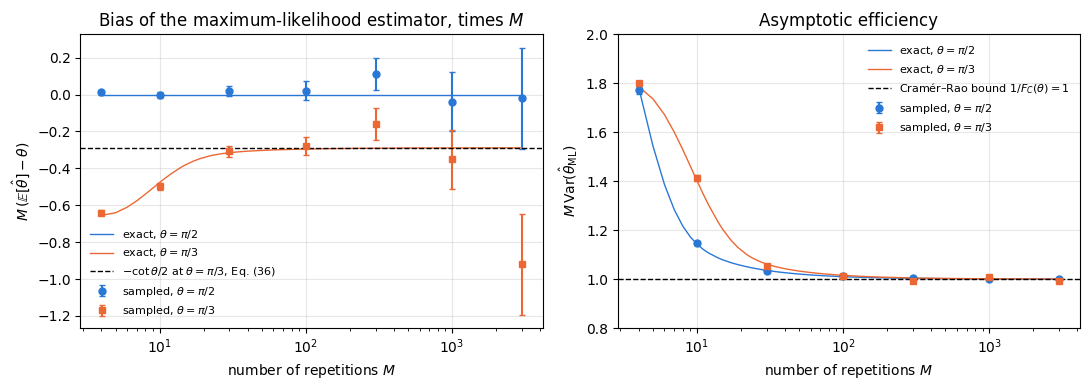

In [7]:
# ==============================================================================
# FIGURE: convergence of the maximum-likelihood estimator to the Cramer-Rao bound
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))
Ms = np.array(M_GRID, dtype=float)
Mfine = np.unique(np.round(np.logspace(np.log10(4), np.log10(3000), 60)).astype(int))
for j, (theta, lab) in enumerate(zip(THETA_LIST, (r"\pi/2", r"\pi/3"))):
    r = np.array(ml_rows[theta])
    exact_fine = np.array([ml_exact_moments(theta, int(M)) for M in Mfine])
    axes[0].errorbar(Ms, Ms * r[:, 1], yerr=Ms * r[:, 2], fmt=MARKERS[j], color=PALETTE[j], ms=5, capsize=2,
                     label=rf"sampled, $\theta={lab}$")
    axes[0].plot(Mfine, Mfine * exact_fine[:, 0], "-", color=PALETTE[j], lw=1, label=rf"exact, $\theta={lab}$")
    axes[1].errorbar(Ms, r[:, 3], yerr=r[:, 4], fmt=MARKERS[j], color=PALETTE[j], ms=5, capsize=2,
                     label=rf"sampled, $\theta={lab}$")
    axes[1].plot(Mfine, Mfine * exact_fine[:, 1], "-", color=PALETTE[j], lw=1, label=rf"exact, $\theta={lab}$")
axes[0].axhline(-0.5 / np.tan(np.pi / 3), color="k", ls="--", lw=1, label=r"$-\cot\theta/2$ at $\theta=\pi/3$, Eq. (36)")
axes[0].set_xscale("log")
axes[0].set_xlabel("number of repetitions $M$"); axes[0].set_ylabel(r"$M\,(\mathbb{E}[\hat\theta]-\theta)$")
axes[0].set_title("Bias of the maximum-likelihood estimator, times $M$"); axes[0].legend(fontsize=8)
axes[1].axhline(1.0, color="k", ls="--", lw=1, label=r"Cramér–Rao bound $1/F_C(\theta)=1$")
axes[1].set_xscale("log")
axes[1].set_xlabel("number of repetitions $M$"); axes[1].set_ylabel(r"$M\,\mathrm{Var}(\hat\theta_{\rm ML})$")
axes[1].set_ylim(0.8, 2.0)
axes[1].set_title("Asymptotic efficiency"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

Every sampled point agrees with the exact finite-$M$ value within four standard errors (asserted), so the Monte-Carlo
data and the binomial sum are two independent views of the same estimator. The left panel plots the bias multiplied by
$M$, so that a $1/M$ law appears as a plateau. At $\theta=\pi/3$ the exact curve settles on the delta-method value
$-\cot\theta/2=-0.289$ of Eq. (36) (within $1\%$ from $M=300$ on, asserted), so the bias falls like $1/M$; the sampled
points follow it with error bars that grow with $M$, because the bias shrinks faster than the Monte-Carlo noise of
$40\,000$ experiments. At $\theta=\pi/2$ the exact bias is zero at every $M$, and the sampled values scatter around zero
within their error bars. The wrong control makes the same point quantitatively: at $\theta=\pi/3$, $M=10$ the sampled
bias excludes "unbiased" by the number of standard errors printed above.

The right panel shows the efficiency. The scaled variance $M\,\mathrm{Var}$ starts well *above* the bound at $M=4$
(exactly $1.78$ at $\theta=\pi/2$ and $1.79$ at $\theta=\pi/3$) — a handful of outcomes is not enough to invert a cosine reliably — and
approaches $1/F_C(\theta)=1$ from above: at $\theta=\pi/2$ the exact excess is $3.6\%$ at $M=30$, $1.0\%$ at $M=100$ and
$0.03\%$ at $M=3000$; at $\theta=\pi/3$ the approach is slower at small $M$ ($40\%$ excess at $M=10$). For a regular
model the Cramér–Rao bound is therefore the *achievable* precision once enough data have been collected.

> **Common pitfall.** "My estimator beat the Cramér–Rao bound" almost always means "my estimator is biased". At $M=4$
> above one can indeed construct estimators with a smaller variance than $1/(MF_C)$ — they shrink towards a fixed guess and
> pay for it with bias. Eq. (23) constrains the variance only for (locally) unbiased estimators; Eq. (7) is what you
> should minimise.

## 5. The quantum meter: symmetric logarithmic derivative and quantum Fisher information

### 5.1 A quantum meter, and a Fisher information for every measurement

Nothing in Sections 3 and 4 was quantum: the theory used only the distribution $p(x\vert\theta)$ of the readings. From
now on the meter is a quantum system. Its state is a density matrix $\rho_\theta$ — a Hermitian, positive semidefinite
matrix of unit trace (introduced in
[07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb));
a pure state $\vert\psi_\theta\rangle$ corresponds to $\rho_\theta=\vert\psi_\theta\rangle\langle\psi_\theta\vert$. The
way $\theta$ enters the state is called the **encoding**. The most important encoding, and the one used throughout this
chapter, is a unitary evolution generated by a Hermitian operator $G$ (the **generator**),

$$\rho_\theta=U(\theta)\,\rho\,U^\dagger(\theta),\qquad U(\theta)=e^{-i\theta G} . \tag{38}$$

A magnetic field $B$ acting for a time $t$ on spins rotates them about the field axis, so $\theta=\gamma Bt$ with
$G=J_z$; an optical path-length difference $\Delta L$ gives $\theta=2\pi\Delta L/\lambda$; a clock compares an atomic
transition frequency with a laser, $\theta=(\omega_{\text{atom}}-\omega_{\text{laser}})t$. The derivative of the encoded
state follows from $\partial_\theta U=-iGU$ and $\partial_\theta U^\dagger=iU^\dagger G$ (the generator commutes with
its own exponential):

$$\partial_\theta\rho_\theta=(-iGU)\rho U^\dagger+U\rho\,(iU^\dagger G)=-i\left(G\rho_\theta-\rho_\theta G\right)
  =-i\left[G,\rho_\theta\right] . \tag{39}$$

A measurement is described by a **POVM** (positive operator-valued measure): one operator $E_x$ for every outcome $x$,
with $E_x$ positive semidefinite and $\sum_xE_x=\mathbb 1$ (see
[08 — measurements](../ch03_matrix_free_engine/08_measurements.ipynb)). A projective measurement in an orthonormal basis
$\{\vert x\rangle\}$ is the special case $E_x=\vert x\rangle\langle x\vert$. The Born rule gives the distribution of the
readings,

$$p(x\vert\theta)=\mathrm{Tr}\!\left(E_x\,\rho_\theta\right) , \tag{40}$$

which is non-negative because $E_x$ and $\rho_\theta$ are positive, and normalised because
$\sum_x\mathrm{Tr}(E_x\rho_\theta)=\mathrm{Tr}(\mathbb 1\,\rho_\theta)=1$. Every result of Sections 3 and 4 now applies to
the quantum meter, with one new feature: the distribution, and with it the Fisher information, depends on which POVM we
choose. Since the trace is linear, $\partial_\theta p(x\vert\theta)=\mathrm{Tr}(E_x\,\partial_\theta\rho_\theta)$, and
Eq. (13) becomes

$$F_C(\theta;\{E_x\})=\sum_x\frac{\left(\mathrm{Tr}(E_x\,\partial_\theta\rho_\theta)\right)^2}{\mathrm{Tr}(E_x\,\rho_\theta)} . \tag{41}$$

A poorly chosen measurement can give $F_C=0$. For a GHZ state with $G=J_z$, measuring every qubit along $z$ produces
outcome statistics that do not depend on $\theta$ at all, so no estimator can extract the phase from that data. A good
measurement makes $F_C$ as large as possible. The rest of this section finds the largest value and shows that it is a
property of the state alone. The key object is an operator analogue of the score.

### 5.2 The symmetric logarithmic derivative

The classical score is the logarithmic derivative of the distribution: by Eq. (11), $\partial_\theta p=p\,s$. The
quantum analogue would be an operator $L$ with "$\partial_\theta\rho=\rho L$". This cannot work as it stands, because
$\partial_\theta\rho$ is Hermitian while $\rho L$ is not Hermitian unless $\rho$ and $L$ commute. The product is
therefore replaced by its symmetrised form. The **symmetric logarithmic derivative** (SLD) $L_\theta$ is the Hermitian
operator that solves

$$\partial_\theta\rho_\theta=\frac12\left(L_\theta\,\rho_\theta+\rho_\theta\,L_\theta\right) . \tag{42}$$

The right-hand side is Hermitian whenever $L_\theta$ is, since $(L\rho+\rho L)^\dagger=\rho L+L\rho$; this is the
"symmetric" in the name. The "logarithmic" refers to the classical limit. If all states $\rho_\theta$ are diagonal in one
fixed basis, $\rho_\theta=\sum_m\lambda_m(\theta)\vert m\rangle\langle m\vert$, then $\rho$ and $\partial_\theta\rho$
commute, and Eq. (42) is solved by

$$L_\theta=\sum_m\frac{\partial_\theta\lambda_m}{\lambda_m}\,\vert m\rangle\langle m\vert
  =\sum_m\left(\partial_\theta\ln\lambda_m\right)\vert m\rangle\langle m\vert , \tag{43}$$

as one checks by inserting it: $\tfrac12(L\rho+\rho L)=\sum_m\partial_\theta\lambda_m\vert m\rangle\langle m\vert=\partial_\theta\rho$.
The eigenvalues of $L$ are then exactly the scores of the probability distribution $\lambda_m(\theta)$.

Like the score, the SLD has zero mean. Take the trace of Eq. (42) and use $\mathrm{Tr}(L\rho)=\mathrm{Tr}(\rho L)$
(cyclic property of the trace):

$$0=\partial_\theta\,\mathrm{Tr}\rho_\theta=\mathrm{Tr}\!\left(\partial_\theta\rho_\theta\right)
  =\tfrac12\mathrm{Tr}(L\rho)+\tfrac12\mathrm{Tr}(\rho L)=\mathrm{Tr}\!\left(\rho_\theta L_\theta\right) . \tag{44}$$

Equation (42) is linear in $L$ and is solved in the eigenbasis of the state. Write $\rho=\sum_m\lambda_m\vert m\rangle\langle m\vert$
and take the matrix element $\langle m\vert\cdot\vert n\rangle$ of Eq. (42). Since $\rho\vert n\rangle=\lambda_n\vert n\rangle$
and $\langle m\vert\rho=\lambda_m\langle m\vert$, every matrix element decouples, and

$$(\partial_\theta\rho)_{mn}=\tfrac12\left(\lambda_m+\lambda_n\right)L_{mn}
  \quad\Longrightarrow\quad
  L_{mn}=\frac{2\,(\partial_\theta\rho)_{mn}}{\lambda_m+\lambda_n}\qquad(\lambda_m+\lambda_n>0) . \tag{45}$$

Elements with $\lambda_m=\lambda_n=0$ are not fixed by Eq. (42); they do not contribute to anything computed below.
Notebook [30 — QFI from the SLD](../ch10_quantum_metrology_protocols/30_qfi_from_the_sld_prepare_encode_estimate.ipynb)
(Section 5) treats this kernel in detail and builds the SLD numerically for mixed states.

### 5.3 The quantum Fisher information and the Braunstein–Caves inequality

By analogy with $F_C=\mathbb{E}[s^2]$, the **quantum Fisher information** is the mean square of the SLD,

$$F_Q[\rho_\theta]=\mathrm{Tr}\!\left(\rho_\theta\,L_\theta^2\right) , \tag{46}$$

which by Eq. (44) is also the variance of $L_\theta$ in the state $\rho_\theta$. A working formula follows from the
eigenbasis. Since $\rho\vert m\rangle=\lambda_m\vert m\rangle$ and $\langle m\vert L^2\vert m\rangle=\sum_n\vert L_{mn}\vert^2$,

$$\mathrm{Tr}(\rho L^2)=\sum_m\lambda_m\langle m\vert L^2\vert m\rangle=\sum_{m,n}\lambda_m\vert L_{mn}\vert^2
  =\sum_{m,n}\frac{\lambda_m+\lambda_n}{2}\vert L_{mn}\vert^2 , \tag{47}$$

where the last step averages the double sum with its copy in which $m$ and $n$ are exchanged ($\vert L_{mn}\vert=\vert L_{nm}\vert$
because $L$ is Hermitian). Inserting Eq. (45),

$$F_Q=2\sum_{m,n\,:\,\lambda_m+\lambda_n>0}\frac{\left\vert(\partial_\theta\rho)_{mn}\right\vert^2}{\lambda_m+\lambda_n} . \tag{48}$$

For the unitary encoding the derivative is the commutator of Eq. (39), whose matrix elements are
$(\partial_\theta\rho)_{mn}=-i\langle m\vert(G\rho-\rho G)\vert n\rangle=-i(\lambda_n-\lambda_m)G_{mn}$ with $G_{mn}=\langle m\vert G\vert n\rangle$. Hence

$$F_Q[\rho,G]=2\sum_{m,n\,:\,\lambda_m+\lambda_n>0}\frac{\left(\lambda_m-\lambda_n\right)^2}{\lambda_m+\lambda_n}
  \left\vert\langle m\vert G\vert n\rangle\right\vert^2 , \tag{49}$$

the formula implemented by the engine's `qfi_mixed`. It depends on the state and the generator, and on no measurement.
The next theorem shows why it deserves its name.

**Theorem (Braunstein and Caves 1994).** For every POVM $\{E_x\}$,

$$F_C(\theta;\{E_x\})\;\le\;F_Q[\rho_\theta] , \tag{50}$$

and the projective measurement onto the eigenvectors of $L_\theta$ reaches equality.

*Proof of the inequality.* Fix an outcome $x$ and abbreviate $\rho=\rho_\theta$, $L=L_\theta$, $p_x=\mathrm{Tr}(E_x\rho)$.

*Step 1: the derivative of $p_x$ as the real part of a trace.* By Eq. (42),

$$\partial_\theta p_x=\mathrm{Tr}(E_x\,\partial_\theta\rho)=\tfrac12\mathrm{Tr}(E_xL\rho)+\tfrac12\mathrm{Tr}(E_x\rho L) . \tag{51}$$

The two traces are complex conjugates of each other: $\overline{\mathrm{Tr}(E_x\rho L)}=\mathrm{Tr}\big((E_x\rho L)^\dagger\big)=\mathrm{Tr}(L\rho E_x)=\mathrm{Tr}(E_xL\rho)$,
using that $E_x$, $\rho$ and $L$ are Hermitian and the cyclic property. The sum of a number and its conjugate is twice
its real part, so

$$\partial_\theta p_x=\mathrm{Re}\,\mathrm{Tr}\!\left(E_x L\rho\right) . \tag{52}$$

*Step 2: write the trace as an inner product of two matrices.* Positive semidefinite matrices have positive semidefinite
square roots $E_x^{1/2}$ and $\rho^{1/2}$. Define $A=E_x^{1/2}\rho^{1/2}$ and $B=E_x^{1/2}L\rho^{1/2}$. Then, by
cyclicity,

$$\mathrm{Tr}(A^\dagger B)=\mathrm{Tr}\!\left(\rho^{1/2}E_x^{1/2}E_x^{1/2}L\rho^{1/2}\right)=\mathrm{Tr}\!\left(E_xL\rho\right) . \tag{53}$$

*Step 3: Cauchy–Schwarz.* The expression $\langle A,B\rangle=\mathrm{Tr}(A^\dagger B)=\sum_{ij}\overline{A_{ij}}B_{ij}$ is the
ordinary inner product of the two matrices regarded as long vectors of their entries, so the Cauchy–Schwarz inequality
$\vert\langle A,B\rangle\vert^2\le\langle A,A\rangle\langle B,B\rangle$ holds for it. Together with $(\mathrm{Re}\,z)^2\le\vert z\vert^2$,

$$\left(\partial_\theta p_x\right)^2\le\left\vert\mathrm{Tr}(A^\dagger B)\right\vert^2
  \le\mathrm{Tr}(A^\dagger A)\,\mathrm{Tr}(B^\dagger B)
  =\mathrm{Tr}\!\left(E_x\rho\right)\,\mathrm{Tr}\!\left(E_xL\rho L\right) , \tag{54}$$

where $\mathrm{Tr}(A^\dagger A)=\mathrm{Tr}(\rho^{1/2}E_x\rho^{1/2})=\mathrm{Tr}(E_x\rho)=p_x$ and
$\mathrm{Tr}(B^\dagger B)=\mathrm{Tr}(\rho^{1/2}LE_xL\rho^{1/2})=\mathrm{Tr}(E_xL\rho L)$, again by cyclicity.

*Step 4: sum over outcomes.* For outcomes with $p_x>0$ divide by $p_x$. (For outcomes with $p_x=0$, Eq. (54) forces
$\partial_\theta p_x=0$; such outcomes are left out of the Fisher information, as in Eq. (13).) Summing and using
$\sum_xE_x=\mathbb 1$:

$$F_C(\theta;\{E_x\})=\sum_x\frac{\left(\partial_\theta p_x\right)^2}{p_x}\le\sum_x\mathrm{Tr}\!\left(E_xL\rho L\right)
  =\mathrm{Tr}\!\left(L\rho L\right)=\mathrm{Tr}\!\left(\rho L^2\right)=F_Q . \tag{55}$$

$\square$

*Proof of attainability.* Let $L=\sum_x\ell_x\vert\ell_x\rangle\langle\ell_x\vert$ be the eigendecomposition of the SLD
and measure the projectors $E_x=\vert\ell_x\rangle\langle\ell_x\vert$. Using Eq. (42) and $L\vert\ell_x\rangle=\ell_x\vert\ell_x\rangle$
on both sides of $\rho$,

$$\partial_\theta p_x=\langle\ell_x\vert\partial_\theta\rho\vert\ell_x\rangle
  =\tfrac12\langle\ell_x\vert\left(L\rho+\rho L\right)\vert\ell_x\rangle=\ell_x\,\langle\ell_x\vert\rho\vert\ell_x\rangle=\ell_x\,p_x , \tag{56}$$

so the score of outcome $x$ is the eigenvalue $\ell_x$, and

$$F_C=\sum_x\frac{\left(\ell_xp_x\right)^2}{p_x}=\sum_x\ell_x^2\,p_x
  =\sum_x\ell_x^2\,\langle\ell_x\vert\rho\vert\ell_x\rangle=\mathrm{Tr}\!\left(\rho L^2\right)=F_Q . \tag{57}$$

$\square$

Combining the two parts, the quantum Fisher information is the largest classical Fisher information that any measurement
on $\rho_\theta$ can produce,

$$F_Q[\rho_\theta]=\max_{\{E_x\}}F_C(\theta;\{E_x\}) . \tag{58}$$

The SLD and the quantum Cramér–Rao bound go back to Helstrom's quantum estimation theory (Helstrom 1976); the
inequality (50) for every POVM, with the proof given above, and its geometric interpretation are due to Braunstein and
Caves (1994). The
optimal measurement is *local* in the parameter: $L_\theta$ depends on $\theta$, so the basis that reaches the bound at
one working point need not reach it at another. An experiment reaches $F_Q$ by using a rough estimate of $\theta$ to
choose the basis and then refining — adaptively, or by working at a fixed operating point as the interferometers of
notebooks 31 and 32 do.

### 5.4 Additivity and the quantum Cramér–Rao bound

The quantum Fisher information adds up over independent subsystems, exactly as Eq. (18) does for repetitions.
Let $\rho=\rho_1\otimes\rho_2$, where each factor carries its own copy of the parameter (two repetitions of the
experiment, or two qubits with $G=G_1\otimes\mathbb 1+\mathbb 1\otimes G_2$). The product rule gives
$\partial_\theta\rho=\partial_\theta\rho_1\otimes\rho_2+\rho_1\otimes\partial_\theta\rho_2$. Try $L=L_1\otimes\mathbb 1+\mathbb 1\otimes L_2$,
with $L_1$ and $L_2$ the SLDs of the factors:

$$\tfrac12\left(L\rho+\rho L\right)=\tfrac12\left(L_1\rho_1+\rho_1L_1\right)\otimes\rho_2+\rho_1\otimes\tfrac12\left(L_2\rho_2+\rho_2L_2\right)
  =\partial_\theta\rho_1\otimes\rho_2+\rho_1\otimes\partial_\theta\rho_2=\partial_\theta\rho . \tag{59}$$

So $L$ is the SLD of the product, and since $\mathrm{Tr}(\rho_jL_j)=0$ by Eq. (44), the cross terms of $L^2$ drop out:

$$F_Q[\rho_1\otimes\rho_2]=\mathrm{Tr}(\rho_1L_1^2)+\mathrm{Tr}(\rho_2L_2^2)+2\,\mathrm{Tr}(\rho_1L_1)\,\mathrm{Tr}(\rho_2L_2)
  =F_Q[\rho_1]+F_Q[\rho_2] . \tag{60}$$

For $M$ independent copies, $F_Q[\rho_\theta^{\otimes M}]=M\,F_Q[\rho_\theta]$. Chaining Eq. (23) for the chosen
measurement with Eq. (50) gives the **quantum Cramér–Rao bound**,

$$\mathrm{Var}(\hat\theta)\;\ge\;\frac{1}{M\,F_C(\theta;\{E_x\})}\;\ge\;\frac{1}{M\,F_Q[\rho_\theta]},
  \qquad \Delta\theta\ge\frac{1}{\sqrt{M\,F_Q}} . \tag{61}$$

It inherits the conditions of Eq. (23): $\hat\theta$ is (locally) unbiased as a function of all $M$ outcomes, and the
model is regular at $\theta$. Measuring the $M$ copies *jointly* with an entangled POVM does not beat it either, because
by Eq. (60) the $M$-copy state has quantum Fisher information $MF_Q$, and Eq. (50) applied to that state gives the
same right-hand side. Equality in Eq. (61) is reached asymptotically, for large $M$, by measuring each copy in the
optimal basis and processing the outcomes with the maximum-likelihood estimator of Section 4.8.

The code below tests Sections 5.2 and 5.3 on a random full-rank state of two qubits ($d=4$) with a random Hermitian
generator. It builds the SLD from Eq. (45), checks Eqs. (42), (44), (46) and (49), computes the
classical Fisher information of $600$ random POVMs with Eq. (41), and measures in the eigenbasis of $L$. A random
POVM with $n$ outcomes is generated from $n$ random complex matrices $A_x$ as
$E_x=S^{-1/2}A_x^\dagger A_xS^{-1/2}$ with $S=\sum_xA_x^\dagger A_x$, which is positive and sums to $\mathbb 1$ by
construction. The wrong control is the unsymmetrised logarithmic derivative $\Lambda=\rho^{-1}\partial_\theta\rho$, the
naive analogue of $\partial_\theta p/p$; it is neither Hermitian nor a solution of Eq. (42). A second control measures in
the eigenbasis of $\rho_\theta$ itself, which by Eq. (39) has $\partial_\theta p_m=-i(\lambda_m-\lambda_m)G_{mm}=0$ and
therefore learns nothing about $\theta$.

In [8]:
# ==============================================================================
# STEP 4: the Braunstein-Caves inequality, Eq. (50), tested on random measurements
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
D_BC        = 4                      # Hilbert-space dimension (two qubits)
THETA_BC    = 0.4                    # working point
N_POVM_EACH = 200                    # random POVMs per number of outcomes
OUTCOMES    = (2, 4, 8)              # numbers of outcomes of the random POVMs
# -----------------------------------------------------------------------------


def random_density_matrix(key, d):
    """Random full-rank mixed state rho = A A^dag / Tr(A A^dag), A with i.i.d. complex Gaussian entries."""
    k1, k2 = jax.random.split(key)
    A = jax.random.normal(k1, (d, d)) + 1j * jax.random.normal(k2, (d, d))
    rho = A @ A.conj().T
    return (rho / jnp.trace(rho)).astype(CDTYPE)


def random_hermitian(key, d):
    """Random Hermitian d x d matrix (A + A^dag)/2 with i.i.d. complex Gaussian A -- a random generator G."""
    k1, k2 = jax.random.split(key)
    A = jax.random.normal(k1, (d, d)) + 1j * jax.random.normal(k2, (d, d))
    return ((A + A.conj().T) / 2).astype(CDTYPE)


def encode_unitary(rho, G, theta):
    """Eq. (38): rho_theta = U rho U^dag with U = exp(-i theta G), built from the eigendecomposition of G.

    JAX   eigh(G) does not depend on theta, so jax.jacfwd with respect to theta only differentiates the phases.
    """
    g, V = jnp.linalg.eigh(G)
    U = (V * jnp.exp(-1j * theta * g)) @ V.conj().T
    return U @ rho @ U.conj().T


def random_povm(key, d, n_out):
    """Random POVM with n_out outcomes:  E_x = S^{-1/2} A_x^dag A_x S^{-1/2},  S = sum_x A_x^dag A_x.

    MATH   each E_x is positive semidefinite and sum_x E_x = S^{-1/2} S S^{-1/2} = 1.
    """
    k1, k2 = jax.random.split(key)
    A = jax.random.normal(k1, (n_out, d, d)) + 1j * jax.random.normal(k2, (n_out, d, d))
    B = jnp.einsum("xba,xbc->xac", A.conj(), A)                 # A_x^dag A_x
    s, W = jnp.linalg.eigh(B.sum(axis=0))
    S_mhalf = (W * s ** -0.5) @ W.conj().T
    return jnp.einsum("ab,xbc,cd->xad", S_mhalf, B, S_mhalf).astype(CDTYPE)


def povm_fisher(E, rho, G, theta):
    """Classical Fisher information, Eq. (41), of the POVM E (shape (n_out, d, d)) on the encoded state.

    MATH   p_x(theta) = Re Tr(E_x rho_theta);   F_C = sum_x (dp_x/dtheta)^2 / p_x   (forward-mode AD for dp/dtheta)
    """
    probs = lambda t: jnp.real(jnp.einsum("xab,ba->x", E, encode_unitary(rho, G, t)))
    return fisher_information_ad(probs, theta)


def sld_full_rank(rho, drho):
    """SLD of a FULL-RANK state from Eq. (45):  L_mn = 2 (drho)_mn / (lam_m + lam_n)  in the eigenbasis of rho.

    (Rank-deficient states need the kernel treatment of notebook 30; here every lam_m > 0.)
    """
    lam, V = jnp.linalg.eigh(rho)
    D = V.conj().T @ drho @ V
    return V @ (2 * D / (lam[:, None] + lam[None, :])) @ V.conj().T


rho0 = random_density_matrix(jax.random.PRNGKey(21), D_BC)
G_bc = random_hermitian(jax.random.PRNGKey(22), D_BC)
rho_t = encode_unitary(rho0, G_bc, THETA_BC)
drho_t = jax.jacfwd(lambda t: encode_unitary(rho0, G_bc, t))(THETA_BC)        # derivative by automatic differentiation
L_bc = sld_full_rank(rho_t, drho_t)
F_Q_bc = float(jnp.real(jnp.trace(rho_t @ L_bc @ L_bc)))                     # Eq. (46)
checks = {"commutator, Eq. (39)": max_abs(drho_t + 1j * (G_bc @ rho_t - rho_t @ G_bc)),
          "SLD equation, Eq. (42)": max_abs(drho_t - 0.5 * (L_bc @ rho_t + rho_t @ L_bc)),
          "L Hermitian": max_abs(L_bc - L_bc.conj().T),
          "Tr(rho L) = 0, Eq. (44)": abs(complex(jnp.trace(rho_t @ L_bc))),
          "Tr(rho L^2) - Eq. (49) [qfi_mixed]": abs(F_Q_bc - float(qfi_mixed(rho_t, G_bc)))}
for name, err in checks.items():
    print(f"{name:>40s}: {err:.2e}")
    assert err < 1e4 * TOL

# random POVMs: vmap over keys for each number of outcomes (n_out is static: it fixes the array shapes)
print(f"\nF_Q = Tr(rho L^2) = {F_Q_bc:.6f}")
ratios = []
for j, n_out in enumerate(OUTCOMES):
    keys = jax.random.split(jax.random.PRNGKey(100 + j), N_POVM_EACH)
    Es = jax.vmap(lambda k: random_povm(k, D_BC, n_out))(keys)
    Fc = jax.vmap(lambda E: povm_fisher(E, rho0, G_bc, THETA_BC))(Es)
    r = np.asarray(Fc) / F_Q_bc
    ratios.append(r)
    print(f"{N_POVM_EACH} random POVMs with {n_out} outcomes: F_C/F_Q  min {r.min():.4f}  mean {r.mean():.4f}  max {r.max():.4f}")
assert max(r.max() for r in ratios) <= 1 + 1e4 * TOL                        # Eq. (50) for every POVM

# the eigenbasis of L reaches the bound, and the eigenvalues of L are the scores of its outcomes, Eq. (56)
ell, W = jnp.linalg.eigh(L_bc)
E_opt = jnp.einsum("ax,bx->xab", W, W.conj())
F_opt = float(povm_fisher(E_opt, rho0, G_bc, THETA_BC))
probs_opt = lambda t: jnp.real(jnp.einsum("xab,ba->x", E_opt, encode_unitary(rho0, G_bc, t)))
score_opt = jax.jacfwd(probs_opt)(THETA_BC) / probs_opt(THETA_BC)
print(f"eigenbasis of L: F_C = {F_opt:.6f}  (F_Q = {F_Q_bc:.6f});  max |score_x - ell_x| = {max_abs(score_opt - ell):.2e}")
assert abs(F_opt - F_Q_bc) < 1e4 * TOL and max_abs(score_opt - ell) < 1e4 * TOL

# CONTROL: the eigenbasis of rho_theta itself gives F_C = 0 for a unitary encoding
_, Vr = jnp.linalg.eigh(rho_t)
F_rho = float(povm_fisher(jnp.einsum("ax,bx->xab", Vr, Vr.conj()), rho0, G_bc, THETA_BC))
print(f"eigenbasis of rho_theta: F_C = {F_rho:.2e}")
assert F_rho < 1e4 * TOL

# WRONG CONTROL: the unsymmetrised logarithmic derivative rho^{-1} drho is not Hermitian and does not solve Eq. (42)
Lam = jnp.linalg.solve(rho_t, drho_t)
res_wrong, herm_wrong = max_abs(drho_t - 0.5 * (Lam @ rho_t + rho_t @ Lam)), max_abs(Lam - Lam.conj().T)
print(f"wrong control rho^-1 drho: SLD residual {res_wrong:.3f}, non-Hermiticity {herm_wrong:.3f}")
assert res_wrong > 1e-2 and herm_wrong > 1e-2

                    commutator, Eq. (39): 2.29e-16
                  SLD equation, Eq. (42): 3.34e-16
                             L Hermitian: 1.61e-15
                 Tr(rho L) = 0, Eq. (44): 4.20e-16
      Tr(rho L^2) - Eq. (49) [qfi_mixed]: 2.66e-15

F_Q = Tr(rho L^2) = 3.858571


200 random POVMs with 2 outcomes: F_C/F_Q  min 0.0000  mean 0.0360  max 0.3735


200 random POVMs with 4 outcomes: F_C/F_Q  min 0.0004  mean 0.0439  max 0.1779


200 random POVMs with 8 outcomes: F_C/F_Q  min 0.0113  mean 0.0529  max 0.1513


eigenbasis of L: F_C = 3.858571  (F_Q = 3.858571);  max |score_x - ell_x| = 2.22e-15
eigenbasis of rho_theta: F_C = 3.30e-31
wrong control rho^-1 drho: SLD residual 6.544, non-Hermiticity 32.215


The SLD built from Eq. (45) solves Eq. (42) to round-off, is Hermitian, has zero mean, and its mean square agrees
with the engine's implementation of Eq. (49). None of the $600$ random POVMs exceeds $F_Q$; their average sits well
below it, and adding outcomes raises the typical value without ever crossing the bound. The projective measurement in the
eigenbasis of $L$ reaches $F_Q$ exactly, and the score of each of its outcomes is the corresponding eigenvalue of $L$,
as Eq. (56) states. The eigenbasis of the state itself gives $F_C=0$. The naive operator $\rho^{-1}\partial_\theta\rho$
fails both tests by an amount of order one, which is why the symmetrised definition is needed.

## 6. Pure states: the quantum Fisher information reduces analytically to $4\,\mathrm{Var}(G)$

For a pure state the SLD equation can be solved by hand, and the quantum Fisher information becomes an expectation value
that requires no diagonalisation. We derive this in three steps — the SLD of a pure state, $F_Q$ in terms of the state
vector, and the unitary encoding — and then interpret the result geometrically.

### 6.1 The SLD of a pure state

A pure state is a projector, $\rho_\theta=\vert\psi_\theta\rangle\langle\psi_\theta\vert$ with $\langle\psi_\theta\vert\psi_\theta\rangle=1$, so

$$\rho_\theta^2=\vert\psi_\theta\rangle\langle\psi_\theta\vert\psi_\theta\rangle\langle\psi_\theta\vert=\rho_\theta . \tag{62}$$

Differentiate both sides with the product rule, keeping the order of the factors because matrices do not commute:

$$\partial_\theta\left(\rho^2\right)=(\partial_\theta\rho)\,\rho+\rho\,(\partial_\theta\rho)=\partial_\theta\rho . \tag{63}$$

Compare with the SLD equation (42). Multiplying Eq. (63) by one and writing $1=\tfrac12\cdot2$,

$$\partial_\theta\rho=\tfrac12\left[(2\,\partial_\theta\rho)\,\rho+\rho\,(2\,\partial_\theta\rho)\right] , \tag{64}$$

which is Eq. (42) with

$$L_\theta=2\,\partial_\theta\rho_\theta . \tag{65}$$

This $L$ is Hermitian, as required. (Other solutions differ from it only inside the kernel of $\rho$, where Eq. (45)
leaves the SLD undetermined, and give the same $F_Q$.)

### 6.2 The quantum Fisher information in terms of the state vector

Write $\vert\psi\rangle=\vert\psi_\theta\rangle$ and $\vert\dot\psi\rangle=\partial_\theta\vert\psi_\theta\rangle$ for the state
and its velocity. The product rule gives

$$\partial_\theta\rho=\vert\dot\psi\rangle\langle\psi\vert+\vert\psi\rangle\langle\dot\psi\vert . \tag{66}$$

Normalisation constrains the velocity. Differentiating $\langle\psi\vert\psi\rangle=1$ gives

$$\langle\dot\psi\vert\psi\rangle+\langle\psi\vert\dot\psi\rangle=0
  \quad\Longrightarrow\quad \mathrm{Re}\,\langle\psi\vert\dot\psi\rangle=0 , \tag{67}$$

so $\langle\psi\vert\dot\psi\rangle=i\beta$ is purely imaginary, with real $\beta$. Now evaluate Eq. (46) with
Eq. (65). For any operator $X$, $\mathrm{Tr}(\vert\psi\rangle\langle\psi\vert X)=\langle\psi\vert X\vert\psi\rangle$, and
$\partial_\theta\rho$ is Hermitian, so

$$F_Q=\mathrm{Tr}\!\left(\rho\,(2\partial_\theta\rho)^2\right)=4\,\langle\psi\vert(\partial_\theta\rho)(\partial_\theta\rho)\vert\psi\rangle
  =4\,\big\Vert\,\partial_\theta\rho\,\vert\psi\rangle\big\Vert^2 . \tag{68}$$

Apply Eq. (66) to $\vert\psi\rangle$, using $\langle\psi\vert\psi\rangle=1$ and $\langle\dot\psi\vert\psi\rangle=\overline{i\beta}=-i\beta$:

$$\partial_\theta\rho\,\vert\psi\rangle=\vert\dot\psi\rangle\langle\psi\vert\psi\rangle+\vert\psi\rangle\langle\dot\psi\vert\psi\rangle
  =\vert\dot\psi\rangle-i\beta\,\vert\psi\rangle . \tag{69}$$

Its squared norm, expanded term by term with $\langle\psi\vert\dot\psi\rangle=i\beta$, is

$$\begin{aligned}
\big\Vert\vert\dot\psi\rangle-i\beta\vert\psi\rangle\big\Vert^2
 &=\langle\dot\psi\vert\dot\psi\rangle-i\beta\,\langle\dot\psi\vert\psi\rangle+i\beta\,\langle\psi\vert\dot\psi\rangle+\beta^2\langle\psi\vert\psi\rangle\\
 &=\langle\dot\psi\vert\dot\psi\rangle-i\beta(-i\beta)+i\beta(i\beta)+\beta^2\\
 &=\langle\dot\psi\vert\dot\psi\rangle-\beta^2-\beta^2+\beta^2=\langle\dot\psi\vert\dot\psi\rangle-\beta^2 .
\end{aligned} \tag{70}$$

Since $\beta^2=\vert\langle\psi\vert\dot\psi\rangle\vert^2$, Eqs. (68) and (70) give

$$F_Q=4\left(\langle\dot\psi\vert\dot\psi\rangle-\left\vert\langle\psi\vert\dot\psi\rangle\right\vert^2\right) . \tag{71}$$

The bracket is the squared length of the part of the velocity orthogonal to the state,
$\vert\dot\psi_\perp\rangle=\vert\dot\psi\rangle-\vert\psi\rangle\langle\psi\vert\dot\psi\rangle$. The component along
$\vert\psi\rangle$ only changes the global phase, which no measurement can detect, and Eq. (71) removes it.

### 6.3 Unitary encoding: $F_Q=4\,\mathrm{Var}(G)$

For $\vert\psi_\theta\rangle=e^{-i\theta G}\vert\psi\rangle$ the velocity is

$$\vert\dot\psi_\theta\rangle=-iG\,e^{-i\theta G}\vert\psi\rangle=-iG\,\vert\psi_\theta\rangle . \tag{72}$$

The two terms of Eq. (71) become expectation values of the generator in the encoded state, written
$\langle\cdot\rangle_\theta$:

$$\langle\dot\psi_\theta\vert\dot\psi_\theta\rangle=\langle\psi_\theta\vert(iG)(-iG)\vert\psi_\theta\rangle=\langle G^2\rangle_\theta,\qquad
  \langle\psi_\theta\vert\dot\psi_\theta\rangle=-i\langle G\rangle_\theta,\quad
  \left\vert\langle\psi_\theta\vert\dot\psi_\theta\rangle\right\vert^2=\langle G\rangle_\theta^2 . \tag{73}$$

Moreover, since $G$ commutes with $e^{\pm i\theta G}$, the moments do not depend on $\theta$:

$$\langle G^k\rangle_\theta=\langle\psi\vert e^{i\theta G}G^ke^{-i\theta G}\vert\psi\rangle=\langle\psi\vert G^k\vert\psi\rangle . \tag{74}$$

Inserting Eqs. (73) and (74) into Eq. (71), the quantum Fisher information reduces analytically to
the variance of the generator in the initial state,

$$\boxed{\;F_Q\;=\;4\left(\langle\psi\vert G^2\vert\psi\rangle-\langle\psi\vert G\vert\psi\rangle^2\right)\;=\;4\,\mathrm{Var}_\psi(G)\;} \tag{75}$$

independent of $\theta$. A large spread of the generator in the probe state makes the state move fast under the encoding.

### 6.4 Geometric meaning: how fast the state moves

The title of this notebook describes $F_Q$ as the speed at which a state changes. To make this precise, compare
$\vert\psi_\theta\rangle$ with its neighbour $\vert\psi_{\theta+\delta}\rangle$ through the **fidelity**
$\vert\langle\psi_\theta\vert\psi_{\theta+\delta}\rangle\vert^2$, the probability that the second state passes a test for
being the first. It equals $1$ for identical states (up to a phase) and $0$ for orthogonal ones. We expand it to second
order in $\delta$ for an arbitrary smooth curve of normalised states, not necessarily a unitary encoding.

Differentiating Eq. (67) once more gives a relation for the second derivative $\vert\ddot\psi\rangle$:

$$\langle\ddot\psi\vert\psi\rangle+2\langle\dot\psi\vert\dot\psi\rangle+\langle\psi\vert\ddot\psi\rangle=0
  \quad\Longrightarrow\quad \mathrm{Re}\,\langle\psi\vert\ddot\psi\rangle=-\langle\dot\psi\vert\dot\psi\rangle . \tag{76}$$

The Taylor expansion of the overlap $a(\delta)=\langle\psi_\theta\vert\psi_{\theta+\delta}\rangle$, with
$\langle\psi\vert\dot\psi\rangle=i\beta$ from Eq. (67) and $\langle\psi\vert\ddot\psi\rangle=-\langle\dot\psi\vert\dot\psi\rangle+i\gamma$
from Eq. (76) ($\gamma$ real), is

$$a(\delta)=1+\delta\langle\psi\vert\dot\psi\rangle+\frac{\delta^2}{2}\langle\psi\vert\ddot\psi\rangle+O(\delta^3)
  =\underbrace{1-\frac{\delta^2}{2}\langle\dot\psi\vert\dot\psi\rangle}_{\mathrm{Re}\,a}
  +i\underbrace{\left(\beta\delta+\frac{\gamma\delta^2}{2}\right)}_{\mathrm{Im}\,a}+O(\delta^3) . \tag{77}$$

Square the real and imaginary parts and keep terms up to $\delta^2$:

$$\begin{aligned}
\vert a(\delta)\vert^2&=\left(1-\frac{\delta^2}{2}\langle\dot\psi\vert\dot\psi\rangle\right)^2+\left(\beta\delta+\frac{\gamma\delta^2}{2}\right)^2+O(\delta^3)\\
&=1-\delta^2\langle\dot\psi\vert\dot\psi\rangle+\beta^2\delta^2+O(\delta^3)
 =1-\delta^2\left(\langle\dot\psi\vert\dot\psi\rangle-\vert\langle\psi\vert\dot\psi\rangle\vert^2\right)+O(\delta^3) .
\end{aligned} \tag{78}$$

The bracket is $F_Q/4$ by Eq. (71). Therefore

$$\left\vert\langle\psi_\theta\vert\psi_{\theta+\delta}\rangle\right\vert^2=1-\frac{F_Q}{4}\,\delta^2+O(\delta^3) . \tag{79}$$

The quantum Fisher information is the curvature with which the fidelity drops away from $1$. Measured as an angle
between rays, $s=\arccos\vert\langle\psi_\theta\vert\psi_{\theta+\delta}\rangle\vert$ (the Fubini–Study distance), the
expansion $\cos s=1-s^2/2+O(s^4)$ compared with $\sqrt{1-F_Q\delta^2/4}=1-F_Q\delta^2/8+O(\delta^3)$ gives

$$s=\frac{\sqrt{F_Q}}{2}\,\delta+O(\delta^2),\qquad\text{i.e.}\qquad \frac{ds}{d\theta}=\frac{\sqrt{F_Q}}{2} . \tag{80}$$

So $\sqrt{F_Q}/2$ is the speed at which the state moves through the space of quantum states when $\theta$ changes. A
fast-moving state becomes distinguishable from its neighbours after a small change of $\theta$, which is why it allows a
precise estimate. This geometric reading, with the statistical distance between neighbouring states, is the subject of
Braunstein and Caves (1994). For mixed states the fidelity is replaced by the Bures (Uhlmann) fidelity $F_B$, and the
relation becomes $F_Q=\lim_{\delta\to0}8\left(1-\sqrt{F_B(\rho_\theta,\rho_{\theta+\delta})}\right)/\delta^2$, which reduces
to Eq. (79) for pure states and is verified numerically in notebook 30 (Section 7.1).

The fidelity gives a second, independent route to Eq. (75) for the unitary encoding. Expand the exponential directly:

$$\langle\psi\vert e^{-i\delta G}\vert\psi\rangle=1-i\delta\langle G\rangle-\frac{\delta^2}{2}\langle G^2\rangle+O(\delta^3) . \tag{81}$$

Its squared modulus is the real part squared plus the imaginary part squared,

$$\left\vert\langle\psi\vert e^{-i\delta G}\vert\psi\rangle\right\vert^2
  =\left(1-\frac{\delta^2}{2}\langle G^2\rangle\right)^2+\delta^2\langle G\rangle^2+O(\delta^3)
  =1-\delta^2\left(\langle G^2\rangle-\langle G\rangle^2\right)+O(\delta^3) , \tag{82}$$

and comparison with Eq. (79) gives $F_Q/4=\mathrm{Var}(G)$ again, without using the SLD.

### 6.5 Two corollaries

**$F_Q$ does not depend on $\theta$** (Eq. (74)). We may evaluate everything at $\theta=0$ and never encode at
all when we only want $F_Q$, which is a large practical saving.

**A global phase is invisible.** Replacing $G\to G+c\,\mathbb 1$ multiplies $U$ by the phase $e^{-ic\theta}$ and leaves
$\mathrm{Var}(G)$ unchanged. Only the *spread* of the generator matters, never its mean.

### 6.6 A worked check on one qubit

One qubit, $\vert\psi\rangle=\vert+\rangle=(\vert0\rangle+\vert1\rangle)/\sqrt2$, generator $G=J_z=Z/2$. Then
$\langle J_z\rangle=0$ and $J_z^2=\mathbb 1/4$, so $\mathrm{Var}(J_z)=1/4$ and Eq. (75) gives $F_Q=1$.
A measurement along $x$ reaches this value. Encode and measure:

$$\vert\psi_\theta\rangle=\frac{e^{-i\theta/2}\vert0\rangle+e^{+i\theta/2}\vert1\rangle}{\sqrt2},\qquad
  p(\pm\vert\theta)=\left\vert\langle\pm\vert\psi_\theta\rangle\right\vert^2=\frac{1\pm\cos\theta}{2} , \tag{83}$$

which is precisely the model of Eq. (32), whose Fisher information we computed to be $F_C=1$ for every $\theta$
except the two irregular points $\theta=0,\pi$. So the single-qubit interferometer saturates the quantum Cramér–Rao bound
at every regular working point. That is the Ramsey protocol, and it is the subject of
[31 — Ramsey interferometry](../ch10_quantum_metrology_protocols/31_ramsey_interferometry.ipynb).

### 6.7 Numerical check of the pure-state derivation

The code below verifies every step of Sections 6.1–6.4 on a random pure state of three qubits ($d=8$) and a random
Hermitian generator, with the velocity $\vert\dot\psi\rangle$ obtained by automatic differentiation of the encoded state:
Eqs. (62), (63), (66), (65), (67), (72), the five expressions for $F_Q$
(Eqs. (46), (71), (75) at two values of $\theta$, and the engine's Eq. (49)), the attainability of Eq. (50) in
the eigenbasis of $L=2\partial_\theta\rho$, and the fidelity expansion (79). Because Eqs. (71) and (79)
hold for any curve of states, they are also tested on a non-unitary curve,
$\vert\phi_\theta\rangle=e^{1.3i\theta}(\vert\phi_0\rangle+\theta\vert\chi\rangle+\theta^2\vert\xi\rangle)/\Vert\cdot\Vert$
with random vectors, whose phase drift makes $\langle\phi\vert\dot\phi\rangle\neq0$. Three wrong controls must fail:
$L=\partial_\theta\rho$ (factor $2$ missing) does not solve the SLD equation, $4\langle\dot\psi\vert\dot\psi\rangle$ (the
overlap term of Eq. (71) dropped) is not $F_Q$, and a fidelity curvature of $F_Q/2$ instead of $F_Q/4$ is rejected.

In [9]:
# ==============================================================================
# STEP 5: the pure-state derivation, Eqs. (62)-(79), checked line by line
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
N_PS, THETA_PS = 3, 0.4             # three qubits (d = 8), working point
DELTAS = (1e-1, 1e-2, 1e-3, 1e-4)   # step sizes for the fidelity expansion
# -----------------------------------------------------------------------------
d_ps = 2 ** N_PS
psi_init = haar_state(jax.random.PRNGKey(31), N_PS).reshape(-1)
G_ps = random_hermitian(jax.random.PRNGKey(32), d_ps)
g_ps, V_ps = jnp.linalg.eigh(G_ps)


def psi_unitary(t):
    """|psi_t> = exp(-i t G)|psi_init>, through the eigendecomposition of G."""
    return V_ps @ (jnp.exp(-1j * t * g_ps) * (V_ps.conj().T @ psi_init))


k1, k2, k3 = jax.random.split(jax.random.PRNGKey(33), 3)
chi = (jax.random.normal(k1, (d_ps,)) + 1j * jax.random.normal(k2, (d_ps,))).astype(CDTYPE)
xi = (jax.random.normal(k3, (d_ps,)) + 1j * jax.random.normal(k1, (d_ps,))).astype(CDTYPE)


def phi_curve(t):
    """A NON-unitary smooth curve of normalised states with a phase drift: e^{1.3 i t} (psi + t chi + t^2 xi)/norm."""
    v = psi_init + t * chi + t ** 2 * xi
    return jnp.exp(1.3j * t) * v / jnp.linalg.norm(v)


def pure_state_checks(curve, t0):
    """All quantities of Sections 6.1-6.4 for a curve of pure states at t0. Returns a dict of numbers."""
    psi, dpsi = curve(t0), jax.jacfwd(curve)(t0)
    rho = jnp.outer(psi, psi.conj())
    drho = jnp.outer(dpsi, psi.conj()) + jnp.outer(psi, dpsi.conj())                 # Eq. (66)
    drho_ad = jax.jacfwd(lambda t: jnp.outer(curve(t), curve(t).conj()))(t0)      # independent: AD of rho itself
    L = 2 * drho                                                                   # Eq. (65)
    ov = jnp.vdot(psi, dpsi)
    out = {"rho^2 = rho, Eq. (62)": max_abs(rho @ rho - rho),
           "product rule, Eq. (66)": max_abs(drho - drho_ad),
           "rho drho + drho rho = drho, Eq. (63)": max_abs(rho @ drho + drho @ rho - drho),
           "SLD equation with L = 2 drho": max_abs(drho - 0.5 * (L @ rho + rho @ L)),
           "Re <psi|dpsi> = 0, Eq. (67)": abs(float(jnp.real(ov)))}
    F_trace = float(jnp.real(jnp.trace(rho @ L @ L)))                              # Eq. (46)
    F_vec = float(4 * (jnp.real(jnp.vdot(dpsi, dpsi)) - jnp.abs(ov) ** 2))           # Eq. (71)
    wrong_L = max_abs(drho - 0.5 * (drho @ rho + rho @ drho))                      # WRONG CONTROL: L = drho
    wrong_F = float(4 * jnp.real(jnp.vdot(dpsi, dpsi)))                             # WRONG CONTROL: overlap term dropped
    fid = []
    for dl in DELTAS:
        a = jnp.vdot(psi, curve(t0 + dl))
        fid.append((dl, float((1 - jnp.abs(a) ** 2) / dl ** 2) / (F_trace / 4),
                    float(jnp.arccos(jnp.clip(jnp.abs(a), 0, 1)) / dl) / (np.sqrt(F_trace) / 2)))
    return out, F_trace, F_vec, wrong_L, wrong_F, fid, rho, psi, dpsi


print("unitary curve exp(-i theta G)|psi>, random G, three qubits")
out, F_tr, F_vec, wrong_L, wrong_F, fid_u, rho_ps, psi_ps, dpsi_ps = pure_state_checks(psi_unitary, THETA_PS)
var4 = lambda v: float(4 * (jnp.real(jnp.vdot(v, G_ps @ (G_ps @ v))) - jnp.real(jnp.vdot(v, G_ps @ v)) ** 2))
out["velocity -iG|psi>, Eq. (72)"] = max_abs(dpsi_ps + 1j * (G_ps @ psi_ps))
for name, err in out.items():
    print(f"  {name:>46s}: {err:.2e}")
    assert err < 1e4 * TOL
F_list = {"Tr(rho L^2), Eq. (46)": F_tr, "4(<dpsi|dpsi> - |<psi|dpsi>|^2), Eq. (71)": F_vec,
          "4 Var(G) at theta, Eq. (75)": var4(psi_ps), "4 Var(G) at theta = 0, Eq. (74)": var4(psi_init),
          "qfi_mixed, Eq. (49)": float(qfi_mixed(rho_ps, G_ps))}
for name, val in F_list.items():
    print(f"  {name:>46s}: {val:.12f}")
    assert abs(val - F_tr) < 1e4 * TOL
# attainability: projective measurement in the eigenbasis of L = 2 drho
_, W_ps = jnp.linalg.eigh(2 * (jnp.outer(dpsi_ps, psi_ps.conj()) + jnp.outer(psi_ps, dpsi_ps.conj())))
F_opt_ps = float(povm_fisher(jnp.einsum("ax,bx->xab", W_ps, W_ps.conj()),
                             jnp.outer(psi_init, psi_init.conj()), G_ps, THETA_PS))
print(f"  {'F_C in the eigenbasis of L = 2 drho':>46s}: {F_opt_ps:.12f}")
assert abs(F_opt_ps - F_tr) < 1e4 * TOL
print(f"  WRONG CONTROL L = drho: SLD residual {wrong_L:.3f};   WRONG CONTROL 4<dpsi|dpsi> = {wrong_F:.4f} vs F_Q = {F_tr:.4f}")
assert wrong_L > 1e-2 and abs(wrong_F - F_tr) > 1e-2

print("\nnon-unitary curve with a phase drift")
out_c, F_tr_c, F_vec_c, wrong_L_c, wrong_F_c, fid_c, *_ = pure_state_checks(phi_curve, THETA_PS)
for name, err in out_c.items():
    assert err < 1e4 * TOL
print(f"  Tr(rho L^2) = {F_tr_c:.10f},  Eq. (71): {F_vec_c:.10f},  wrong control 4<dphi|dphi> = {wrong_F_c:.4f}")
assert abs(F_tr_c - F_vec_c) < 1e4 * TOL and abs(wrong_F_c - F_tr_c) > 1e-2

print(f"\nfidelity expansion, Eq. (79): ratio (1-|<psi|psi+delta>|^2)/delta^2 / (F_Q/4), and speed ratio, Eq. (80)")
print(f"  {'delta':>8s} | {'unitary: fid.':>14s} {'speed':>9s} | {'non-unitary: fid.':>18s} {'speed':>9s}")
for (dl, ru, su), (_, rc, sc) in zip(fid_u, fid_c):
    print(f"  {dl:8.0e} | {ru:14.8f} {su:9.6f} | {rc:18.8f} {sc:9.6f}")
assert abs(fid_u[-1][1] - 1) < 1e-6 and abs(fid_c[-1][1] - 1) < 1e-3 and abs(fid_c[-1][2] - 1) < 1e-3
# WRONG CONTROL: a curvature F_Q/2 would make the ratio 1/2
assert abs(fid_u[-1][1] - 0.5) > 0.4 and abs(fid_c[-1][1] - 0.5) > 0.4

unitary curve exp(-i theta G)|psi>, random G, three qubits


                           rho^2 = rho, Eq. (62): 3.33e-16
                          product rule, Eq. (66): 0.00e+00
            rho drho + drho rho = drho, Eq. (63): 1.00e-15
                    SLD equation with L = 2 drho: 1.00e-15
                     Re <psi|dpsi> = 0, Eq. (67): 2.14e-16
                     velocity -iG|psi>, Eq. (72): 2.00e-15


                           Tr(rho L^2), Eq. (46): 29.260173727445
       4(<dpsi|dpsi> - |<psi|dpsi>|^2), Eq. (71): 29.260173727445
                     4 Var(G) at theta, Eq. (75): 29.260173727445
                 4 Var(G) at theta = 0, Eq. (74): 29.260173727445
                             qfi_mixed, Eq. (49): 29.260173727445


             F_C in the eigenbasis of L = 2 drho: 29.260173727445
  WRONG CONTROL L = drho: SLD residual 0.408;   WRONG CONTROL 4<dpsi|dpsi> = 29.4162 vs F_Q = 29.2602

non-unitary curve with a phase drift


  Tr(rho L^2) = 5.5868858661,  Eq. (71): 5.5868858661,  wrong control 4<dphi|dphi> = 15.4187

fidelity expansion, Eq. (79): ratio (1-|<psi|psi+delta>|^2)/delta^2 / (F_Q/4), and speed ratio, Eq. (80)
     delta |  unitary: fid.     speed |  non-unitary: fid.     speed
     1e-01 |     0.96829636  0.996024 |         0.78321986  0.886619
     1e-02 |     0.99967732  0.999961 |         0.97471323  0.987298
     1e-03 |     0.99999677  1.000000 |         0.99743007  0.998714
     1e-04 |     0.99999994  1.000000 |         0.99974261  0.999871


Every identity of Sections 6.1–6.3 holds to round-off, and the five expressions for $F_Q$ agree to about twelve digits,
including the variance evaluated in the unencoded state ($\theta$-independence) and the general mixed-state formula
applied to the pure density matrix. The projective measurement in the eigenbasis of $L=2\partial_\theta\rho$ attains
$F_Q$. The non-unitary curve confirms that Eq. (71) needs no unitary encoding; there the dropped overlap term would
overestimate $F_Q$ by the printed amount, because the phase drift makes $\langle\phi\vert\dot\phi\rangle$ large.

The fidelity table shows the approach to Eq. (79). For the unitary curve the ratio converges like $\delta^2$:
$\vert\langle\psi\vert e^{-i\delta G}\vert\psi\rangle\vert^2$ is an even function of $\delta$, being the squared
modulus of a function whose value at $-\delta$ is the complex conjugate of its value at $\delta$, so the $O(\delta^3)$
term of Eq. (79) vanishes. For the non-unitary curve the convergence is linear in $\delta$, as the generic
$O(\delta^3)$ remainder predicts. In both cases the speed $ds/d\theta$ tends to $\sqrt{F_Q}/2$, Eq. (80), and the
curvature $F_Q/2$ is excluded by a factor of two.

## 7. The encoding protocol, error propagation, and the two limits

### 7.1 Prepare, encode, measure, estimate

Every quantum-enhanced measurement in this chapter follows the same four stages, and each stage enters the error budget
at a definite place.

1. **Prepare** a probe state $\rho$ (pure, $\vert\psi\rangle$, in the ideal case) of $N$ particles.
2. **Encode** the parameter, $\rho\to\rho_\theta=U(\theta)\rho\,U^\dagger(\theta)$ with $U(\theta)=e^{-i\theta G}$,
   Eq. (38). In real devices the encoding is accompanied by noise, and the map becomes a channel
   $\rho\to\Lambda_\theta(\rho)$; Sections 10, 14 and 15 treat this case.
3. **Measure** a POVM $\{E_x\}$ on each of $M$ independent copies of $\rho_\theta$.
4. **Estimate** $\theta$ from the $M$ outcomes with an estimator $\hat\theta$.

Equations (23), (50) and (75) chain into

$$\mathrm{Var}(\hat\theta)\;\underset{\text{estimate}}{\ge}\;\frac{1}{M\,F_C(\theta;\{E_x\})}
  \;\underset{\text{measure}}{\ge}\;\frac{1}{M\,F_Q[\rho_\theta]}
  \;\underset{\text{prepare, encode}}{=}\;\frac{1}{4M\,\mathrm{Var}_\psi(G)}\quad\text{(pure probe)} . \tag{84}$$

The first inequality is closed, asymptotically in $M$, by the maximum-likelihood estimator (Section 4.8); the second by
measuring in the eigenbasis of the SLD (Section 5.3). The last expression depends only on the probe and the generator.
This is the only place where the choice of state, and in particular entanglement between the $N$ particles, can improve
the precision. The rest of this section computes it for the two probes that define the two limits of quantum
metrology: a product state and a GHZ state, both with the same collective generator

$$G=J_z=\frac12\sum_{i=1}^{N}Z_i . \tag{85}$$

### 7.2 Error propagation and its relation to the Fisher information

Experiments often do not use the full outcome distribution. They measure an observable $O$, average the results of $M$
repetitions, and invert the calibration curve $\langle O\rangle_\theta$. Write $O=\sum_xo_x\Pi_x$ with eigenvalues $o_x$
and eigenprojectors $\Pi_x$; the outcome $o_x$ occurs with probability $p_x=\mathrm{Tr}(\Pi_x\rho_\theta)$. The sample
mean $\bar O$ of $M$ outcomes has mean $\langle O\rangle_\theta$ and variance $(\Delta O)^2/M$, where
$(\Delta O)^2=\langle O^2\rangle_\theta-\langle O\rangle_\theta^2$. The estimator $\hat\theta$ solves
$\langle O\rangle_{\hat\theta}=\bar O$. For large $M$, $\hat\theta$ is close to $\theta$ and a first-order Taylor expansion
of the calibration curve gives

$$\bar O=\langle O\rangle_{\hat\theta}\approx\langle O\rangle_\theta+(\hat\theta-\theta)\,\partial_\theta\langle O\rangle_\theta
  \quad\Longrightarrow\quad
  \hat\theta-\theta\approx\frac{\bar O-\langle O\rangle_\theta}{\partial_\theta\langle O\rangle_\theta} . \tag{86}$$

Taking the variance of both sides yields the **error-propagation formula**

$$\Delta\theta=\frac{\Delta O}{\sqrt M\,\left\vert\partial_\theta\langle O\rangle_\theta\right\vert} . \tag{87}$$

It describes this particular estimator and cannot beat the Fisher information of the same measurement. To see this,
write the slope of the signal as a covariance with the score. Using $\sum_x\partial_\theta p_x=0$ to subtract the mean
and $\partial_\theta p_x=p_x\,s_x$ from Eq. (11),

$$\partial_\theta\langle O\rangle_\theta=\sum_xo_x\,\partial_\theta p_x=\sum_x\left(o_x-\langle O\rangle_\theta\right)\partial_\theta p_x
  =\sum_xp_x\left(o_x-\langle O\rangle_\theta\right)s_x=\mathrm{Cov}(o,s) . \tag{88}$$

The Cauchy–Schwarz inequality (27) gives $\mathrm{Cov}(o,s)^2\le(\Delta O)^2F_C$, so with Eq. (50)

$$\frac{\left(\partial_\theta\langle O\rangle_\theta\right)^2}{(\Delta O)^2}\;\le\;F_C(\theta;\{\Pi_x\})\;\le\;F_Q[\rho_\theta] . \tag{89}$$

Error propagation is therefore never better than the Cramér–Rao bound of the same measurement, which in turn is never
better than the quantum bound. The first inequality is an equality when $o_x-\langle O\rangle$ is proportional to the score
$s_x$, as in Section 4.6. This is automatically the case for a measurement with two outcomes, because any function of a
two-valued variable is linear in it; it is also the case for the binomial count below, whose score is linear in the count.

### 7.3 The product state: $F_Q=N$ and the standard quantum limit

Take $\vert\psi\rangle=\vert+\rangle^{\otimes N}$, every spin pointing along $+x$. For a single spin $\langle Z_i\rangle=0$
and $Z_i^2=\mathbb 1$; for two different spins of a product state the expectation value factorises,
$\langle Z_iZ_j\rangle=\langle Z_i\rangle\langle Z_j\rangle$. Therefore

$$\langle J_z\rangle=\frac12\sum_i\langle Z_i\rangle=0 , \tag{90}$$

$$\langle J_z^2\rangle=\frac14\sum_{i,j}\langle Z_iZ_j\rangle
  =\frac14\Big(\sum_i\langle Z_i^2\rangle+\sum_{i\neq j}\langle Z_i\rangle\langle Z_j\rangle\Big)
  =\frac14\left(N+0\right)=\frac N4 , \tag{91}$$

and by Eq. (75)

$$F_Q\left[\vert+\rangle^{\otimes N},J_z\right]=4\left(\frac N4-0\right)=N . \tag{92}$$

No product state does better. For an arbitrary product state the cross terms cancel against the product of the means,
so the variance of the sum is the sum of the single-spin variances, each at most $1$:

$$\mathrm{Var}(J_z)=\frac14\sum_{i,j}\left(\langle Z_iZ_j\rangle-\langle Z_i\rangle\langle Z_j\rangle\right)
  =\frac14\sum_i\left(1-\langle Z_i\rangle^2\right)\le\frac N4 ,\qquad F_Q\le N . \tag{93}$$

The same argument works for any direction $\mathbf n$, since $(\mathbf n\cdot\vec\sigma)^2=\mathbb 1$ for a unit vector,
and equality needs every Bloch vector perpendicular to $\mathbf n$. The bound extends to every **separable** state,
pure or mixed, by the convexity of the quantum Fisher information (a mixture cannot have more QFI than the average of its
components; proved in notebook 30, Section 5.5). With $M$ repetitions Eq. (61) gives the **standard quantum limit**
(SQL), also called the shot-noise limit,

$$\Delta\theta_{\text{SQL}}=\frac{1}{\sqrt{N M}} . \tag{94}$$

A measurement that reaches it is the measurement of $J_x$. By Eq. (83) each spin gives $\pm1$ along $x$ with
probabilities $(1\pm\cos\theta)/2$, independently of the others, so $\langle X_i\rangle=\cos\theta$ and
$\mathrm{Var}(X_i)=\sin^2\theta$. The signal and its noise are

$$\langle J_x\rangle_\theta=\frac N2\cos\theta,\qquad
  (\Delta J_x)^2=\frac14\sum_i\mathrm{Var}(X_i)=\frac N4\sin^2\theta , \tag{95}$$

and Eq. (87) gives

$$\Delta\theta=\frac{\tfrac{\sqrt N}{2}\vert\sin\theta\vert}{\sqrt M\,\tfrac N2\vert\sin\theta\vert}=\frac{1}{\sqrt{NM}} . \tag{96}$$

The noise $\tfrac{\sqrt N}{2}\vert\sin\theta\vert$ is the **projection noise** of $N$ independent spins. The signal has one
fringe per $2\pi$ of phase whatever $N$ is; only its amplitude grows, by $N$, while the noise grows by $\sqrt N$. The
number of $+$ outcomes is binomially distributed with $N$ trials, its Fisher information is $N$ times that of
Eq. (33), i.e. $N$, so this measurement is optimal. This is the Ramsey protocol of
[31 — Ramsey interferometry](../ch10_quantum_metrology_protocols/31_ramsey_interferometry.ipynb): there a final
$\pi/2$ pulse maps $J_x$ onto $J_z$, and the signal $\langle J_z\rangle=\tfrac N2\cos\varphi$ of its Eq. (7) is our
Eq. (95).

### 7.4 The GHZ state: $F_Q=N^2$ and the Heisenberg limit

The GHZ state $\vert\mathrm{GHZ}\rangle=\left(\vert\bar0\rangle+\vert\bar1\rangle\right)/\sqrt2$, with
$\vert\bar0\rangle=\vert0\cdots0\rangle$ and $\vert\bar1\rangle=\vert1\cdots1\rangle$, is a superposition of two
eigenvectors of $J_z$ with the two extreme eigenvalues. Since $Z_i\vert0\rangle=\vert0\rangle$ and $Z_i\vert1\rangle=-\vert1\rangle$,

$$J_z\vert\bar0\rangle=+\frac N2\vert\bar0\rangle,\qquad J_z\vert\bar1\rangle=-\frac N2\vert\bar1\rangle . \tag{97}$$

Each branch acquires its own phase under the encoding,

$$e^{-i\theta J_z}\vert\mathrm{GHZ}\rangle=\frac{e^{-iN\theta/2}\vert\bar0\rangle+e^{+iN\theta/2}\vert\bar1\rangle}{\sqrt2}
  =e^{-iN\theta/2}\,\frac{\vert\bar0\rangle+e^{iN\theta}\vert\bar1\rangle}{\sqrt2} . \tag{98}$$

Up to a global phase, the generator writes the phase $N\theta$ into the relative phase of the two branches. Every spin
contributes $\theta/2$ to each branch, and because the branches differ on all $N$ spins the contributions add.

The quantum Fisher information follows from Eq. (97), each branch having weight $\tfrac12$:

$$\langle J_z\rangle=\frac12\cdot\frac N2+\frac12\cdot\left(-\frac N2\right)=0,\qquad
  \langle J_z^2\rangle=\frac12\cdot\frac{N^2}{4}+\frac12\cdot\frac{N^2}{4}=\frac{N^2}{4} , \tag{99}$$

$$F_Q\left[\vert\mathrm{GHZ}\rangle,J_z\right]=4\left(\frac{N^2}{4}-0\right)=N^2 . \tag{100}$$

No state does better. For any random variable $A$ whose values lie in $[a_{\min},a_{\max}]$, let $c=(a_{\max}+a_{\min})/2$ be
the midpoint. Then

$$\mathrm{Var}(A)=\mathbb E\!\left[(A-c)^2\right]-\left(\mathbb E[A]-c\right)^2\le\mathbb E\!\left[(A-c)^2\right]
  \le\left(\frac{a_{\max}-a_{\min}}{2}\right)^2 , \tag{101}$$

because $\vert A-c\vert\le(a_{\max}-a_{\min})/2$ for every value (Popoviciu's inequality). The eigenvalues of $J_z$ lie in
$[-N/2,N/2]$, so $\mathrm{Var}(J_z)\le N^2/4$ in every state, and

$$F_Q\le N^2,\qquad \Delta\theta_{\text{HL}}=\frac{1}{N\sqrt M} , \tag{102}$$

the **Heisenberg limit**. (For a mixed state, $F_Q\le4\,\mathrm{Var}(G)$, shown in Section 14, gives the same bound.)
Equality in Eq. (101) requires all weight on the two extreme eigenvalues, with probability $\tfrac12$ each, which is
exactly the GHZ state up to the relative phase of its branches.

The two calculations differ only in the cross terms. Written as in Eq. (91), the GHZ state has $\langle Z_i\rangle=0$
but $\langle Z_iZ_j\rangle=1$ for every pair (both branches give the product $+1$), so

$$\langle J_z^2\rangle_{\text{GHZ}}=\frac14\Big(N+\sum_{i\neq j}1\Big)=\frac14\left(N+N(N-1)\right)=\frac{N^2}{4} . \tag{103}$$

In the product state the $N$ single-spin variances add up to $N/4$. In the GHZ state the $N(N-1)$ correlations
$\langle Z_iZ_j\rangle=1$, which the product state lacks, add another $N(N-1)/4$, and the variance becomes the square of
the half-width of the spectrum.

A measurement that reaches the Heisenberg limit is the **parity** $\Pi=X^{\otimes N}=\prod_iX_i$, obtained by measuring
every spin along $x$ and multiplying the $N$ results. It exchanges the branches, $\Pi\vert\bar0\rangle=\vert\bar1\rangle$
and $\Pi\vert\bar1\rangle=\vert\bar0\rangle$, so in the state (98) only the cross terms survive:

$$\langle\Pi\rangle_\theta=\frac12\left(e^{iN\theta/2}e^{iN\theta/2}+e^{-iN\theta/2}e^{-iN\theta/2}\right)=\cos(N\theta) . \tag{104}$$

The fringe oscillates $N$ times faster than the single-spin fringe. Since $\Pi^2=\mathbb 1$, $(\Delta\Pi)^2=1-\cos^2(N\theta)=\sin^2(N\theta)$,
and Eq. (87) gives

$$\Delta\theta=\frac{\vert\sin N\theta\vert}{\sqrt M\,N\vert\sin N\theta\vert}=\frac{1}{N\sqrt M} . \tag{105}$$

The parity has two outcomes with probabilities $(1\pm\cos N\theta)/2$, the model of Eq. (32) with $\theta\to N\theta$.
By the chain rule each score acquires a factor $N$, so its Fisher information is $N^2\cdot1=N^2=F_Q$: parity is an
optimal measurement. Its price is that $\cos(N\theta)$ determines $\theta$ only modulo $2\pi/N$, a problem analysed in
[32 — GHZ interferometry and the Heisenberg limit](../ch10_quantum_metrology_protocols/32_ghz_interferometry_heisenberg_limit.ipynb)
(Section 9).

### 7.5 The comparison stated precisely

Three different ratios are quoted for the same advantage, and it pays to keep them apart. At fixed $N$ and $M$:

$$\frac{F_Q^{\text{GHZ}}}{F_Q^{\text{prod}}}=\frac{N^2}{N}=N,\qquad
  \frac{\Delta\theta_{\text{prod}}}{\Delta\theta_{\text{GHZ}}}=\frac{1/\sqrt{NM}}{1/(N\sqrt M)}=\sqrt N,\qquad
  \frac{F_Q^{\text{GHZ}}}{F_Q^{\text{one qubit}}}=\frac{N^2}{1}=N^2 . \tag{106}$$

The GHZ state carries $N$ times the Fisher information of $N$ unentangled spins, which reduces the error by a factor
$\sqrt N$. Compared with a single spin, $N$ unentangled spins gain a factor $N$ in Fisher information ($\sqrt N$ in
error), and $N$ entangled spins a factor $N^2$ ($N$ in error).

**What is counted.** Both limits compare strategies at a fixed number of uses of the phase-imprinting interaction. In the
parallel scheme used throughout this notebook each of the $N$ qubits acquires the phase exactly once per run (the
generator $J_{\mathbf n}$ has one term $\tfrac12\mathbf n\cdot\vec\sigma_q$ per qubit), and the run is repeated $M$
times, so the resource is $\nu=MN$ single-qubit phase imprints. The SQL is then $\Delta\theta=1/\sqrt{\nu}$ and the
Heisenberg limit $\Delta\theta=\sqrt M/\nu$. Neither the interrogation time, nor ancilla qubits that do not see the
phase, nor the cost of preparing the state enters the count; ancillas leave the spectral width of the generator, and
therefore the bound $F_Q\le N^2$, unchanged. Giovannetti, Lloyd and Maccone (2006) count resources in exactly this way,
as the number of times the system is sampled, and also discuss a sequential protocol in which a single probe passes
through the phase shift $N$ times; it reaches the same $1/N$ scaling with the same number of uses and no entanglement
between probes.

## 8. From formula to code: the QFI without any big matrix

Equation (75) asks for two numbers, $\langle G^2\rangle$ and $\langle G\rangle$, for a collective generator
$G=\mathbf n\cdot\mathbf J$ with $J_a=\tfrac12\sum_q\sigma^a_q$. The textbook route would build a $2^N\times2^N$ matrix
(memory $16\cdot4^N$ bytes in complex double precision: $4.3$ GB at $N=14$, $69$ GB at $N=16$). The matrix-free route needs only the *action* of $G$:

* apply $\sigma^a$ to each axis in turn and add up, $\;\vert\phi\rangle=G\vert\psi\rangle=\tfrac12\sum_q\sigma^a_q\vert\psi\rangle$ — that is
  `apply_collective`, $N$ einsums, cost $O(N2^N)$;
* then $\langle G\rangle=\langle\psi\vert\phi\rangle$ and $\langle G^2\rangle=\langle\phi\vert\phi\rangle$, because $G$ is Hermitian:
  $\langle\psi\vert G^2\vert\psi\rangle=\langle G\psi\vert G\psi\rangle$.

Only two inner products are needed and no operator is stored. This is the engine's `qfi_pure`, whose convention we must read carefully: it applies
$P_q$ *without* the factor $\tfrac12$, i.e. it returns

$$\texttt{qfi\_pure}(\psi,P)=\langle \tilde G^2\rangle-\langle \tilde G\rangle^2\quad\text{with }\tilde G=\sum_q P_q=2J_a,$$

which is $4\,\mathrm{Var}(J_a)=F_Q$ in our convention: the engine already returns the quantum Fisher information for
$G=J_a$, and the two factors of $2$ cancel exactly as they should.

For a direction $\mathbf n=(n_x,n_y,n_z)$ we simply feed it the single-qubit matrix $P=n_x X+n_y Y+n_z Z$, since
$\sum_q(\mathbf n\cdot\vec\sigma)_q=2\,\mathbf n\cdot\mathbf J$.

In [10]:
# ==============================================================================
# STEP 6: QFI of a pure state, matrix-free, and its dense validation
# ==============================================================================
def pauli_direction(n):
    """Single-qubit matrix n.sigma = n_x X + n_y Y + n_z Z for a unit vector n (used as the generator direction)."""
    n = jnp.asarray(n, dtype=CDTYPE)
    return n[0] * X + n[1] * Y + n[2] * Z


def qfi_pure_direction(psi, n):
    """QFI of a pure state for the collective generator G = n.J = (1/2) sum_q (n.sigma)_q.

    MATH   F_Q = 4 Var(G) = <(2G)^2> - <2G>^2   with  2G = sum_q (n.sigma)_q.
    COST   O(N 2^N) time, O(2^N) memory -- no 2^N x 2^N matrix is ever created.
    """
    return qfi_pure(psi, pauli_direction(n))


def qfi_dense_reference(psi, n):
    """Independent DENSE reference (validation only, small N): build J = (1/2) sum_q (n.sigma)_q as a matrix
    and evaluate 4(<J^2> - <J>^2) with ordinary linear algebra."""
    N = psi.ndim
    J = collective_dense(pauli_direction(n), N)
    v = psi.reshape(-1)
    m1 = jnp.real(jnp.vdot(v, J @ v))
    m2 = jnp.real(jnp.vdot(v, J @ (J @ v)))
    return 4 * (m2 - m1 ** 2)


# --- CHECKPOINT: matrix-free vs dense vs the mixed-state formula on a pure density matrix ---------
DIRS = {"z": (0.0, 0.0, 1.0), "x": (1.0, 0.0, 0.0), "y": (0.0, 1.0, 0.0),
        "tilted": tuple(np.array([1.0, 2.0, -2.0]) / 3.0)}
print(f"{'state':>10s} {'dir':>7s} | {'matrix-free':>13s} {'dense 4Var(J)':>15s} {'SLD formula':>13s} {'max err':>10s}")
for name, psi in (("GHZ(5)", ghz_state(5)), ("W(5)", w_state(5)), ("Haar(5)", haar_state(jax.random.PRNGKey(0), 5))):
    for dname, n in DIRS.items():
        f_free = float(qfi_pure_direction(psi, n))
        f_dense = float(qfi_dense_reference(psi, n))
        f_sld = float(qfi_mixed(dm_matrix(to_dm(psi)), collective_dense(pauli_direction(n), psi.ndim)))
        err = max(abs(f_free - f_dense), abs(f_free - f_sld))
        print(f"{name:>10s} {dname:>7s} | {f_free:13.8f} {f_dense:15.8f} {f_sld:13.8f} {err:10.2e}")
        assert err < 1e4 * TOL

     state     dir |   matrix-free   dense 4Var(J)   SLD formula    max err


    GHZ(5)       z |   25.00000000     25.00000000   25.00000000   1.07e-14
    GHZ(5)       x |    5.00000000      5.00000000    5.00000000   0.00e+00
    GHZ(5)       y |    5.00000000      5.00000000    5.00000000   0.00e+00
    GHZ(5)  tilted |   13.88888889     13.88888889   13.88888889   3.55e-15
      W(5)       z |    0.00000000      0.00000000    0.00000000   5.08e-32
      W(5)       x |   13.00000000     13.00000000   13.00000000   7.11e-15
      W(5)       y |   13.00000000     13.00000000   13.00000000   7.11e-15
      W(5)  tilted |    7.22222222      7.22222222    7.22222222   3.55e-15
   Haar(5)       z |    4.87591402      4.87591402    4.87591402   8.88e-16
   Haar(5)       x |    6.87389988      6.87389988    6.87389988   5.33e-15
   Haar(5)       y |    5.84437587      5.84437587    5.84437587   7.99e-15
   Haar(5)  tilted |    6.49801219      6.49801219    6.49801219   5.33e-15


Three independent routes — the matrix-free variance, the dense variance, and the general mixed-state
(symmetric-logarithmic-derivative) formula applied to a pure density matrix — agree to $10^{-14}$ or better for every state and
direction. From here on we trust `qfi_pure_direction` and use it freely, with one reservation: all three routes obtain
the generator from the same primitive `apply_collective`, so this test proves that the three *formulas* agree; it does
not test whether the collective operator itself is built correctly. That gap is closed in Section 15, where the same quantity is
recomputed from a state encoded gate by gate with `apply_gate` and differentiated by automatic differentiation.

> **JAX practice.** `apply_collective` loops over qubits in *Python*, but the loop index is a static integer that only
> builds einsum strings: after `jax.jit` the whole sum is a single fused XLA program with no Python left in it. Static
> structure and traced data are what make this simulator fast.

## 9. Product state versus GHZ: simulated encoding, parity and QFI

We now check Section 7 against the simulator. The encoding $e^{-i\theta J_z}$ is applied gate by gate, one
$R_z(\theta)=e^{-i\theta Z/2}$ per qubit with `apply_gate`, so the check does not rely on the analytic formula
(98) it tests. For $N=1,\dots,8$ the code compares the encoded GHZ state with Eq. (98) up to a global phase,
the parity with Eq. (104), and the product-state signal and noise with Eq. (95). For $N=1,\dots,14$ it
evaluates $F_Q$ for both probes with the matrix-free routine of Section 8 and compares it with Eqs. (92) and
(100). The wrong control is the statement "the GHZ state is worth $F_Q=N$", which must be rejected for every $N\ge2$.

In [11]:
# ==============================================================================
# STEP 7: product state vs GHZ -- the formulas of Section 7 checked on state vectors
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
THETA_CHK = 0.37                     # an arbitrary working point for the state-vector checks
N_SCALE   = range(1, 15)             # N for the F_Q table
# -----------------------------------------------------------------------------


def encode_jz(psi, theta):
    """|psi> -> exp(-i theta J_z)|psi> = prod_q exp(-i theta Z_q / 2)|psi>, one diagonal single-qubit gate per qubit.

    COST   N einsums, O(N 2^N); no 2^N x 2^N matrix.
    """
    Rz = jnp.diag(jnp.exp(jnp.array([-0.5j, 0.5j]) * theta)).astype(CDTYPE)
    for q in range(psi.ndim):                       # static loop over qubits -> N einsums
        psi = apply_gate(psi, Rz, [q])
    return psi


def parity_x(psi):
    """<X x X x ... x X>: apply X to every qubit and take the overlap with the original state."""
    phi = psi
    for q in range(psi.ndim):
        phi = apply_gate(phi, X, [q])
    return float(jnp.real(jnp.vdot(psi, phi)))


print(f"{'N':>3s} | {'|GHZ(theta)> - Eq.(98)|':>27s} {'parity - cos(N theta)':>22s} | "
      f"{'<J_x> - (N/2)cos':>17s} {'Var(J_x) - (N/4)sin^2':>22s}")
for N in range(1, 9):
    th = THETA_CHK
    ghz_t = encode_jz(ghz_state(N), th).reshape(-1)
    ana = jnp.zeros(2 ** N, dtype=CDTYPE).at[0].set(1).at[-1].set(jnp.exp(1j * N * th)) / jnp.sqrt(2.0)
    phase = jnp.vdot(ana, ghz_t) / jnp.abs(jnp.vdot(ana, ghz_t))                 # remove the global phase
    e_state = max_abs(ghz_t - phase * ana)
    e_par = abs(parity_x(encode_jz(ghz_state(N), th)) - np.cos(N * th))
    prod_t = encode_jz(product_state("+" * N), th)
    jx_psi = 0.5 * apply_collective(prod_t, X)                                    # J_x |psi>
    mean_jx = float(jnp.real(jnp.vdot(prod_t, jx_psi)))
    var_jx = float(jnp.real(jnp.vdot(jx_psi, jx_psi))) - mean_jx ** 2
    e_mean, e_var = abs(mean_jx - N / 2 * np.cos(th)), abs(var_jx - N / 4 * np.sin(th) ** 2)
    print(f"{N:3d} | {e_state:27.2e} {e_par:22.2e} | {e_mean:17.2e} {e_var:22.2e}")
    assert max(e_state, e_par, e_mean, e_var) < 1e3 * TOL

rows_scale = []
for N in N_SCALE:
    f_prod = float(qfi_pure_direction(product_state("+" * N), (0.0, 0.0, 1.0)))   # |+>^N, generator J_z, Eq. (92)
    f_ghz = float(qfi_pure_direction(ghz_state(N), (0.0, 0.0, 1.0)))              # GHZ, generator J_z, Eq. (100)
    rows_scale.append((N, f_prod, f_ghz))
    assert abs(f_prod - N) < 1e3 * TOL and abs(f_ghz - N ** 2) < 1e3 * TOL
    if N >= 2:                                                                     # WRONG CONTROL: "F_Q(GHZ) = N"
        assert abs(f_ghz - N) > 1.0
print(f"\n{'N':>3s} | {'F_Q(product)':>13s} {'N':>4s} | {'F_Q(GHZ)':>10s} {'N^2':>5s} | {'F ratio':>8s} {'error ratio':>12s}")
for N, fp, fg in rows_scale:
    print(f"{N:3d} | {fp:13.6f} {N:4d} | {fg:10.4f} {N ** 2:5d} | {fg / fp:8.2f} {np.sqrt(fg / fp):12.3f}")

  N |     |GHZ(theta)> - Eq.(98)|  parity - cos(N theta) |  <J_x> - (N/2)cos  Var(J_x) - (N/4)sin^2


  1 |                    1.14e-16               2.22e-16 |          1.11e-16               3.47e-17


  2 |                    5.55e-17               2.22e-16 |          2.22e-16               1.80e-16


  3 |                    2.00e-16               3.89e-16 |          6.66e-16               6.11e-16


  4 |                    1.11e-16               2.36e-16 |          1.33e-15               1.25e-15


  5 |                    1.24e-16               2.22e-16 |          1.78e-15               3.66e-15


  6 |                    2.48e-16               3.33e-16 |          4.44e-16               3.22e-15


  7 |                    1.39e-16               2.22e-16 |          5.33e-15               2.54e-14


  8 |                    1.31e-16               3.33e-16 |          4.00e-15               1.23e-14



  N |  F_Q(product)    N |   F_Q(GHZ)   N^2 |  F ratio  error ratio
  1 |      1.000000    1 |     1.0000     1 |     1.00        1.000
  2 |      2.000000    2 |     4.0000     4 |     2.00        1.414
  3 |      3.000000    3 |     9.0000     9 |     3.00        1.732
  4 |      4.000000    4 |    16.0000    16 |     4.00        2.000
  5 |      5.000000    5 |    25.0000    25 |     5.00        2.236
  6 |      6.000000    6 |    36.0000    36 |     6.00        2.449
  7 |      7.000000    7 |    49.0000    49 |     7.00        2.646
  8 |      8.000000    8 |    64.0000    64 |     8.00        2.828
  9 |      9.000000    9 |    81.0000    81 |     9.00        3.000
 10 |     10.000000   10 |   100.0000   100 |    10.00        3.162
 11 |     11.000000   11 |   121.0000   121 |    11.00        3.317
 12 |     12.000000   12 |   144.0000   144 |    12.00        3.464
 13 |     13.000000   13 |   169.0000   169 |    13.00        3.606
 14 |     14.000000   14 |   196.0000   196 |  

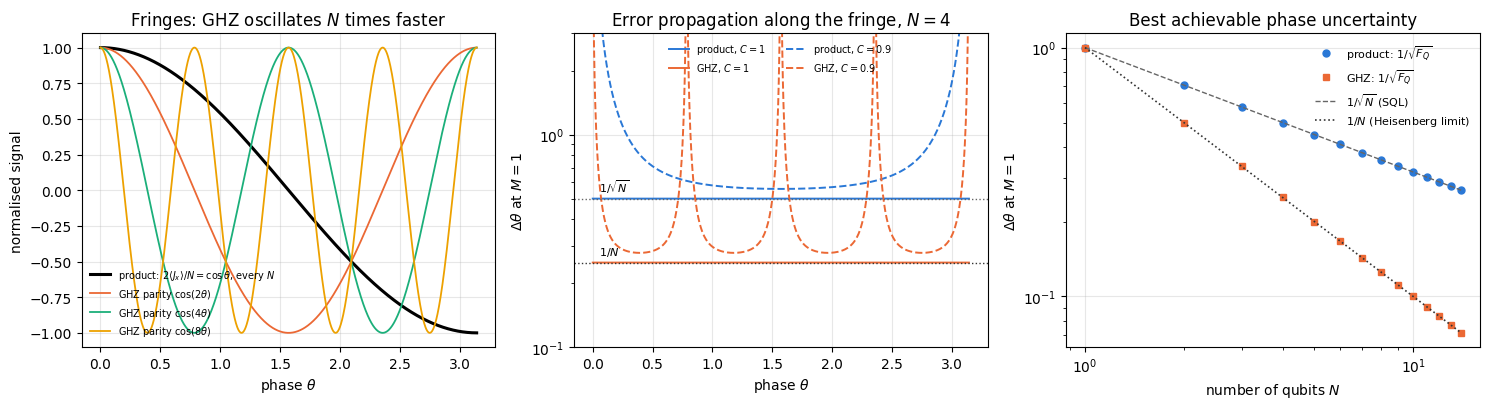

In [12]:
# ==============================================================================
# FIGURE: fringes, error propagation along the fringe, and the scaling with N
# ==============================================================================
N_FRINGE = (1, 2, 4, 8)
N_EP, C_EP = 4, 0.9                  # error-propagation panel: N, and a reduced contrast for comparison
thetas = np.linspace(1e-3, np.pi - 1e-3, 1200)
fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.2))
axes[0].plot(thetas, np.cos(thetas), color="k", lw=2.2, label=r"product: $2\langle J_x\rangle/N=\cos\theta$, every $N$")
for k, N in enumerate(N_FRINGE[1:]):
    axes[0].plot(thetas, np.cos(N * thetas), color=PALETTE[k + 1], lw=1.3, label=rf"GHZ parity $\cos({N}\theta)$")
axes[0].set_xlabel(r"phase $\theta$"); axes[0].set_ylabel("normalised signal")
axes[0].set_title("Fringes: GHZ oscillates $N$ times faster"); axes[0].legend(fontsize=7, loc="lower left")

def dtheta_prod(th, N, C):
    """Error propagation, Eq. (87), for J_x on |+>^N with contrast C (M = 1)."""
    return np.sqrt(1 - C ** 2 * np.cos(th) ** 2) / (C * np.sqrt(N) * np.abs(np.sin(th)))

def dtheta_ghz(th, N, C):
    """Error propagation for the parity of GHZ_N with contrast C (M = 1)."""
    return np.sqrt(1 - C ** 2 * np.cos(N * th) ** 2) / (C * N * np.abs(np.sin(N * th)))

for C, ls in ((1.0, "-"), (C_EP, "--")):
    axes[1].semilogy(thetas, dtheta_prod(thetas, N_EP, C), ls, color=PALETTE[0], lw=1.4,
                     label=rf"product, $C={C:g}$")
    axes[1].semilogy(thetas, dtheta_ghz(thetas, N_EP, C), ls, color=PALETTE[1], lw=1.4, label=rf"GHZ, $C={C:g}$")
axes[1].axhline(1 / np.sqrt(N_EP), color="0.4", ls=":", lw=1)
axes[1].axhline(1 / N_EP, color="0.2", ls=":", lw=1)
axes[1].text(0.05, 1 / np.sqrt(N_EP) * 1.08, r"$1/\sqrt{N}$", fontsize=8)
axes[1].text(0.05, 1 / N_EP * 1.08, r"$1/N$", fontsize=8)
axes[1].set_ylim(0.1, 3.0); axes[1].set_xlabel(r"phase $\theta$"); axes[1].set_ylabel(r"$\Delta\theta$ at $M=1$")
axes[1].set_title(f"Error propagation along the fringe, $N={N_EP}$"); axes[1].legend(fontsize=7, loc="upper center", ncol=2)

Ns = np.array([r[0] for r in rows_scale], dtype=float)
axes[2].loglog(Ns, 1 / np.sqrt([r[1] for r in rows_scale]), "o", color=PALETTE[0], ms=5, label=r"product: $1/\sqrt{F_Q}$")
axes[2].loglog(Ns, 1 / np.sqrt([r[2] for r in rows_scale]), "s", color=PALETTE[1], ms=5, label=r"GHZ: $1/\sqrt{F_Q}$")
axes[2].loglog(Ns, 1 / np.sqrt(Ns), "--", color="0.4", lw=1, label=r"$1/\sqrt{N}$ (SQL)")
axes[2].loglog(Ns, 1 / Ns, ":", color="0.2", lw=1.2, label=r"$1/N$ (Heisenberg limit)")
axes[2].set_xlabel("number of qubits $N$"); axes[2].set_ylabel(r"$\Delta\theta$ at $M=1$")
axes[2].set_title("Best achievable phase uncertainty"); axes[2].legend(fontsize=8)
fig.tight_layout(); plt.show()

All state-vector checks hold to round-off: the gate-by-gate encoding of the GHZ state reproduces Eq. (98), its
parity is $\cos(N\theta)$, and the product state has the signal and projection noise of Eq. (95). The
quantum Fisher information is exactly $N$ for the product state and $N^2$ for the GHZ state at every $N$, so the
ratios of Eq. (106) are $N$ in Fisher information and $\sqrt N$ in error ($3.74$ at $N=14$).

The left panel shows where the advantage comes from. The normalised product-state signal is the same curve for every
$N$, while the GHZ parity completes $N$ oscillations in the same phase interval; its slope is $N$ times steeper and its
noise, $\vert\sin N\theta\vert\le1$, does not grow with $N$. The middle panel evaluates Eq. (87) along the fringe. With
perfect contrast both curves are flat, at $1/\sqrt N$ and $1/N$, because slope and noise vanish together at the fringe
extrema. A reduced fringe contrast $C<1$ of each measured signal (modelled as $\langle X_i\rangle=C\cos\theta$ with
variance $1-C^2\cos^2\theta$ for the product state, and $\langle\Pi\rangle=C\cos N\theta$ for the GHZ parity) leaves a
non-zero noise at the extrema while the slope still vanishes there: error propagation diverges at $\theta=k\pi$ for the
product state and at $\theta=k\pi/N$ for the GHZ state, which has $N$ times as many blind spots. The right panel is the
scaling of $1/\sqrt{F_Q}$ with $N$: slope $-1/2$ for the product state and $-1$ for the GHZ state.

### 9.1 A simulated estimation

The bounds are statements about estimators, so we finally estimate. For each probe we draw the outcomes of $M$
repetitions from the exact distributions of Section 7 and apply the maximum-likelihood estimator of Eq. (35). For the
product state the $N$ spins of one run are independent, so the total number $n$ of $+$ results in $M$ runs is binomial
with $NM$ trials and success probability $(1+\cos\theta)/2$, and $\hat\theta=\arccos(2n/(NM)-1)$. For the GHZ state each
run gives one parity bit, the number $k$ of $+1$ parities is binomial with $M$ trials and probability $(1+\cos N\theta)/2$,
and $\hat\theta=\arccos(2k/M-1)/N$. To compare like with like, both probes work at the same point of their own fringe,
$\theta_0=\pi/3$ for the product state and $N\theta_0=\pi/3$ for the GHZ state, which also places the GHZ phase inside
the interval $(0,\pi/N)$ where the inversion is unique. For each $N$ we repeat the whole experiment $R=4000$ times and
compare the scatter of $\hat\theta$ with the exact finite-$M$ variance (the binomial sum of Section 4.8) and with the
bounds $1/\sqrt{NM}$ and $1/(N\sqrt M)$. The wrong control asserts SQL scaling for the GHZ data.

In [13]:
# ==============================================================================
# STEP 8: simulated estimation with both probes -- the scatter of theta_hat against the bounds
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
N_EST   = (1, 2, 4, 8, 16)           # probe sizes
M_EST   = 400                        # repetitions per experiment
R_EST   = 4000                       # independent experiments per point (for the scatter and its error bar)
PHI_EST = np.pi / 3                  # working point on the fringe: theta0 = PHI_EST (product), N theta0 = PHI_EST (GHZ)
# -----------------------------------------------------------------------------
est_rows = []
key_est = jax.random.PRNGKey(41)
print(f"{'N':>3s} | {'sqrt(NM) sd(prod)':>18s} {'exact':>7s} | {'N sqrt(M) sd(GHZ)':>18s} {'exact':>7s} | {'sd ratio':>9s} {'1/sqrt(N)':>9s}")
for i, N in enumerate(N_EST):
    kp, kg = jax.random.split(jax.random.fold_in(key_est, i))
    p_prod = (1 + np.cos(PHI_EST)) / 2                                     # same for both probes by construction
    n_plus = jax.random.binomial(kp, N * M_EST, p_prod, shape=(R_EST,))     # product: N M independent spins
    k_plus = jax.random.binomial(kg, M_EST, p_prod, shape=(R_EST,))         # GHZ: M parity bits
    th_prod = np.arccos(np.clip(2 * np.asarray(n_plus) / (N * M_EST) - 1, -1, 1))
    th_ghz = np.arccos(np.clip(2 * np.asarray(k_plus) / M_EST - 1, -1, 1)) / N
    sd_p, sd_g = th_prod.std(ddof=1), th_ghz.std(ddof=1)
    se_p, se_g = sd_p / np.sqrt(2 * (R_EST - 1)), sd_g / np.sqrt(2 * (R_EST - 1))   # standard error of a std
    v_p = ml_exact_moments(PHI_EST, N * M_EST)[1]                         # exact finite-M variances
    v_g = ml_exact_moments(PHI_EST, M_EST)[1] / N ** 2
    est_rows.append((N, sd_p, se_p, np.sqrt(v_p), sd_g, se_g, np.sqrt(v_g)))
    print(f"{N:3d} | {sd_p * np.sqrt(N * M_EST):9.4f} +- {se_p * np.sqrt(N * M_EST):5.4f} {np.sqrt(v_p * N * M_EST):7.4f} | "
          f"{sd_g * N * np.sqrt(M_EST):9.4f} +- {se_g * N * np.sqrt(M_EST):5.4f} {np.sqrt(v_g) * N * np.sqrt(M_EST):7.4f} | "
          f"{sd_g / sd_p:9.4f} {1 / np.sqrt(N):9.4f}")
    # CHECKPOINT: the sampled scatter agrees with the exact finite-M value within 4 standard errors
    assert abs(sd_p - np.sqrt(v_p)) < 4 * se_p and abs(sd_g - np.sqrt(v_g)) < 4 * se_g
    # CHECKPOINT: at M = 400 the exact scatter is within 3% of the Cramer-Rao bound for both probes
    assert abs(np.sqrt(v_p * N * M_EST) - 1) < 0.03 and abs(np.sqrt(v_g) * N * np.sqrt(M_EST) - 1) < 0.03
# WRONG CONTROL: "the GHZ probe only reaches the SQL", sd = 1/sqrt(N M), rejected at N = 16
N_w, _, _, _, sd_w, se_w, _ = est_rows[-1]
z_w = abs(sd_w - 1 / np.sqrt(N_w * M_EST)) / se_w
print(f"\nwrong control: SQL scaling for the GHZ data at N = {N_w} is off by {z_w:.0f} standard errors")
assert z_w > 8

  N |  sqrt(NM) sd(prod)   exact |  N sqrt(M) sd(GHZ)   exact |  sd ratio 1/sqrt(N)


  1 |    0.9942 +- 0.0111  1.0019 |    0.9943 +- 0.0111  1.0019 |    1.0001    1.0000
  2 |    0.9865 +- 0.0110  1.0009 |    1.0065 +- 0.0113  1.0019 |    0.7214    0.7071
  4 |    1.0076 +- 0.0113  1.0005 |    1.0106 +- 0.0113  1.0019 |    0.5015    0.5000
  8 |    1.0082 +- 0.0113  1.0002 |    1.0060 +- 0.0112  1.0019 |    0.3528    0.3536
 16 |    1.0054 +- 0.0112  1.0001 |    0.9805 +- 0.0110  1.0019 |    0.2438    0.2500

wrong control: SQL scaling for the GHZ data at N = 16 is off by 275 standard errors


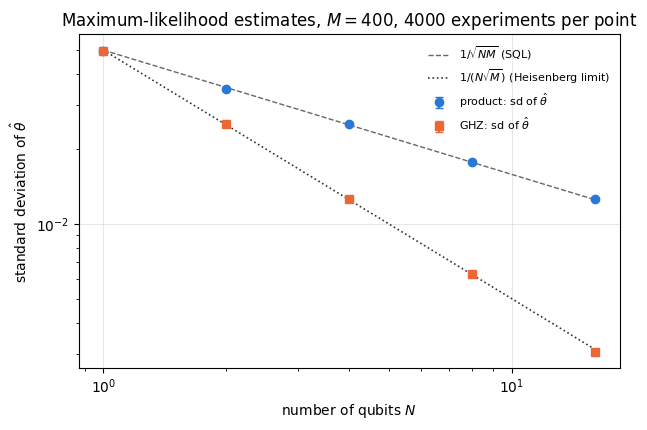

In [14]:
# ==============================================================================
# FIGURE: scatter of the estimates against the two bounds
# ==============================================================================
er = np.array(est_rows)
Ne = er[:, 0]
fig, ax = plt.subplots(figsize=(6.4, 4.4))
ax.errorbar(Ne, er[:, 1], yerr=er[:, 2], fmt="o", color=PALETTE[0], ms=6, capsize=3, label=r"product: sd of $\hat\theta$")
ax.errorbar(Ne, er[:, 4], yerr=er[:, 5], fmt="s", color=PALETTE[1], ms=6, capsize=3, label=r"GHZ: sd of $\hat\theta$")
Nf = np.logspace(0, np.log10(16), 50)
ax.loglog(Nf, 1 / np.sqrt(Nf * M_EST), "--", color="0.4", lw=1, label=r"$1/\sqrt{NM}$ (SQL)")
ax.loglog(Nf, 1 / (Nf * np.sqrt(M_EST)), ":", color="0.2", lw=1.2, label=r"$1/(N\sqrt{M})$ (Heisenberg limit)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("number of qubits $N$"); ax.set_ylabel(r"standard deviation of $\hat\theta$")
ax.set_title(f"Maximum-likelihood estimates, $M={M_EST}$, {R_EST} experiments per point"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

The sampled standard deviations lie on the exact finite-$M$ values within their error bars, and at $M=400$ those exact
values are within $0.2\%$ of the Cramér–Rao bound (asserted at $3\%$). The product-state scatter follows
$1/\sqrt{NM}$ and the GHZ scatter $1/(N\sqrt M)$; their ratio agrees with $1/\sqrt N$ within two standard errors
(the statistical error of each ratio is about $1.6\%$). The wrong control
rejects SQL scaling for the GHZ data by the printed number of standard errors. (In the figure the error bars, about
$1\%$ of each value, are smaller than the markers.) These are ideal probes. Section 10 shows
what happens to the GHZ advantage when one particle is lost or each particle suffers a small error; the full
protocols, with the readout and the estimator analysed in detail, are
[31 — Ramsey interferometry](../ch10_quantum_metrology_protocols/31_ramsey_interferometry.ipynb) for the product state and
[32 — GHZ interferometry](../ch10_quantum_metrology_protocols/32_ghz_interferometry_heisenberg_limit.ipynb) (Sections 6–9)
for the GHZ state, including the $2\pi/N$ ambiguity that the restriction to $(0,\pi/N)$ sidesteps here.

## 10. The fragility of the GHZ advantage

The factor $N$ in $F_Q=N^2$ comes from one coherence: the relative phase between $\vert\bar0\rangle$ and $\vert\bar1\rangle$,
two states that differ on every particle. Anything that reveals or randomises the state of a single particle acts on
that coherence. This section derives the four consequences that matter in practice.

### 10.1 Losing one particle

Suppose the phase is imprinted on all $N$ qubits but the last one is lost before the readout. The surviving $N-1$ qubits
are described by the partial trace over the lost one. For the GHZ state the cross terms
$\vert\bar0\rangle\langle\bar1\vert$ and $\vert\bar1\rangle\langle\bar0\vert$ contain $\vert0\rangle\langle1\vert$ on the
lost qubit, whose trace is $\langle1\vert0\rangle=0$, so only the two diagonal terms survive:

$$\rho_A=\mathrm{Tr}_N\vert\mathrm{GHZ}\rangle\langle\mathrm{GHZ}\vert
  =\frac12\left(\vert0\cdots0\rangle\langle0\cdots0\vert+\vert1\cdots1\rangle\langle1\cdots1\vert\right) , \tag{107}$$

with $N-1$ entries in each string. The encoding of the lost qubit drops out of the partial trace (the generator is a sum
of single-qubit terms), so the survivors see $U_A=e^{-i\theta J_z^{(A)}}$. Both $\rho_A$ and $J_z^{(A)}$ are diagonal in the
computational basis, so they commute, and

$$U_A\rho_AU_A^\dagger=\rho_AU_AU_A^\dagger=\rho_A,\qquad \partial_\theta\rho_A=-i\left[J_z^{(A)},\rho_A\right]=0,\qquad F_Q=0 \tag{108}$$

by Eq. (48). The mixture of two eigenstates of the generator does not change under the encoding at all. One lost
particle removes the whole phase information. The product state loses only the contribution of the missing spin: the
survivors form $\vert+\rangle^{\otimes(N-1)}$, and Eq. (92) gives $F_Q=N-1$.

### 10.2 Independent dephasing, the optimal size, and the crossing

The dephasing channel of the engine, `kraus_dephasing(p)`, applies a $Z$ error with probability $p$ to one qubit,
$\rho\to(1-p)\rho+pZ\rho Z$. Conjugation by $Z$ leaves the diagonal of a single-qubit density matrix unchanged and flips
the sign of the off-diagonal elements, so the coherence becomes $(1-p)\rho_{01}-p\rho_{01}=(1-2p)\rho_{01}$. Applied to
qubit $i$ of the GHZ state, $Z_i\vert\bar0\rangle=\vert\bar0\rangle$ and $Z_i\vert\bar1\rangle=-\vert\bar1\rangle$, so
$Z_i\vert\bar0\rangle\langle\bar1\vert Z_i=-\vert\bar0\rangle\langle\bar1\vert$ and the GHZ coherence is multiplied by $1-2p$.
After independent dephasing of all $N$ qubits,

$$\rho(p)=\frac12\Big(\vert\bar0\rangle\langle\bar0\vert+\vert\bar1\rangle\langle\bar1\vert\Big)
  +\frac{c}{2}\Big(\vert\bar0\rangle\langle\bar1\vert+\vert\bar1\rangle\langle\bar0\vert\Big),\qquad c=(1-2p)^N . \tag{109}$$

The state stays in the two-dimensional subspace spanned by $\vert\bar0\rangle$ and $\vert\bar1\rangle$, i.e. it has rank
two. (Dephasing commutes with the encoding, because both are diagonal, so it does not matter whether it acts before or
after.) Both probes now reduce to the same calculation for a two-level system. Consider
$\rho=\tfrac12\begin{pmatrix}1&c\\c&1\end{pmatrix}$ and the generator $\tfrac\omega2\sigma_z$ in a basis $\{\vert a\rangle,\vert b\rangle\}$.
The eigenvalues of $\rho$ are $\lambda_\pm=\tfrac12(1\pm c)$ with eigenvectors $\vert\pm\rangle=(\vert a\rangle\pm\vert b\rangle)/\sqrt2$,
and $\sigma_z\vert\pm\rangle=\vert\mp\rangle$, so $\langle+\vert\tfrac\omega2\sigma_z\vert-\rangle=\tfrac\omega2$. Equation (49) has
the two terms $(m,n)=(+,-)$ and $(-,+)$, with $(\lambda_+-\lambda_-)^2=c^2$ and $\lambda_++\lambda_-=1$:

$$F_Q=2\cdot2\cdot\frac{c^2}{1}\cdot\frac{\omega^2}{4}=\omega^2c^2 . \tag{110}$$

For the GHZ state the two levels are $\vert\bar0\rangle,\vert\bar1\rangle$, $J_z$ acts as $\tfrac N2\sigma_z$ by
Eq. (97), so $\omega=N$ and $c=(1-2p)^N$. For the product state each qubit is a two-level system with $\omega=1$ and
coherence $c=1-2p$, and the $N$ dephased qubits are still a product, so Eq. (60) adds their contributions:

$$F_Q^{\text{GHZ}}(p)=N^2(1-2p)^{2N},\qquad F_Q^{\text{prod}}(p)=N(1-2p)^2 . \tag{111}$$

The Heisenberg value is multiplied by a factor that decreases exponentially with $N$, the product value by a constant.
At fixed $p$ the GHZ value therefore has a maximum. Setting the derivative of $\ln F_Q^{\text{GHZ}}=2\ln N+2N\ln(1-2p)$ to
zero,

$$\frac{2}{N}+2\ln(1-2p)=0\quad\Longrightarrow\quad N^\ast=-\frac{1}{\ln(1-2p)}\approx\frac{1}{2p},\qquad
  F_Q^{\text{GHZ}}(N^\ast)=\frac{e^{-2}}{\ln^2(1-2p)} . \tag{112}$$

Beyond $N^\ast$ adding particles to the GHZ state lowers its quantum Fisher information, and beyond the crossing
$N_\times$, the solution with $N_\times>1$ of $F_Q^{\text{GHZ}}=F_Q^{\text{prod}}$, i.e. of

$$N_\times(1-2p)^{2N_\times-2}=1 , \tag{113}$$

the GHZ state is worse than the unentangled probe. The product value $N(1-2p)^2$ keeps growing linearly.

### 10.3 Correlated noise: superdecoherence

The dephasing of Section 10.2 acts independently on each qubit. Many laboratory noise sources act collectively instead:
a fluctuating magnetic field or laser phase shifts every qubit by the same random angle. To compare the two cases at the
same single-qubit strength, let each qubit acquire a random phase through $e^{-i\phi_iZ_i/2}$, with Gaussian phases of
zero mean and variance $\sigma^2$. Under $e^{-i\phi_iZ_i/2}$ the branch $\vert\bar0\rangle$ gains $e^{-i\phi_i/2}$ and the
branch $\vert\bar1\rangle$ gains $e^{+i\phi_i/2}$, so the coherence $\vert\bar0\rangle\langle\bar1\vert$ is multiplied by
$e^{-i\phi_i}$, and by $e^{-i\sum_i\phi_i}$ after all $N$ qubits. Averaging over the noise uses the Gaussian identity
$\mathbb E[e^{ia\phi}]=e^{-a^2\sigma_\phi^2/2}$ for a zero-mean Gaussian $\phi$ of variance $\sigma_\phi^2$.

* **Independent (local) phases**: $\sum_i\phi_i$ has variance $N\sigma^2$.
* **Correlated (collective) phase**: all $\phi_i=\phi$, so $\sum_i\phi_i=N\phi$ has variance $N^2\sigma^2$.

With the phase diffusing in time, $\sigma^2=2\gamma t$, so that a single qubit loses coherence as $e^{-\gamma t}$, the GHZ
coherence decays as

$$C_{\text{local}}(t)=e^{-N\sigma^2/2}=e^{-N\gamma t},\qquad C_{\text{coll}}(t)=e^{-N^2\sigma^2/2}=e^{-N^2\gamma t} . \tag{114}$$

The local rate grows like $N$; the collective rate grows like $N^2$, which is called **superdecoherence**. (Local
Gaussian phases are the dephasing channel of Section 10.2 with $1-2p=e^{-\sigma^2/2}$.) Collective noise has exactly the
form of the signal: it is a random rotation generated by the same $J_z$ that writes $\theta$ into the state. The $N$-fold
amplification of the phase that produces the Heisenberg gain amplifies the noise phase in the same way. Monz *et al.*
(2011) created GHZ states of up to $14$ trapped ions and observed, for up to $8$ ions, a decay of the GHZ coherence
proportional to the square of the number of qubits, in agreement with a model of correlated Gaussian phase noise.

The quantum Fisher information follows from the same two-level formula (110) with $\omega=N$ and
$c=e^{-N^2\sigma^2/2}$:

$$F_Q^{\text{GHZ}}=N^2e^{-N^2\sigma^2},\qquad \max_NF_Q^{\text{GHZ}}=\frac{e^{-1}}{\sigma^2}\ \ \text{at}\ \ N=\frac1\sigma . \tag{115}$$

The product state is not protected by its lack of entanglement. A single qubit loses coherence at the single-qubit rate,
$F_Q=e^{-\sigma^2}$ by Eq. (110), but for $N>1$ the common phase correlates the qubits, the state is no longer a
product, and Eq. (60) does not apply: $F_Q\neq Ne^{-\sigma^2}$. Averaging the random rotation multiplies each element
of the density matrix between $J_z$ eigenstates with eigenvalues $m$ and $m'$ by $e^{-(m-m')^2\sigma^2/2}$, and the code
below evaluates Eq. (49) for this state exactly. No closed form is needed to understand the result, because two
elementary arguments enclose it from above and from below.

*Upper bound, for every probe.* Fix any POVM and let $q(x\vert\varphi)=\mathrm{Tr}\big(E_x\,e^{-i\varphi J_z}\rho\,e^{i\varphi J_z}\big)$
be its outcome distribution for the noiseless probe rotated by an angle $\varphi$; its score
$s_q=\partial_\varphi\ln q$ has mean zero and mean square $F_C^{(0)}(\varphi)\le F_Q^{(0)}$, the quantum Fisher information
of the noiseless probe (Eqs. (12) and (50); for the product state $F_Q^{(0)}=N$ at every $\varphi$). Under collective noise
the probe is rotated by $\varphi=\theta+\phi$, so with $g$ the Gaussian density of $\phi$

$$p(x\vert\theta)=\int d\phi\,g(\phi)\,q(x\vert\theta+\phi)=\int d\varphi\,g(\varphi-\theta)\,q(x\vert\varphi) . \tag{115a}$$

Differentiating the first form under the integral gives $\partial_\theta p=\int d\varphi\,g\,q\,s_q$; differentiating the
second, with $\partial_\theta g(\varphi-\theta)=g(\varphi-\theta)\,(\varphi-\theta)/\sigma^2$, gives
$\partial_\theta p=\int d\varphi\,g\,q\,(\varphi-\theta)/\sigma^2$. Divide both by $p$. The weights
$w(\varphi\vert x)=g(\varphi-\theta)\,q(x\vert\varphi)/p(x\vert\theta)$ are non-negative and integrate to one (they are the
distribution of $\varphi$ given the outcome $x$), so both expressions for the score are averages over $w$, and so is
every combination of them with $a+b=1$:

$$s(x\vert\theta)=\Big\langle a\,s_q(x\vert\varphi)+b\,\frac{\varphi-\theta}{\sigma^2}\Big\rangle_{w} . \tag{115b}$$

The square of an average is at most the average of the square (a variance is non-negative). Multiply by
$p(x\vert\theta)$, sum over $x$ and integrate over $\varphi$; the product $p\,w=g(\varphi-\theta)\,q(x\vert\varphi)$ is the
joint distribution of $\varphi$ and $x$. The cross term vanishes because $\sum_xq\,s_q=0$, the first term is at most
$a^2F_Q^{(0)}$, and $\int d\varphi\,g\,(\varphi-\theta)^2/\sigma^4=1/\sigma^2$:

$$F_C(\theta;\{E_x\})\;\le\;a^2F_Q^{(0)}+\frac{b^2}{\sigma^2}\qquad\text{for every }a+b=1 . \tag{115c}$$

The right-hand side is smallest at $a=1/(1+F_Q^{(0)}\sigma^2)$. Maximising the left-hand side over all POVMs with
Eq. (58) then gives

$$F_Q\;\le\;\frac{F_Q^{(0)}}{1+F_Q^{(0)}\sigma^2}\;<\;\frac{1}{\sigma^2},\qquad\text{i.e.}\qquad
  \frac{1}{F_Q}\;\ge\;\frac{1}{F_Q^{(0)}}+\sigma^2 . \tag{115d}$$

The variance $\sigma^2$ of the common phase adds to the variance $1/F_Q^{(0)}$ of the noiseless estimate. The choices
$a=1$ and $a=0$ in Eq. (115c) give the two simple limits: noise never increases the quantum Fisher information, and no
probe, however entangled, learns $\theta$ better than a single reading of $\theta+\phi$, whose Fisher information is
$1/\sigma^2$ (Eq. (20) with $h'=1$). For the product state Eq. (115d) reads $F_Q\le N/(1+N\sigma^2)$.

*Lower bound, for the product state.* Since the averaged noise commutes with the encoding, $F_Q$ does not depend on
$\theta$, and any measurement at any working point bounds it from below. Measure $J_x$ at $\theta=\pi/2$. For the product
state rotated by an angle $\alpha$, $\langle X_i\rangle=\cos\alpha$ and $\langle X_iX_j\rangle=\cos^2\alpha$ for $i\neq j$, so
$\langle J_x\rangle=\tfrac N2\cos\alpha$ and $\langle J_x^2\rangle=\tfrac14\left(N+N(N-1)\cos^2\alpha\right)$, as in
Eq. (91). Average over $\alpha=\theta+\phi$ with the Gaussian identity,
$\mathbb E[\cos(\theta+\phi)]=e^{-\sigma^2/2}\cos\theta$ and $\mathbb E[\cos^2(\theta+\phi)]=\tfrac12\left(1+e^{-2\sigma^2}\cos2\theta\right)$.
At $\theta=\pi/2$ the slope of the signal is $\tfrac N2e^{-\sigma^2/2}$ and its variance
$\tfrac N4+\tfrac{N(N-1)}{8}\left(1-e^{-2\sigma^2}\right)$, and Eq. (89) gives

$$F_Q\;\ge\;\frac{N\,e^{-\sigma^2}}{1+\tfrac12(N-1)\left(1-e^{-2\sigma^2}\right)} . \tag{115e}$$

At $N=1$ this is $e^{-\sigma^2}$, the exact value. Expanding both bounds in $\sigma^2$ gives $N-N^2\sigma^2+O(\sigma^4)$ for
each, so they differ only at order $\sigma^4$: for $\sigma^2\ll1$ the product-state value is $N/(1+N\sigma^2)$ to that
accuracy, growing like $N$ while $N\sigma^2\ll1$ and then saturating at the ceiling $1/\sigma^2$. (For $\sigma^2$ of order
one the bounds separate, because Eq. (115d) ignores that a phase is defined only modulo $2\pi$.) STEP 10 evaluates the
exact value and both bounds. The product state approaches the ceiling smoothly; the GHZ state reaches at most $e^{-1}$
of it and then collapses.

### 10.4 Practical problems of GHZ metrology

* **Preparation.** The GHZ state is made by a Hadamard gate followed by a chain of CNOT gates
  ([22 — GHZ states and decoherence](../ch08_quantum_information_protocols/22_ghz_states_and_decoherence.ipynb)), at least
  $N-1$ entangling gates. Every gate error that flips or dephases one qubit acts on the one coherence that carries the
  phase, so preparation errors accumulate with $N$ in the same way as the dephasing of Section 10.2.
* **Readout.** The parity needs every one of the $N$ single-qubit results. If each result is flipped independently with
  probability $\epsilon$, the recorded value of qubit $i$ is $f_ix_i$ with $f_i=-1$ with probability $\epsilon$ and $+1$
  otherwise, so $\mathbb E[f_i]=1-2\epsilon$, and the recorded parity has mean

$$\mathbb E\Big[\prod_if_ix_i\Big]=\prod_i\mathbb E[f_i]\;\langle\Pi\rangle_\theta=(1-2\epsilon)^N\cos(N\theta) . \tag{116}$$

  The fringe contrast falls exponentially with $N$, and with it the Fisher information of the parity, whose maximum over
  $\theta$ is $N^2(1-2\epsilon)^{2N}$ (notebook 32, Section 10.2) — the same form as Eq. (111).
* **Dynamic range.** The parity $\cos(N\theta)$ determines $\theta$ only modulo $2\pi/N$. A GHZ interferometer needs prior
  knowledge of $\theta$ to that precision, or a combination of probes of different sizes (notebook 32, Section 9).
* **Noise during the interrogation.** When dephasing acts continuously while the phase is accumulated, at a rate $\gamma$
  per qubit, the interrogation time itself must be optimised. Huelga *et al.* (1997) showed that for frequency
  estimation under such Markovian dephasing, optimal measurements on maximally entangled states give the same resolution
  as standard Ramsey spectroscopy on uncorrelated atoms, and that the best resolution is reached with partially entangled
  preparations. Notebook 32 (Section 13) derives the GHZ result and states the later theorem that no probe beats
  uncorrelated atoms by more than a constant factor ($\sqrt e$ for this noise model), so the Heisenberg scaling is lost.

The notebooks that follow develop these points: [32 — GHZ interferometry](../ch10_quantum_metrology_protocols/32_ghz_interferometry_heisenberg_limit.ipynb)
(decoherence in Section 10, fragility against the atom number in Section 11, the loss of one atom in Section 12),
[33 — spin squeezing by one-axis twisting](../ch10_quantum_metrology_protocols/33_spin_squeezing_one_axis_twisting.ipynb)
and [34 — from one-axis twisting to GHZ](../ch10_quantum_metrology_protocols/34_oat_to_ghz_full_metrology_protocol.ipynb)
(more robust probes, and the four protocols compared under noise in Section 12), and
[37 — particle loss, magic and encoded probes](../ch10_quantum_metrology_protocols/37_qfi_particle_loss_and_magic.ipynb)
(particle loss in detail).

The code below checks Sections 10.1 and 10.2 with density matrices. The reduced state after the loss of one qubit is
formed with `rdm`, and the dephased states with one Kraus channel per qubit (`apply_kraus_dm`, the einsum of
[07](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb) that never builds the $4^N\times4^N$
superoperator); the quantum Fisher information of each mixed state is Eq. (49) (`qfi_mixed`). Wrong controls: the
GHZ state after a loss is *not* worth $(N-1)^2$, and dephasing does *not* reduce its QFI by the single-qubit factor
$(1-2p)^2$ alone.

In [15]:
# ==============================================================================
# STEP 9: fragility of GHZ -- one lost particle, independent dephasing, N* and the crossing
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
N_LOST   = range(2, 11)                       # probe sizes for the loss check (reduced states up to 2^9 x 2^9)
N_DEPH   = (2, 3, 4, 5, 6)                    # density tensors up to 2^6 x 2^6
P_DEPH   = (0.005, 0.02, 0.05, 0.10, 0.25)    # dephasing probabilities
P_SHOW   = (0.005, 0.02, 0.05)                # probabilities shown in the figure
# -----------------------------------------------------------------------------


def apply_local_channel(rho, kraus_fn, p, qubits=None):
    """Apply the SAME single-qubit channel to each listed qubit of a density TENSOR.

    MATH   rho -> (E_p (x) E_p (x) ... ) rho,  each E_p(sigma) = sum_m K_m sigma K_m^dagger.
    COST   O(N 4^N) -- one `apply_kraus_dm` einsum per qubit; the 4^N x 4^N superoperator never exists.
    """
    N = rho.ndim // 2
    qubits = range(N) if qubits is None else qubits
    K = kraus_fn(p)
    for q in qubits:
        rho = apply_kraus_dm(rho, K, [q])
    return rho


def qfi_noisy(rho_tensor, n, N):
    """QFI of a mixed state for the generator n.J, via the engine's mixed-state (SLD) formula, Eq. (49)."""
    return qfi_mixed(dm_matrix(rho_tensor), collective_dense(pauli_direction(n), N))


# (a) one particle lost -- Eqs. (107), (108)
print(f"{'N':>3s} | {'F_Q(GHZ, N-1 kept)':>19s} {'||[rho_A, J_z]||':>17s} | {'F_Q(product, N-1 kept)':>23s}")
for N in N_LOST:
    Jz_A = collective_dense(Z, N - 1)
    rho_g = rdm(ghz_state(N), range(N - 1))
    f_g, comm = float(qfi_mixed(rho_g, Jz_A)), max_abs(rho_g @ Jz_A - Jz_A @ rho_g)
    f_p = float(qfi_mixed(rdm(product_state("+" * N), range(N - 1)), Jz_A))
    print(f"{N:3d} | {f_g:19.2e} {comm:17.2e} | {f_p:23.10f}")
    assert f_g < 1e4 * TOL and comm < 1e4 * TOL and abs(f_p - (N - 1)) < 1e4 * TOL
    assert abs(f_g - (N - 1) ** 2) > 0.5                                  # WRONG CONTROL: "(N-1)^2 survives"

# (b) independent dephasing -- Eq. (111)
print(f"\n{'N':>3s} {'p':>6s} | {'F_Q GHZ':>12s} {'N^2(1-2p)^2N':>13s} | {'F_Q product':>12s} {'N(1-2p)^2':>10s}")
err_deph, fq_deph_ghz = 0.0, {}
for N in N_DEPH:
    for p in P_DEPH:
        f_g = float(qfi_noisy(apply_local_channel(to_dm(ghz_state(N)), kraus_dephasing, p), (0, 0, 1), N))
        f_p = float(qfi_noisy(apply_local_channel(to_dm(product_state("+" * N)), kraus_dephasing, p), (0, 0, 1), N))
        a_g, a_p = N ** 2 * (1 - 2 * p) ** (2 * N), N * (1 - 2 * p) ** 2
        fq_deph_ghz[(N, p)] = f_g                                         # reused by the figure below
        err_deph = max(err_deph, abs(f_g - a_g), abs(f_p - a_p))
        if p in (0.02, 0.10):
            print(f"{N:3d} {p:6.3f} | {f_g:12.8f} {a_g:13.8f} | {f_p:12.8f} {a_p:10.8f}")
        if p >= 0.02:                                                     # WRONG CONTROL: single-qubit factor only
            assert abs(f_g - N ** 2 * (1 - 2 * p) ** 2) > 1e-2
print(f"max deviation from Eq. (111) over {len(N_DEPH)} x {len(P_DEPH)} x 2 cases: {err_deph:.2e}")
assert err_deph < 1e4 * TOL


def crossing_size(p):
    """N_x > 1 solving N (1-2p)^(2N-2) = 1, Eq. (113), by bisection on [N*/2, 100 N*]."""
    lc = np.log(1 - 2 * p)
    f = lambda n: np.log(n) + (2 * n - 2) * lc
    lo, hi = -0.5 / lc, -100 / lc                 # f(lo) > 0 (the maximum of f is at N = N*/2), f(hi) < 0
    for _ in range(200):
        mid = 0.5 * (lo + hi)
        lo, hi = (mid, hi) if f(mid) > 0 else (lo, mid)
    return 0.5 * (lo + hi)


print(f"\n{'p':>6s} | {'N* = -1/ln(1-2p)':>17s} {'max F_Q(GHZ)':>13s} | {'crossing N_x':>13s}")
nstar_rows = {}
for p in P_SHOW:
    ns, nx = -1 / np.log(1 - 2 * p), crossing_size(p)
    nstar_rows[p] = (ns, nx)
    n_int = np.arange(1, int(3 * ns))                                    # brute-force check of the maximum
    assert abs(n_int[np.argmax(n_int ** 2 * (1 - 2 * p) ** (2 * n_int))] - ns) < 1.0
    assert abs(nx * (1 - 2 * p) ** (2 * nx - 2) - 1) < 1e-10
    print(f"{p:6.3f} | {ns:17.2f} {np.exp(-2) / np.log(1 - 2 * p) ** 2:13.2f} | {nx:13.1f}")

  N |  F_Q(GHZ, N-1 kept)  ||[rho_A, J_z]|| |  F_Q(product, N-1 kept)


  2 |            0.00e+00          0.00e+00 |            1.0000000000


  3 |            0.00e+00          0.00e+00 |            2.0000000000


  4 |            0.00e+00          0.00e+00 |            3.0000000000


  5 |            0.00e+00          0.00e+00 |            4.0000000000
  6 |            0.00e+00          0.00e+00 |            5.0000000000


...

 10 |            0.00e+00          0.00e+00 |            9.0000000000

  N      p |      F_Q GHZ  N^2(1-2p)^2N |  F_Q product  N(1-2p)^2
  2  0.020 |   3.39738624    3.39738624 |   1.84320000 1.84320000
  2  0.100 |   1.63840000    1.63840000 |   1.28000000 1.28000000


  3  0.020 |   7.04482011    7.04482011 |   2.76480000 2.76480000
  3  0.100 |   2.35929600    2.35929600 |   1.92000000 1.92000000


  4  0.020 |  11.54223326   11.54223326 |   3.68640000 3.68640000
  4  0.100 |   2.68435456    2.68435456 |   2.56000000 2.56000000


  5  0.020 |  16.62081590   16.62081590 |   4.60800000 4.60800000
  5  0.100 |   2.68435456    2.68435456 |   3.20000000 3.20000000


  6  0.020 |  22.05755126   22.05755126 |   5.52960000 5.52960000
  6  0.100 |   2.47390116    2.47390116 |   3.84000000 3.84000000
max deviation from Eq. (111) over 5 x 5 x 2 cases: 2.84e-14

     p |  N* = -1/ln(1-2p)  max F_Q(GHZ) |  crossing N_x
 0.005 |             99.50       1339.83 |         281.6
 0.020 |             24.50         81.21 |          48.6
 0.050 |              9.49         12.19 |          13.3


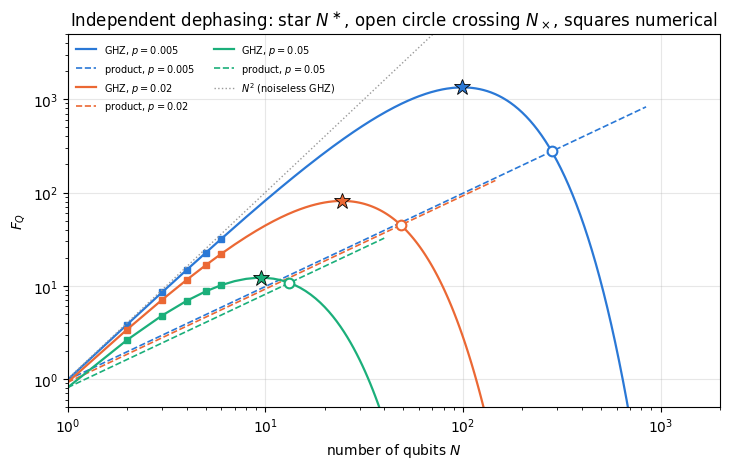

In [16]:
# ==============================================================================
# FIGURE: GHZ vs product state under independent dephasing
# ==============================================================================
fig, ax = plt.subplots(figsize=(7.4, 4.8))
for k, p in enumerate(P_SHOW):
    ns, nx = nstar_rows[p]
    Nl = np.unique(np.round(np.logspace(0, np.log10(3 * nx), 300)))
    ax.loglog(Nl, Nl ** 2 * (1 - 2 * p) ** (2 * Nl), "-", color=PALETTE[k], lw=1.6, label=rf"GHZ, $p={p}$")
    ax.loglog(Nl, Nl * (1 - 2 * p) ** 2, "--", color=PALETTE[k], lw=1.2, label=rf"product, $p={p}$")
    ax.plot(ns, ns ** 2 * (1 - 2 * p) ** (2 * ns), "*", color=PALETTE[k], ms=12, mec="k", mew=0.6)
    ax.plot(nx, nx * (1 - 2 * p) ** 2, "o", color=PALETTE[k], ms=7, mfc="white", mew=1.5)
    for N in N_DEPH:                                                     # density-matrix values computed in STEP 9
        ax.plot(N, fq_deph_ghz[(N, p)], "s", color=PALETTE[k], ms=4)
ax.loglog([1, 3000], [1, 3000 ** 2], ":", color="0.6", lw=1, label=r"$N^2$ (noiseless GHZ)")
ax.set_xlim(1, 2000); ax.set_ylim(0.5, 5e3)
ax.set_xlabel("number of qubits $N$"); ax.set_ylabel(r"$F_Q$")
ax.set_title(r"Independent dephasing: star $N^\ast$, open circle crossing $N_\times$, squares numerical")
ax.legend(fontsize=7, ncol=2, loc="upper left")
fig.tight_layout(); plt.show()

After the loss of one qubit the GHZ state has $F_Q=0$ to round-off for every $N$, and its reduced state commutes with
$J_z$, exactly as Eq. (108) states; the product state keeps $N-1$. The dephased states reproduce Eq. (111) to
round-off in all $50$ cases, and the wrong control confirms that the GHZ state pays the factor $(1-2p)^2$ once per qubit.

The figure puts Eq. (111) on a common scale. Each GHZ curve rises like $N^2$, peaks at the star $N^\ast$, Eq. (112),
and falls below the straight product-state line at the open circle $N_\times$. With $p=0.005$ the peak is at
$N^\ast\approx100$ and the GHZ advantage survives up to several hundred qubits; with $p=0.05$ the peak is at
$N^\ast\approx9.5$, where $F_Q^{\text{GHZ}}\approx12$, and beyond the crossing a product state of the same size is better.
An error rate per qubit therefore fixes the useful size of a GHZ probe, and the largest quantum Fisher information
it can deliver is about $e^{-2}/(4p^2)$.

The last code cell of this section checks Section 10.3. It first encodes a GHZ state of four qubits with $4000$ sampled
phase patterns, gate by gate, and compares the averaged coherence $2\vert\rho_{\bar0\bar1}\vert$ with Eq. (114) for
both noise models. It then estimates the decay of the coherence for $N=1,2,4,8$ from $400\,000$ samples of the phase sum
at $\sigma^2=0.1$ and fits the exponent $b$ of $-\ln C\propto N^b$, with error bars propagated from the Monte-Carlo
standard errors; the wrong control asserts the local exponent $b=1$ for the collective data. Finally it evaluates
Eq. (49) for both probes under collective dephasing. For $N\le6$ this uses the full $2^N\times2^N$ density matrix;
for larger $N$ the product state is treated in the $(N+1)$-dimensional symmetric subspace, where $\vert+\rangle^{\otimes N}$
has the binomial amplitudes $\sqrt{\binom Nk}/2^{N/2}$ on the $J_z$ eigenstates with $m=N/2-k$; the two routes are
compared where both are available, and the exact product-state values are compared with the bounds (115d) and (115e)
at $\sigma^2=0.01$, $0.1$ and $0.5$. The wrong control is the uncorrelated guess $Ne^{-\sigma^2}$.

In [17]:
# ==============================================================================
# STEP 10: superdecoherence -- independent vs collective Gaussian phase noise
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
SIG2_FIT  = 0.1                     # phase variance per qubit for the exponent fit
K_FIT     = 400_000                 # Monte-Carlo samples per (N, model)
N_SD      = (1, 2, 4, 8)
K_STATE   = 4000                    # samples for the state-level check at N = 4
SIG2_FQ   = 0.01                    # phase variance for the F_Q comparison
# -----------------------------------------------------------------------------


def ghz_coherence_samples(phis):
    """2 rho_{0..0, 1..1} of the GHZ state after the phase pattern exp(-i phi_q Z_q / 2) on every qubit q.

    JAX   phis has shape (N,); vmapped over samples below. Encoding gate by gate with apply_gate.
    """
    N = phis.shape[0]
    psi = ghz_state(N)
    for q in range(N):
        Rz = jnp.diag(jnp.exp(jnp.array([-0.5j, 0.5j]) * phis[q])).astype(CDTYPE)
        psi = apply_gate(psi, Rz, [q])
    return 2 * psi[(0,) * N] * jnp.conj(psi[(1,) * N])


# (1) state-level check at N = 4
ks1, ks2 = jax.random.split(jax.random.PRNGKey(51))
N4 = 4
phis_loc = jnp.sqrt(SIG2_FIT) * jax.random.normal(ks1, (K_STATE, N4))
phis_col = jnp.sqrt(SIG2_FIT) * jnp.repeat(jax.random.normal(ks2, (K_STATE, 1)), N4, axis=1)
print(f"state-level check, N = {N4}, sigma^2 = {SIG2_FIT}, {K_STATE} samples")
for name, phis, expo in (("local", phis_loc, N4), ("collective", phis_col, N4 ** 2)):
    c = jax.vmap(ghz_coherence_samples)(phis)                    # one coherence per sample; rho is their average
    m, se = float(jnp.real(jnp.mean(c))), float(jnp.std(jnp.real(c))) / np.sqrt(K_STATE)
    print(f"  {name:>10s}: coherence {m:.4f} +- {se:.4f}   Eq. (114): {np.exp(-expo * SIG2_FIT / 2):.4f}")
    assert abs(m - np.exp(-expo * SIG2_FIT / 2)) < 4 * se

# (2) decay exponent: -ln C = (rate) * t with rate ~ N^b
fit = {}
for j, model in enumerate(("local", "collective")):
    ys, sys_ = [], []
    for i, N in enumerate(N_SD):
        kk = jax.random.fold_in(jax.random.PRNGKey(52), 10 * j + i)
        if model == "local":
            phase_sum = jnp.sum(jnp.sqrt(SIG2_FIT) * jax.random.normal(kk, (K_FIT, N)), axis=1)
        else:
            phase_sum = N * jnp.sqrt(SIG2_FIT) * jax.random.normal(kk, (K_FIT,))
        cosv = np.asarray(jnp.cos(phase_sum))
        C, seC = cosv.mean(), cosv.std() / np.sqrt(K_FIT)
        ys.append(-np.log(C)); sys_.append(seC / C)
    ys, sys_ = np.array(ys), np.array(sys_)
    xl, yl, wl = np.log(N_SD), np.log(ys), (ys / sys_) ** 2      # weights 1/var of log(y)
    A = np.vstack([np.ones_like(xl), xl]).T
    cov = np.linalg.inv(A.T @ (wl[:, None] * A))
    a_fit, b_fit = cov @ (A.T @ (wl * yl))
    fit[model] = (ys, sys_, b_fit, np.sqrt(cov[1, 1]))
    print(f"{model:>10s}: -ln C = {np.array2string(ys, precision=4)}  (exact {np.array2string(np.array(N_SD) ** (1 + j) * SIG2_FIT / 2, precision=4)})"
          f"   exponent b = {b_fit:.4f} +- {np.sqrt(cov[1, 1]):.4f}")
b_loc, sb_loc = fit["local"][2:]
b_col, sb_col = fit["collective"][2:]
assert abs(b_loc - 1) < 4 * sb_loc and abs(b_col - 2) < 4 * sb_col
print(f"wrong control: exponent 1 for the collective data is off by {abs(b_col - 1) / sb_col:.0f} standard errors")
assert abs(b_col - 1) > 8 * sb_col


def collective_dephase(rho_mat, m, sig2):
    """Average of exp(-i phi J_z) rho exp(i phi J_z) over phi ~ Normal(0, sig2), with J_z = diag(m) in this basis.

    MATH   rho_{ss'} -> rho_{ss'} exp(-(m_s - m_s')^2 sig2 / 2)   (Gaussian identity, exact)
    """
    return rho_mat * jnp.exp(-0.5 * sig2 * (m[:, None] - m[None, :]) ** 2)


def fq_product_collective(N, sig2):
    """F_Q of |+>^N under collective dephasing, in the symmetric subspace (dimension N+1): amplitudes
    sqrt(C(N,k))/2^(N/2) on the J_z eigenstates with m = N/2 - k; Eq. (49) with G = diag(m)."""
    k = np.arange(N + 1)
    amp = np.exp(0.5 * (np.array([math.lgamma(N + 1) - math.lgamma(j + 1) - math.lgamma(N - j + 1) for j in k])
                        - N * np.log(2)))
    m = jnp.asarray(N / 2 - k, dtype=RDTYPE)
    rho = collective_dephase(jnp.asarray(np.outer(amp, amp), dtype=CDTYPE), m, sig2)
    return float(qfi_mixed(rho, jnp.diag(m).astype(CDTYPE)))


# (3) F_Q under collective dephasing: full density matrices (N <= 6) vs the closed form and the symmetric subspace
print(f"\ncollective dephasing, sigma^2 = {SIG2_FQ}")
print(f"{'N':>3s} | {'F_Q GHZ':>10s} {'N^2 e^-N^2s2':>13s} | {'F_Q prod (full)':>16s} {'(symmetric)':>12s} {'N e^-s2':>9s} {'N/(1+N s2)':>11s}")
for N in range(1, 7):
    m_full = jnp.real(jnp.diag(collective_dense(Z, N)))
    Jz_full = collective_dense(Z, N)
    f_g = float(qfi_mixed(collective_dephase(dm_matrix(to_dm(ghz_state(N))), m_full, SIG2_FQ), Jz_full))
    f_p = float(qfi_mixed(collective_dephase(dm_matrix(to_dm(product_state("+" * N))), m_full, SIG2_FQ), Jz_full))
    f_s = fq_product_collective(N, SIG2_FQ)
    print(f"{N:3d} | {f_g:10.6f} {N ** 2 * np.exp(-N ** 2 * SIG2_FQ):13.6f} | {f_p:16.10f} {f_s:12.10f} "
          f"{N * np.exp(-SIG2_FQ):9.5f} {N / (1 + N * SIG2_FQ):11.5f}")
    assert abs(f_g - N ** 2 * np.exp(-N ** 2 * SIG2_FQ)) < 1e4 * TOL and abs(f_p - f_s) < 1e4 * TOL
    if N >= 4:                                                           # WRONG CONTROL: "F_Q = N e^{-sigma^2}"
        assert abs(f_p - N * np.exp(-SIG2_FQ)) > 1e-2
N_COLL = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256])


def fq_prod_upper(N, sig2):
    """Eq. (115d) with F_Q^(0) = N:  F_Q <= N / (1 + N sigma^2)."""
    return N / (1 + N * sig2)


def fq_prod_lower(N, sig2):
    """Eq. (115e): error propagation of J_x at theta = pi/2,  N e^{-s2} / (1 + (N-1)(1 - e^{-2 s2})/2)."""
    return N * np.exp(-sig2) / (1 + 0.5 * (N - 1) * (1 - np.exp(-2 * sig2)))


# CHECKPOINT: the exact value lies between the two derived bounds, Eqs. (115d) and (115e), at three noise strengths
print(f"\nproduct state |+>^N under collective dephasing (symmetric subspace), N = {N_COLL.tolist()}")
for s2 in (SIG2_FQ, 0.1, 0.5):
    ex = np.array([fq_product_collective(int(N), s2) for N in N_COLL])
    lo, up = fq_prod_lower(N_COLL, s2), fq_prod_upper(N_COLL, s2)
    assert np.all(lo <= ex + 1e4 * TOL) and np.all(ex <= up + 1e4 * TOL)
    assert abs(ex[0] - np.exp(-s2)) < 1e4 * TOL                          # N = 1: exactly e^{-sigma^2}, Eq. (110)
    print(f"  sigma^2 = {s2:4.2f}: max (upper - exact)/exact = {np.max((up - ex) / ex):.2e},  "
          f"max (exact - lower)/exact = {np.max((ex - lo) / ex):.2e}")
    if s2 == SIG2_FQ:
        fq_prod_coll = ex
# WRONG CONTROL: the uncorrelated guess N e^{-sigma^2} violates the upper bound (115d) for every N >= 2
assert np.all(N_COLL[1:] * np.exp(-SIG2_FQ) > fq_prod_upper(N_COLL[1:], SIG2_FQ))
rel_dev = fq_prod_coll / fq_prod_upper(N_COLL, SIG2_FQ) - 1
print(f"\nsigma^2 = {SIG2_FQ}:  F_Q = {np.array2string(fq_prod_coll, precision=3)}")
print(f"  F_Q / [N/(1+N sigma^2)] - 1 = {np.array2string(rel_dev, precision=4)}")

state-level check, N = 4, sigma^2 = 0.1, 4000 samples


       local: coherence 0.8207 +- 0.0037   Eq. (114): 0.8187
  collective: coherence 0.4466 +- 0.0090   Eq. (114): 0.4493


     local: -ln C = [0.0499 0.0999 0.2    0.3998]  (exact [0.05 0.1  0.2  0.4 ])   exponent b = 1.0008 +- 0.0015
collective: -ln C = [0.0501 0.2001 0.7975 3.214 ]  (exact [0.05 0.2  0.8  3.2 ])   exponent b = 1.9967 +- 0.0022
wrong control: exponent 1 for the collective data is off by 445 standard errors

collective dephasing, sigma^2 = 0.01
  N |    F_Q GHZ  N^2 e^-N^2s2 |  F_Q prod (full)  (symmetric)   N e^-s2  N/(1+N s2)


  1 |   0.990050      0.990050 |     0.9900498337 0.9900498337   0.99005     0.99010


  2 |   3.843158      3.843158 |     1.9606897025 1.9606897025   1.98010     1.96078


  3 |   8.225381      8.225381 |     2.9124847881 2.9124847881   2.97015     2.91262


  4 |  13.634301     13.634301 |     3.8459785447 3.8459785447   3.96020     3.84615


  5 |  19.470020     19.470020 |     4.7616937322 4.7616937322   4.95025     4.76190


  6 |  25.116348     25.116348 |     5.6601333922 5.6601333922   5.94030     5.66038

product state |+>^N under collective dephasing (symmetric subspace), N = [1, 2, 4, 8, 16, 32, 64, 128, 256]


  sigma^2 = 0.01: max (upper - exact)/exact = 4.97e-05,  max (exact - lower)/exact = 2.67e-05
  sigma^2 = 0.10: max (upper - exact)/exact = 4.70e-03,  max (exact - lower)/exact = 2.60e-03
  sigma^2 = 0.50: max (upper - exact)/exact = 9.91e-02,  max (exact - lower)/exact = 5.22e-02

sigma^2 = 0.01:  F_Q = [ 0.99   1.961  3.846  7.407 13.793 24.242 39.024 56.14  71.91 ]
  F_Q / [N/(1+N sigma^2)] - 1 = [-4.9668e-05 -4.8252e-05 -4.5578e-05 -4.0801e-05 -3.3091e-05 -2.2671e-05
 -1.2029e-05 -4.6087e-06 -1.2614e-06]


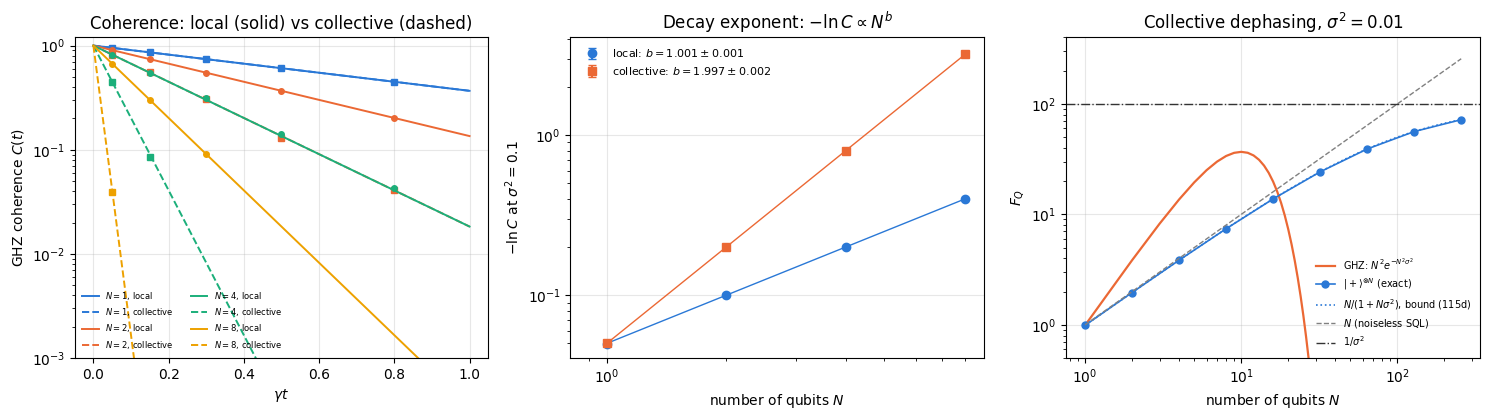

In [18]:
# ==============================================================================
# FIGURE: superdecoherence
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.3))
gt = np.linspace(0, 1.0, 200)                                           # gamma t
gt_mc = np.array([0.05, 0.15, 0.3, 0.5, 0.8])
for k, N in enumerate((1, 2, 4, 8)):
    axes[0].semilogy(gt, np.exp(-N * gt), "-", color=PALETTE[k], lw=1.4, label=f"$N={N}$, local")
    axes[0].semilogy(gt, np.exp(-N ** 2 * gt), "--", color=PALETTE[k], lw=1.4, label=f"$N={N}$, collective")
    for model, mk in (("local", "o"), ("collective", "s")):             # Monte-Carlo points, 20 000 samples each
        cs = []
        for i, t in enumerate(gt_mc):
            kk = jax.random.fold_in(jax.random.PRNGKey(53), 100 * k + 10 * i + (model == "local"))
            s = np.sqrt(2 * t) * (jnp.sum(jax.random.normal(kk, (20_000, N)), axis=1) if model == "local"
                                  else N * jax.random.normal(kk, (20_000,)))
            cs.append(float(jnp.mean(jnp.cos(s))))
        cs = np.array(cs)
        ok = np.exp(-(N if model == "local" else N ** 2) * gt_mc) > 0.04      # show points well above the MC error 0.005
        axes[0].semilogy(gt_mc[ok], cs[ok], mk, color=PALETTE[k], ms=4)
axes[0].set_ylim(1e-3, 1.2); axes[0].set_xlabel(r"$\gamma t$"); axes[0].set_ylabel("GHZ coherence $C(t)$")
axes[0].set_title("Coherence: local (solid) vs collective (dashed)"); axes[0].legend(fontsize=6, ncol=2)

for j, (model, mk) in enumerate((("local", "o"), ("collective", "s"))):
    ys, sys_, b, sb = fit[model]
    axes[1].errorbar(N_SD, ys, yerr=sys_ * ys, fmt=mk, color=PALETTE[j], capsize=3,
                     label=rf"{model}: $b={b:.3f}\pm{sb:.3f}$")
    axes[1].loglog(np.array(N_SD), np.array(N_SD) ** (1 + j) * SIG2_FIT / 2, "-", color=PALETTE[j], lw=1)
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("number of qubits $N$"); axes[1].set_ylabel(r"$-\ln C$ at $\sigma^2=0.1$")
axes[1].set_title(r"Decay exponent: $-\ln C\propto N^b$"); axes[1].legend(fontsize=8)

Nf = np.unique(np.round(np.logspace(0, np.log10(256), 200)))
axes[2].loglog(Nf, Nf ** 2 * np.exp(-Nf ** 2 * SIG2_FQ), "-", color=PALETTE[1], lw=1.6, label=r"GHZ: $N^2e^{-N^2\sigma^2}$")
axes[2].loglog(N_COLL, fq_prod_coll, "o-", color=PALETTE[0], ms=5, lw=1.2, label=r"$\vert+\rangle^{\otimes N}$ (exact)")
axes[2].loglog(Nf, Nf / (1 + Nf * SIG2_FQ), ":", color=PALETTE[0], lw=1.2, label=r"$N/(1+N\sigma^2)$, bound (115d)")
axes[2].loglog(Nf, Nf, "--", color="0.5", lw=1, label=r"$N$ (noiseless SQL)")
axes[2].axhline(1 / SIG2_FQ, color="0.2", ls="-.", lw=1, label=r"$1/\sigma^2$")
axes[2].set_ylim(0.5, 400); axes[2].set_xlabel("number of qubits $N$"); axes[2].set_ylabel(r"$F_Q$")
axes[2].set_title(rf"Collective dephasing, $\sigma^2={SIG2_FQ}$"); axes[2].legend(fontsize=7)
fig.tight_layout(); plt.show()

The sampled GHZ states reproduce Eq. (114) for both noise models within the Monte-Carlo error. The fitted exponents
are $b=1$ for independent phases and $b=2$ for a common phase, within their error bars, and the local value $b=1$ is
excluded for the collective data by the printed number of standard errors. The left panel shows what this means in time:
at the same single-qubit coherence time, the collective GHZ coherence of $8$ qubits has decayed by a factor $e^{-64\gamma t}$,
eight times faster in the exponent than under independent noise. (Some curves coincide by construction: the collective
curve of $N$ qubits equals the local curve of $N^2$ qubits, e.g. collective $N=2$ and local $N=4$.)

The right panel compares the probes under collective noise. The GHZ value follows $N^2e^{-N^2\sigma^2}$ exactly (asserted for
$N\le6$), peaks at $N=1/\sigma=10$ with $F_Q=e^{-1}/\sigma^2\approx37$ and then collapses. The product state is not simply
$Ne^{-\sigma^2}$, which would violate the upper bound (115d) for every $N\ge2$ (wrong control). Its exact quantum Fisher
information lies between the bounds (115d) and (115e) at all three noise strengths tested, and at $\sigma^2=0.01$ it
differs from $N/(1+N\sigma^2)$ by less than $5\times10^{-5}$ relative for every $N$ from $1$ to $256$, the size of the
$O(\sigma^4)$ gap between the bounds. It approaches the ceiling $1/\sigma^2=100$. At $\sigma^2=0.5$ the printed gaps grow
to $10\%$ (upper) and $5\%$ (lower), as expected once $\sigma^2$ is no longer small. Under collective noise both probes are limited by the same
ceiling, and the entangled probe uses less of it.

The four results of this section share one cause. The $N$-body coherence between $\vert\bar0\rangle$ and $\vert\bar1\rangle$ that
gives $F_Q=N^2$ is also what a single lost particle, a single dephased qubit, a single wrong detection, or a common phase
fluctuation destroys, and it is destroyed at a rate that grows with $N$. Realistic metrology trades scaling for
robustness: the probes of notebooks 33 and 34 give up part of the ideal $N^2$ in exchange for a gain that survives noise.

## 11. A zoo of many-body states

This section sorts the standard many-body states by metrological usefulness. We evaluate $F_Q$ for the standard family of $N$-qubit states, each with the
generator that suits it, and compare against $N$ and $N^2$. Beyond the two extremes we already know, four entries deserve a
prediction before we look:

* **W state** $\vert W\rangle=\vert D_N^1\rangle$ (one excitation shared by all qubits). It is an eigenstate of $J_z$
  (eigenvalue $N/2-1$), so $F_Q=0$ for $G=J_z$ — a perfect illustration that the generator matters as much as the state.
  For $G=J_x$ we use the angular-momentum identity $\langle J_x^2\rangle=\tfrac12\left(\langle\mathbf J^2\rangle-\langle J_z^2\rangle\right)$
  valid in the symmetric sector (where $\langle J_x^2\rangle=\langle J_y^2\rangle$), with $j=N/2$, $m=N/2-1$:

  $$F_Q=4\cdot\tfrac12\left[\tfrac N2\left(\tfrac N2+1\right)-\left(\tfrac N2-1\right)^2\right]=3N-2 .$$

* **Dicke state at half filling** $\vert D_N^{N/2}\rangle$ ($m=0$, $N$ even). The same identity gives

  $$F_Q=4\cdot\tfrac12\cdot\tfrac N2\left(\tfrac N2+1\right)=\frac{N(N+2)}{2},$$

  i.e. Heisenberg *scaling* (asymptotically $N^2/2$). Section 15 shows that, unlike GHZ, this state keeps a sizeable
  part of its QFI when a particle is lost.
* **Cluster (graph) state.** A genuinely multipartite entangled stabiliser state, yet all its $\langle\sigma^a_q\rangle$ and most
  two-body correlators vanish — we will see what that does to $F_Q$.
* **Haar-random pure state.** For a random $\vert\psi\rangle$ the standard unitary-averaging identities
  $\mathbb{E}\langle A\rangle=\mathrm{Tr}A/d$ and $\mathbb{E}\langle A\rangle^2=\left[(\mathrm{Tr}A)^2+\mathrm{Tr}A^2\right]/[d(d+1)]$
  with $d=2^N$, $\mathrm{Tr}J_z=0$, $\mathrm{Tr}J_z^2=dN/4$ give the exact average

  $$\mathbb{E}\left[F_Q\right]=4\left(\frac N4-\frac{N}{4(d+1)}\right)=N\,\frac{d}{d+1}\;\xrightarrow[N\to\infty]{}\;N .$$

  A typical state of the Hilbert space is nearly maximally entangled (its half-chain entropy is close to the Page value)
  and yet, on average, worth slightly *less* than a product state.

In [19]:
# ==============================================================================
# STEP 11: the zoo -- QFI of standard many-body states, and the Haar average
# ==============================================================================
N_ZOO = 8
N_HAAR_SAMPLES = 64

# Printed tables use ASCII names; figures use the LaTeX labels of LBL below.
LBL = {"|0>^N": r"$\vert 0\rangle^{\otimes N}$", "|+>^N": r"$\vert +\rangle^{\otimes N}$", "GHZ": "GHZ",
       "W": "W", "Dicke N/2": r"Dicke $N/2$", "cluster": "cluster", "Haar": "Haar random"}
zoo = {
    "|0>^N": (product_state("0" * N_ZOO), (0.0, 1.0, 0.0), "J_y"),
    "|+>^N": (product_state("+" * N_ZOO), (0.0, 1.0, 0.0), "J_y"),
    "GHZ": (ghz_state(N_ZOO), (0.0, 0.0, 1.0), "J_z"),
    "W": (w_state(N_ZOO), (1.0, 0.0, 0.0), "J_x"),
    "Dicke N/2": (dicke_state(N_ZOO, N_ZOO // 2), (1.0, 0.0, 0.0), "J_x"),
    "cluster": (cluster_state(N_ZOO), (0.0, 0.0, 1.0), "J_z"),
}
print(f"N = {N_ZOO}   (SQL: F_Q = {N_ZOO}, Heisenberg: F_Q = {N_ZOO ** 2})\n")
print(f"{'state':>12s} {'G':>5s} | {'F_Q':>10s} {'F_Q/N':>8s} {'F_Q/N^2':>9s} {'entangled?':>11s}")
for name, (psi, n, gname) in zoo.items():
    f = float(qfi_pure_direction(psi, n))
    print(f"{name:>12s} {gname:>5s} | {f:10.4f} {f / N_ZOO:8.3f} {f / N_ZOO ** 2:9.4f} "
          f"{'YES' if f > N_ZOO + 1e-6 else 'not by QFI':>11s}")

# Haar average: vmap over 64 independent random states (one PRNG key each)
keys = jax.random.split(jax.random.PRNGKey(0), N_HAAR_SAMPLES)
f_haar = jax.vmap(lambda k: qfi_pure_direction(haar_state(k, N_ZOO), (0.0, 0.0, 1.0)))(keys)
d, mean_haar, std_haar = 2 ** N_ZOO, float(jnp.mean(f_haar)), float(jnp.std(f_haar))
print(f"{'Haar (mean)':>12s} {'J_z':>5s} | {mean_haar:10.4f} {mean_haar / N_ZOO:8.3f} "
      f"{mean_haar / N_ZOO ** 2:9.4f} {'':>11s}")
sem_haar = std_haar / np.sqrt(N_HAAR_SAMPLES)
print(f"\nHaar average: measured {mean_haar:.4f} +- {sem_haar:.4f} (standard error of the mean "
      f"over {N_HAAR_SAMPLES} states, sample std {std_haar:.3f});  exact N d/(d+1) = {N_ZOO * d / (d + 1):.4f}")
# the measured mean must agree with the exact average within four standard errors
assert abs(mean_haar - N_ZOO * d / (d + 1)) < 4 * sem_haar

# --- CHECKPOINT: the analytic values predicted above ---------------------------------
assert abs(float(qfi_pure_direction(w_state(N_ZOO), (1.0, 0.0, 0.0))) - (3 * N_ZOO - 2)) < 1e3 * TOL
assert abs(float(qfi_pure_direction(dicke_state(N_ZOO, N_ZOO // 2), (1.0, 0.0, 0.0)))
           - N_ZOO * (N_ZOO + 2) / 2) < 1e3 * TOL
print("\nanalytic checks passed:  W -> 3N-2 = %d   Dicke(N/2) -> N(N+2)/2 = %d"
      % (3 * N_ZOO - 2, N_ZOO * (N_ZOO + 2) // 2))

N = 8   (SQL: F_Q = 8, Heisenberg: F_Q = 64)

       state     G |        F_Q    F_Q/N   F_Q/N^2  entangled?
       |0>^N   J_y |     8.0000    1.000    0.1250  not by QFI
       |+>^N   J_y |     8.0000    1.000    0.1250  not by QFI
         GHZ   J_z |    64.0000    8.000    1.0000         YES
           W   J_x |    22.0000    2.750    0.3437         YES
   Dicke N/2   J_x |    40.0000    5.000    0.6250         YES
     cluster   J_z |     8.0000    1.000    0.1250  not by QFI


 Haar (mean)   J_z |     7.9406    0.993    0.1241            

Haar average: measured 7.9406 +- 0.0835 (standard error of the mean over 64 states, sample std 0.668);  exact N d/(d+1) = 7.9689

analytic checks passed:  W -> 3N-2 = 22   Dicke(N/2) -> N(N+2)/2 = 40


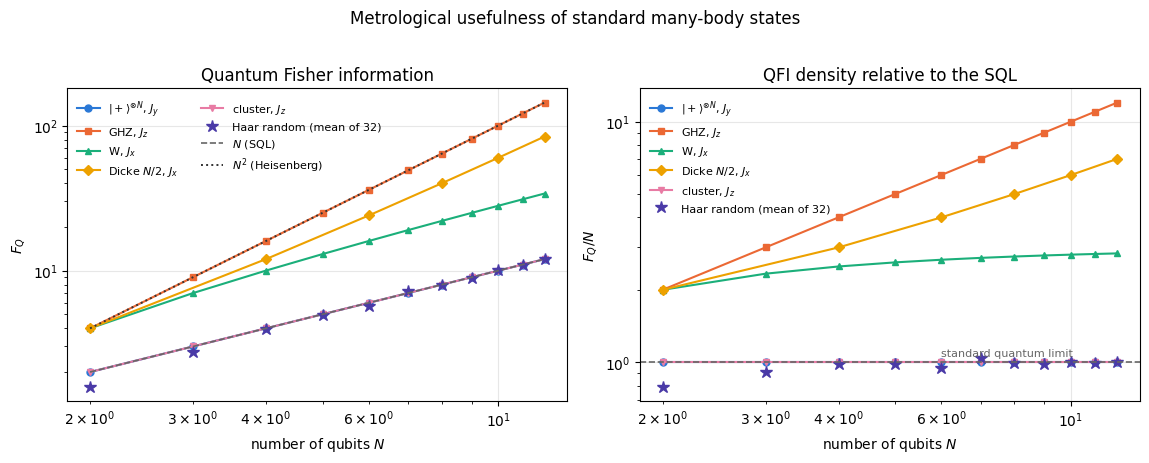

In [20]:
# ==============================================================================
# FIGURE: how the zoo scales with N
# ==============================================================================
N_RANGE = np.arange(2, 13)
curves = {
    r"$\vert+\rangle^{\otimes N}$, $J_y$": lambda N: qfi_pure_direction(product_state("+" * N), (0, 1, 0)),
    r"GHZ, $J_z$": lambda N: qfi_pure_direction(ghz_state(N), (0, 0, 1)),
    r"W, $J_x$": lambda N: qfi_pure_direction(w_state(N), (1, 0, 0)),
    r"Dicke $N/2$, $J_x$": lambda N: qfi_pure_direction(dicke_state(N, N // 2), (1, 0, 0)),
    r"cluster, $J_z$": lambda N: qfi_pure_direction(cluster_state(N), (0, 0, 1)),
}
haar_mean = np.array([float(jnp.mean(jax.vmap(lambda kk: qfi_pure_direction(haar_state(kk, N), (0, 0, 1)))(
    jax.random.split(jax.random.PRNGKey(N), 32)))) for N in N_RANGE])

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.5))
for k, (lab, fn) in enumerate(curves.items()):
    Nl = np.array([N for N in N_RANGE if (N % 2 == 0 or "Dicke" not in lab)])   # Dicke N/2 needs even N
    vals = np.array([float(fn(N)) for N in Nl])
    axes[0].loglog(Nl, vals, MARKERS[k] + "-", color=PALETTE[k], ms=5, label=lab)
    axes[1].semilogx(Nl, vals / Nl, MARKERS[k] + "-", color=PALETTE[k], ms=5, label=lab)
axes[0].loglog(N_RANGE, haar_mean, "*", color=PALETTE[5], ms=9, label="Haar random (mean of 32)")
axes[1].semilogx(N_RANGE, haar_mean / N_RANGE, "*", color=PALETTE[5], ms=9, label="Haar random (mean of 32)")
axes[0].loglog(N_RANGE, N_RANGE, "--", color="0.4", lw=1.2, label=r"$N$ (SQL)")
axes[0].loglog(N_RANGE, N_RANGE ** 2.0, ":", color="0.2", lw=1.4, label=r"$N^2$ (Heisenberg)")
axes[0].set_xlabel("number of qubits $N$"); axes[0].set_ylabel(r"$F_Q$")
axes[0].set_title("Quantum Fisher information"); axes[0].legend(fontsize=8, ncol=2)
axes[1].axhline(1.0, color="0.4", ls="--", lw=1.2)
axes[1].text(6.0, 1.06, "standard quantum limit", fontsize=8, color="0.4")
axes[1].set_yscale("log"); axes[1].set_xlabel("number of qubits $N$"); axes[1].set_ylabel(r"$F_Q/N$")
axes[1].set_title("QFI density relative to the SQL"); axes[1].legend(fontsize=8)
fig.suptitle("Metrological usefulness of standard many-body states", y=1.02)
fig.tight_layout(); plt.show()

The figure, read from the bottom up:

* $\vert+\rangle^{\otimes N}$ with $G=J_y$ sits exactly on the SQL line: the best an unentangled state can do.
* The **cluster state** also sits exactly on $N$, even though it is a genuinely multipartite entangled stabiliser state —
  the standard resource for measurement-based quantum computation. Its collective fluctuations are precisely those of independent
  qubits, because all one-body expectation values and all same-Pauli two-body correlators vanish. **Entanglement is
  necessary but far from sufficient for metrological gain.** (Section 12 finds a tilted direction where the
  cluster state does a little better than $N$; the excess is a boundary term of size $2$ that does not change the scaling.)
* The **Haar-random** points also collapse onto $N$, with a scatter that shrinks as $N$ grows; the measured mean at
  $N=8$, $7.94\pm0.08$ over $64$ states, is consistent with the exact prediction $N d/(d+1)=7.97$. A state drawn at
  random from the Hilbert space is nearly maximally entangled and offers no gain over a product state — the useful
  states form a vanishingly small, highly structured subset.
* The **W state** at $3N-2$ beats the SQL but still scales linearly: $F_Q/N=3-2/N\to3$, a constant-factor gain over the
  SQL that does not grow with $N$, while its share of the Heisenberg value, $(3N-2)/N^2$, vanishes.
* The **Dicke state** at $N(N+2)/2$ and the **GHZ state** at $N^2$ are the two Heisenberg-scaling families, differing by
  a factor of about $2$.

> **Physics insight.** The QFI is a property of the *pair* (state, generator). The same W state is worth $3N-2$ with
> $G=J_x$ and exactly $0$ with $G=J_z$. Section 12 turns this observation into an algorithm for finding the best generator.

### 11.1 Ground states as a metrological resource

Many-body ground states are states a laboratory can reach by preparing the lowest-energy state of a tunable Hamiltonian
(for instance by an adiabatic ramp of a field) rather than by circuit engineering, which makes them attractive resources. Take the transverse-field Ising chain (our Pauli convention, see
[11 — Hamiltonians and ground states](../ch05_ground_states_and_unitary_dynamics/11_hamiltonians_and_ground_states.ipynb)):

$$H(h)=-\sum_{q=0}^{N-2}Z_qZ_{q+1}-h\sum_{q=0}^{N-1}X_q .$$

For $h\ll1$ the ground state is the symmetric superposition of the two ferromagnetic configurations — a macroscopic
Schrödinger-cat state, essentially a GHZ state dressed by quantum fluctuations. For $h\gg1$ it is $\vert+\rangle^{\otimes N}$,
a product state. Somewhere in between (at $h=1$ in the limit $N\to\infty$) sits a quantum critical point. We compute
$F_Q$ for $G=J_z$ along the way with the Lanczos ground-state solver.

In [21]:
# ==============================================================================
# STEP 12: QFI of transverse-field Ising ground states across the transition
# ==============================================================================
H_FIELDS = (0.2, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0)
N_GS = (8, 10)
gs_rows = {}
t0 = time.time()
for N in N_GS:
    row = []
    for h in H_FIELDS:
        terms = heisenberg_terms(N, Jxx=0.0, Jyy=0.0, Jzz=-1.0, hx=-h)     # -ZZ bonds, -h X fields
        E, psi = lanczos_ground_state(terms, N, m=80, key=jax.random.PRNGKey(7), restarts=3)
        row.append((h, float(E), float(qfi_pure_direction(psi, (0, 0, 1))),
                    float(qfi_pure_direction(psi, (0, 1, 0)))))
    gs_rows[N] = row
print(f"(ground states computed in {time.time() - t0:.1f} s)\n")
for N in N_GS:
    print(f"N = {N}:")
    print(f"  {'h':>5s} {'E_0':>10s} | {'F_Q(J_z)':>10s} {'F_Q/N':>8s} {'F_Q/N^2':>9s} | {'F_Q(J_y)':>10s} {'F_Q/N':>8s}")
    for h, E, fz, fy in gs_rows[N]:
        print(f"  {h:5.2f} {E:10.4f} | {fz:10.4f} {fz / N:8.3f} {fz / N ** 2:9.4f} | {fy:10.4f} {fy / N:8.3f}")
    print()

(ground states computed in 6.8 s)

N = 8:
      h        E_0 |   F_Q(J_z)    F_Q/N   F_Q/N^2 |   F_Q(J_y)    F_Q/N
   0.20    -7.1003 |    63.0021    7.875    0.9844 |     7.8657    0.983
   0.50    -7.6406 |    56.8315    7.104    0.8880 |     6.7649    0.846
   0.80    -8.7492 |    39.9000    4.987    0.6234 |     3.5843    0.448
   1.00    -9.8380 |    28.1850    3.523    0.4404 |     2.5512    0.319
   1.20   -11.1082 |    21.4995    2.687    0.3359 |     2.6756    0.334
   1.50   -13.1914 |    16.6638    2.083    0.2604 |     3.3665    0.421
   2.00   -16.8851 |    13.3404    1.668    0.2084 |     4.3907    0.549
   3.00   -24.5863 |    11.0147    1.377    0.1721 |     5.5724    0.697

N = 10:
      h        E_0 |   F_Q(J_z)    F_Q/N   F_Q/N^2 |   F_Q(J_y)    F_Q/N
   0.20    -9.1204 |    98.5335    9.853    0.9853 |     9.8471    0.985
   0.50    -9.7655 |    89.6893    8.969    0.8969 |     8.8233    0.882
   0.80   -11.0675 |    63.3331    6.333    0.6333 |     5.0788    0.508


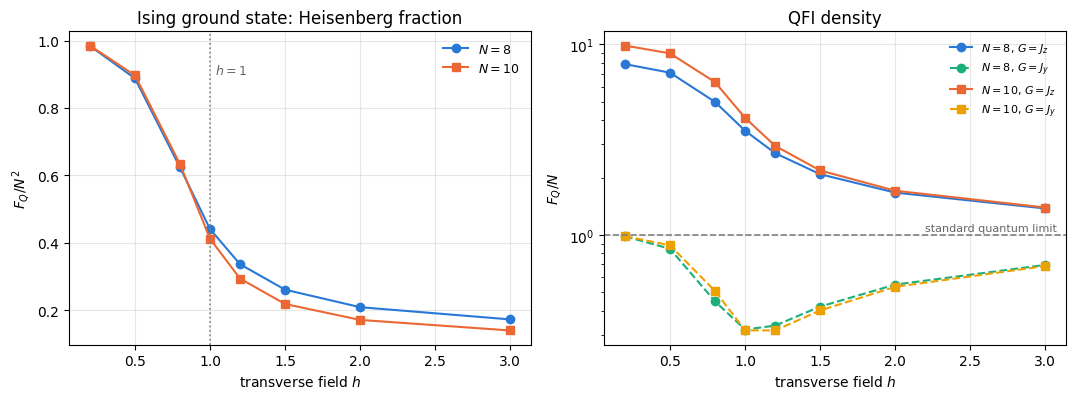

In [22]:
# ==============================================================================
# FIGURE: QFI density of the Ising ground state across the quantum phase transition
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.1))
for k, N in enumerate(N_GS):
    hs = [r[0] for r in gs_rows[N]]
    axes[0].plot(hs, [r[2] / N ** 2 for r in gs_rows[N]], MARKERS[k] + "-", color=PALETTE[k], label=f"$N={N}$")
    axes[1].plot(hs, [r[2] / N for r in gs_rows[N]], MARKERS[k] + "-", color=PALETTE[k], label=f"$N={N}$, $G=J_z$")
    axes[1].plot(hs, [r[3] / N for r in gs_rows[N]], MARKERS[k] + "--", color=PALETTE[k + 2], label=f"$N={N}$, $G=J_y$")
axes[0].axvline(1.0, color="0.5", ls=":", lw=1.2)
axes[0].text(1.03, 0.9, "$h=1$", fontsize=9, color="0.4")
axes[0].set_xlabel("transverse field $h$"); axes[0].set_ylabel(r"$F_Q/N^2$")
axes[0].set_title("Ising ground state: Heisenberg fraction"); axes[0].legend(fontsize=9)
axes[1].axhline(1.0, color="0.5", ls="--", lw=1.2)
axes[1].text(2.2, 1.05, "standard quantum limit", fontsize=8, color="0.4")
axes[1].set_xlabel("transverse field $h$"); axes[1].set_ylabel(r"$F_Q/N$")
axes[1].set_yscale("log"); axes[1].set_title("QFI density"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

Deep in the ferromagnetic phase ($h=0.2$) the ground state reaches $F_Q/N^2\approx0.98$: the finite chain really is a
near-perfect GHZ state, and preparing the ground state of an Ising magnet is an alternative way to make one. As $h$ grows the cat is destroyed —
the ratio $F_Q/N^2$ falls monotonically through the transition region and, by $h=3$, $F_Q$ has dropped to about $1.4N$
($1.38N$ at $N=8$, $1.39N$ at $N=10$). $F_Q/N$ for $G=J_z$ stays above $1$ everywhere we look: the Ising ground state is entangled at every
finite field, and the QFI witnesses it.

The perpendicular generator $J_y$ tells a different and initially surprising story: its QFI density is *not* monotonic.
It starts at $F_Q(J_y)/N\approx0.98$ at $h=0.2$, falls to a minimum of $\approx0.32$ at $h=1$, and climbs back to
$\approx0.7$ at $h=3$. Both ends are easy: at $h\to0$ the state is the cat $(\vert0\cdots0\rangle+\vert1\cdots1\rangle)/\sqrt2$,
for which $\mathrm{Var}(J_y)=N/4$ exactly, the same as for a product state; at $h\to\infty$ the state is
$\vert+\rangle^{\otimes N}$, for which $\mathrm{Var}(J_y)=N/4$ as well. In between, the transverse fluctuations are
reduced by the interaction. Since $\langle Y_q\rangle=0$ by symmetry, Eq. (75) reads
$F_Q(J_y)=N+\sum_{q\neq q'}\langle Y_qY_{q'}\rangle$, so a density below $1$ means a net *negative* $y$-$y$ correlation;
it is largest in magnitude in the critical region near $h=1$, where the correlation length is longest. Reading the two generators together: the transition transfers
metrological weight from $J_y$ into $J_z$ as $h$ decreases, and the critical region is where the transfer happens.

> **Numerical practice.** In the ordered phase the finite chain has two almost degenerate lowest states of opposite
> $\prod_q X_q$ parity — the symmetric and the antisymmetric cat — split by about $5\times10^{-6}$ at $N=8$, $h=0.2$.
> Which of the two a solver returns does not matter here: both are parity eigenstates and both give the same
> $F_Q\approx0.98N^2$. What *would* matter is landing on a symmetry-broken superposition
> $\alpha\vert\!\uparrow\cdots\uparrow\rangle+\beta\vert\!\downarrow\cdots\downarrow\rangle$: then
> $F_Q\approx N^2\left(1-(\vert\alpha\vert^2-\vert\beta\vert^2)^2\right)$, anywhere between $N^2$ and $0$, and for the
> fully polarised choice it collapses to a number of order $1$. Lanczos with a fixed seed and several restarts stayed on
> a parity eigenstate here — the printed energies and the QFI are smooth in $h$ — but with a poorer solver one can easily
> land anywhere in that family. Always check that a computed quantity is smooth in the parameter before interpreting it.

## 12. The $3\times3$ QFI matrix and the optimal generator direction

So far we chose the generator direction $\mathbf n$ by hand. We can do better: for collective generators the dependence on
$\mathbf n$ is *quadratic*, so the optimisation over the whole sphere reduces to a $3\times3$ eigenvalue problem.

### 12.1 Derivation

Let $G=\mathbf n\cdot\mathbf J=\sum_a n_aJ_a$ with $\mathbf n$ a real unit vector. Then

$$\mathrm{Var}(G)=\langle G^2\rangle-\langle G\rangle^2
=\sum_{a,b}n_an_b\left[\tfrac12\langle J_aJ_b+J_bJ_a\rangle-\langle J_a\rangle\langle J_b\rangle\right],$$

where the symmetrisation is free: $n_an_b$ is symmetric under $a\leftrightarrow b$, so only the symmetric part of
$\langle J_aJ_b\rangle$ survives the double sum. Defining the real symmetric **covariance matrix**

$$C_{ab}=\tfrac12\langle J_aJ_b+J_bJ_a\rangle-\langle J_a\rangle\langle J_b\rangle \tag{117}$$

and the **QFI matrix**

$$\mathcal{F}_{ab}=4\,C_{ab}, \tag{118}$$

we get the compact statement

$$F_Q(\mathbf n)=\mathbf n^{\mathsf T}\,\mathcal{F}\,\mathbf n . \tag{119}$$

Maximising a quadratic form over unit vectors is the Rayleigh-quotient problem: since $\mathcal F$ is real symmetric it has
an orthonormal eigenbasis $\mathcal F\mathbf v_k=\lambda_k\mathbf v_k$ with $\lambda_1\le\lambda_2\le\lambda_3$; expanding
$\mathbf n=\sum_k c_k\mathbf v_k$ with $\sum_kc_k^2=1$ gives $\mathbf n^{\mathsf T}\mathcal F\mathbf n=\sum_k\lambda_kc_k^2\le\lambda_3$,
with equality for $\mathbf n=\mathbf v_3$. Hence

$$\max_{\mathbf n}F_Q(\mathbf n)=\lambda_{\max}(\mathcal F),\qquad
  \mathbf n_{\text{opt}}=\text{eigenvector of }\mathcal F\text{ for }\lambda_{\max} . \tag{120}$$

Three matrix elements per pair of axes, one $3\times3$ `eigh`, and the optimisation over the sphere is done exactly.

The identification $\mathcal F=4C$ of Eq. (118) uses $F_Q=4\,\mathrm{Var}(G)$ and is therefore valid **only for pure
states**. The eigenvalue argument itself survives for mixed states, because the mixed-state formula, Eq. (49) of Section 5.3, is
also quadratic in the generator: $F_Q(\mathbf n)=\mathbf n^{\mathsf T}\Gamma\mathbf n$ with

$$\Gamma_{ab}=2\sum_{m,n\,:\,\lambda_m+\lambda_n>0}\frac{(\lambda_m-\lambda_n)^2}{\lambda_m+\lambda_n}\,
  \mathrm{Re}\!\left[\langle m\vert J_a\vert n\rangle\langle n\vert J_b\vert m\rangle\right].$$

For a mixed state $\Gamma$ is in general *smaller* than $4C$, so feeding a covariance matrix into Eq. (120) returns an
upper bound on the optimal QFI rather than the optimal QFI. Notebook 30 makes that gap explicit. Everything in this
section is applied to pure states only, where the two coincide.

### 12.2 Code

The engine's `spin_moments` returns exactly $\langle\mathbf J\rangle$ and the symmetrised covariance $C$ of Eq. (117),
computed matrix-free: it forms $\vert\phi_a\rangle=J_a\vert\psi\rangle$ for $a=x,y,z$ (three calls of `apply_collective`) and
reads off $\tfrac12\langle J_aJ_b+J_bJ_a\rangle=\mathrm{Re}\,\langle\phi_a\vert\phi_b\rangle$ — the real part of an inner
product *is* the symmetrised moment, because $\langle\phi_a\vert\phi_b\rangle=\langle J_aJ_b\rangle$ and
$\langle J_bJ_a\rangle=\overline{\langle J_aJ_b\rangle}$.

In [23]:
# ==============================================================================
# STEP 13: the 3x3 QFI matrix and the optimal generator direction
# ==============================================================================
def qfi_matrix(psi):
    """3x3 QFI matrix of a pure state over the collective generators (J_x, J_y, J_z).

    MATH   Fcal[a,b] = 4 * ( (1/2)<J_a J_b + J_b J_a> - <J_a><J_b> ),   F_Q(n) = n^T Fcal n   (Eq. 119)
    COST   three matrix-free applications of J_a: O(N 2^N).
    """
    _, cov = spin_moments(psi)
    return 4.0 * cov


def optimal_direction(psi):
    """Best generator direction and the QFI it delivers: (F_max, n_opt) from Eq. (120)."""
    F = qfi_matrix(psi)
    w, v = jnp.linalg.eigh(F)                 # eigenvalues ascending
    return w[-1], v[:, -1]


# --- CHECKPOINT: the quadratic form, Eq. (119), reproduces the direct matrix-free QFI ------------
N_DIR = 6
states_dir = {"GHZ": ghz_state(N_DIR), "W": w_state(N_DIR), "Dicke N/2": dicke_state(N_DIR, N_DIR // 2),
              "|+>^N": product_state("+" * N_DIR), "cluster": cluster_state(N_DIR),
              "Haar": haar_state(jax.random.PRNGKey(3), N_DIR)}
key_dirs = jax.random.normal(jax.random.PRNGKey(11), (12, 3))
key_dirs = key_dirs / jnp.linalg.norm(key_dirs, axis=1, keepdims=True)     # 12 random unit directions
err_quad = 0.0
for name, psi in states_dir.items():
    F = qfi_matrix(psi)
    for n in key_dirs:
        err_quad = max(err_quad, abs(float(n @ F @ n) - float(qfi_pure_direction(psi, n))))
print(f"max |n^T Fcal n  -  4 Var(n.J)| over 6 states x 12 random directions = {err_quad:.2e}")
assert err_quad < 1e4 * TOL

print(f"\nN = {N_DIR}   (SQL: {N_DIR},  Heisenberg: {N_DIR ** 2})\n")
print(f"{'state':>12s} | {'eigenvalues of Fcal':>32s} | {'F_max':>9s} {'n_opt':>24s} {'F(J_z)':>9s}")
for name, psi in states_dir.items():
    F = qfi_matrix(psi)
    w = np.array(jnp.linalg.eigvalsh(F))
    fmax, nopt = optimal_direction(psi)
    nopt = np.array(nopt) * np.sign(np.array(nopt)[np.argmax(np.abs(np.array(nopt)))])   # fix the global sign
    print(f"{name:>12s} | {np.array2string(w, precision=3, floatmode='fixed'):>32s} | {float(fmax):9.4f} "
          f"{np.array2string(nopt, precision=3, floatmode='fixed'):>24s} {float(qfi_pure_direction(psi, (0, 0, 1))):9.4f}")

max |n^T Fcal n  -  4 Var(n.J)| over 6 states x 12 random directions = 2.58e-14

N = 6   (SQL: 6,  Heisenberg: 36)

       state |              eigenvalues of Fcal |     F_max                    n_opt    F(J_z)
         GHZ |           [ 6.000  6.000 36.000] |   36.0000      [0.000 0.000 1.000]   36.0000
           W | [-3.553e-15  1.600e+01  1.600e+01] |   16.0000      [1.000 0.000 0.000]   -0.0000


   Dicke N/2 |  [6.163e-33 2.400e+01 2.400e+01] |   24.0000      [1.000 0.000 0.000]    0.0000
       |+>^N |  [1.421e-14 6.000e+00 6.000e+00] |    6.0000   [-0.000  1.000 -0.000]    6.0000
     cluster |              [4.000 6.000 8.000] |    8.0000   [ 0.707 -0.000  0.707]    6.0000
        Haar |              [4.078 6.291 7.073] |    7.0734   [ 0.714 -0.652  0.253]    4.9909


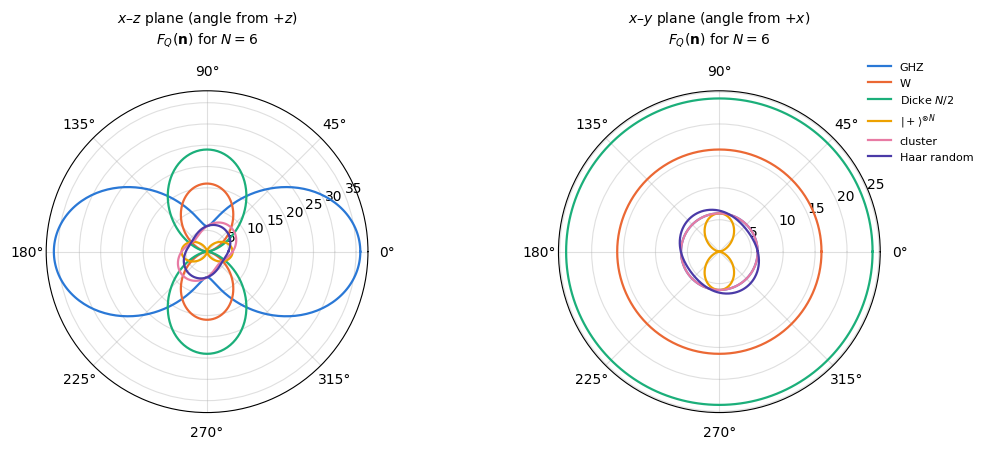

In [24]:
# ==============================================================================
# FIGURE: F_Q as a function of the generator direction, in two great circles
# ==============================================================================
angles = np.linspace(0, 2 * np.pi, 361)
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6), subplot_kw={"projection": "polar"})
for k, (name, psi) in enumerate(list(states_dir.items())):
    F = np.array(qfi_matrix(psi))
    xz = np.array([[np.sin(a), 0.0, np.cos(a)] for a in angles])          # great circle in the x-z plane
    xy = np.array([[np.cos(a), np.sin(a), 0.0] for a in angles])          # great circle in the x-y plane
    axes[0].plot(angles, np.einsum("ia,ab,ib->i", xz, F, xz), color=PALETTE[k % 6], lw=1.6, label=LBL[name])
    axes[1].plot(angles, np.einsum("ia,ab,ib->i", xy, F, xy), color=PALETTE[k % 6], lw=1.6, label=LBL[name])
for ax, ttl in zip(axes, [r"$x$–$z$ plane (angle from $+z$)", r"$x$–$y$ plane (angle from $+x$)"]):
    ax.set_title(ttl + f"\n$F_Q(\\mathbf{{n}})$ for $N={N_DIR}$", fontsize=10, pad=16)
    ax.grid(alpha=0.4)
axes[1].legend(fontsize=8, loc="upper right", bbox_to_anchor=(1.32, 1.12))
fig.tight_layout(); plt.show()

The polar plots are the quadratic form of Eq. (119) drawn as a radius: an ellipse-like curve (strictly, the restriction of a
quadric to a great circle) whose longest axis is the optimal direction.

* **GHZ** is a two-lobed figure along $\hat z$ with $F_Q=N^2=36$ there and only $F_Q=N=6$ in the perpendicular plane.
  Point the generator the wrong way and a Heisenberg-limited state degrades to the standard quantum limit.
* **W** and **Dicke** are the opposite: flat and *isotropic* in the $x$–$y$ plane (they are $J_z$ eigenstates, so the
  $z$ direction carries nothing) — any equatorial direction is optimal.
* $\vert+\rangle^{\otimes N}$ is a circle of radius $N$ in the $y$–$z$ plane and vanishes along $\hat x$, its own polarisation axis.
* The **cluster state** is the interesting one. Its three eigenvalues at $N=6$ come out as $(4,6,8)$: unlike the naive
  $F_Q=N$ along every Cartesian axis, the optimal direction is the diagonal $(\mathbf{\hat x}+\mathbf{\hat z})/\sqrt2$ and
  gives $F_Q=8>N=6$. The off-diagonal entry comes from the two *boundary* stabilisers of the open chain, $K_0=X_0Z_1$ and
  $K_{N-1}=Z_{N-2}X_{N-1}$. Since every $\langle J_a\rangle$ vanishes and $\sigma^x_q$ anticommutes with $\sigma^z_q$ on the
  same site, only $q\neq q'$ survives in Eq. (117) and $\mathcal{F}_{xz}=\sum_{q\neq q'}\langle X_qZ_{q'}\rangle
  =\langle X_0Z_1\rangle+\langle X_{N-1}Z_{N-2}\rangle=1+1=2$, while the diagonal stays at $N$; the eigenvalues are then
  $N-2,\,N,\,N+2$, exactly the $(4,6,8)$ printed above. So the cluster state *is* detected as entangled — but only if you
  look along the right axis, and the excess is a boundary effect of size $2$ (we measure $F_{\max}=N+2$ at both $N=6$
  and $N=8$) that leaves the scaling linear.
* The **Haar-random** state is a generic anisotropic blob; its three eigenvalues $(4.08,6.29,7.07)$ scatter around
  $N=6$, and its optimal direction is a random-looking unit vector.

Where $\lambda_{\max}$ is degenerate (W, Dicke, $\vert+\rangle^{\otimes N}$) the printed $\mathbf n_{\text{opt}}$ is one
arbitrary vector of the degenerate plane returned by `eigh`; every unit vector in that plane is equally optimal.

> **Numerical practice.** Replacing an optimisation over a continuum (here: the unit sphere of directions) by an exact
> eigenvalue problem is always worth hunting for. It costs one `eigh` of a $3\times3$ matrix instead of a gradient descent
> that can stall in local maxima, and it returns the *global* optimum with a certificate. Notebook 34 uses exactly this
> $3\times3$ matrix to track the optimal measurement axis along a one-axis-twisting evolution.

## 13. The QFI as an entanglement witness

Section 7 proved $F_Q\le N$ for separable states. Turned around, this is one of the most useful entanglement criteria in
experimental many-body physics, because it is *operational*: a violation certifies entanglement that is strong enough to beat the
shot-noise limit in an interferometer.

**Criterion 1 (Pezzè and Smerzi 2009).** For every separable state of $N$ qubits and every collective generator
$G=\mathbf n\cdot\mathbf J$,

$$F_Q[\rho,G]\le N;\qquad\text{therefore}\quad F_Q>N\;\Longrightarrow\;\rho\text{ is entangled.} \tag{121}$$

**Criterion 2 (Hyllus et al. 2012; Tóth 2012).** Call a state **$k$-producible** if it is a mixture of products of blocks of
at most $k$ qubits (so $k=1$ means separable). Writing $N=sk+r$ with $s=\lfloor N/k\rfloor$ and $0\le r<k$, every
$k$-producible state obeys

$$F_Q[\rho,G]\;\le\;s\,k^2+r^2\;\le\;kN . \tag{122}$$

(The second inequality holds because $kN=sk^2+kr$ and $r<k$.) Consequently $F_Q>s\,k^2+r^2$ certifies **entanglement
depth** at least $k+1$: some block of at least $k+1$ qubits is genuinely entangled. We always use the *sharp* middle
expression, never the weaker $kN$ — for $N=8$, $k=3$ the two differ by $2$, and that difference decides the verdict for
the W state below. Both criteria are quoted here; their proofs use the convexity of the QFI plus the single-block bound
$F_Q\le k^2$, which is the Heisenberg-limit argument of Section 7.4 applied to a block of $k$ qubits.

Let us apply the criteria to the zoo.

In [25]:
# ==============================================================================
# STEP 14: entanglement depth certified by the QFI, Eq. (122)
# ==============================================================================
def entanglement_depth(F_value, N):
    """Largest k+1 such that F_Q > s k^2 + r^2 with s = N//k, r = N%k  --  the certified entanglement depth.

    Returns 1 if the QFI certifies nothing (F_Q <= N), otherwise the smallest block size that must be
    genuinely entangled.  MATH: Eq. (122), k-producible states obey F_Q <= s k^2 + r^2.
    """
    depth = 1
    for k in range(1, N + 1):
        s, r = divmod(N, k)
        if F_value > s * k ** 2 + r ** 2 + 1e-9:     # k-producible is EXCLUDED
            depth = k + 1
    return depth


N_W = 8
print(f"N = {N_W}:  bound of Eq. (122) for k-producible states")
print("   " + "  ".join(f"k={k}: {N_W // k * k ** 2 + (N_W % k) ** 2:3d}" for k in range(1, N_W + 1)))
print(f"\n{'state':>20s} {'G':>7s} | {'F_Q':>9s} {'F_Q/N':>7s} | {'entangled':>10s} {'depth >=':>9s} {'S(N/2 cut)':>11s}")
wit_states = [
    ("|+>^N", product_state("+" * N_W), (0, 1, 0), "J_y"),
    ("W", w_state(N_W), (1, 0, 0), "J_x"),
    ("cluster (opt.dir.)", cluster_state(N_W), None, "n_opt"),
    ("Dicke N/2", dicke_state(N_W, N_W // 2), (1, 0, 0), "J_x"),
    ("GHZ", ghz_state(N_W), (0, 0, 1), "J_z"),
    ("Haar random", haar_state(jax.random.PRNGKey(5), N_W), None, "n_opt"),
]
for name, psi, n, gname in wit_states:
    f = float(optimal_direction(psi)[0]) if n is None else float(qfi_pure_direction(psi, n))
    S = float(entanglement_entropy(psi, range(N_W // 2)))
    print(f"{name:>20s} {gname:>7s} | {f:9.4f} {f / N_W:7.3f} | {'YES' if f > N_W else 'no':>10s} "
          f"{entanglement_depth(f, N_W):9d} {S:11.3f}")

N = 8:  bound of Eq. (122) for k-producible states
   k=1:   8  k=2:  16  k=3:  22  k=4:  32  k=5:  34  k=6:  40  k=7:  50  k=8:  64

               state       G |       F_Q   F_Q/N |  entangled  depth >=  S(N/2 cut)


               |+>^N     J_y |    8.0000   1.000 |         no         1       0.000
                   W     J_x |   22.0000   2.750 |        YES         3       1.000
  cluster (opt.dir.)   n_opt |   10.0000   1.250 |        YES         2       1.000
           Dicke N/2     J_x |   40.0000   5.000 |        YES         6       1.642
                 GHZ     J_z |   64.0000   8.000 |        YES         8       1.000
         Haar random   n_opt |    8.2048   1.026 |        YES         2       3.212


The table puts the two halves of the story side by side. The last column is the entanglement entropy across the middle cut —
the standard *quantitative* entanglement measure for pure states — and it is uncorrelated with metrological
usefulness. The Haar-random state has by far the largest entropy ($3.21$ bits out of a maximum of $4$, close to the Page
value) and yet, even in its optimal direction, it reaches only $F_Q=8.20$ against the separable bound $N=8$: the QFI
certifies only that the state is entangled (depth $2$). The cluster state stops at depth $2$ as well, although it is
a genuinely $8$-partite entangled stabiliser state. The GHZ state has just **one** bit of entropy across the cut — the
same as the cluster state — and is certified as genuinely $8$-partite entangled; the Dicke state, with $1.64$ bits,
reaches depth $6$.

The W state is worth a second look because it lands exactly on a bound: $F_Q=22$ and the $k=3$ bound of Eq. (122) is
$s k^2+r^2=2\cdot 9+2^2=22$. The inequality in Eq. (122) is not strict, so a value *equal* to the bound excludes nothing:
$3$-producibility survives and the certified depth is $3$, not $4$. (That $\vert W_8\rangle$ is in fact genuinely
$8$-partite entangled is true but invisible to this witness — a reminder that Eq. (122) is a one-sided criterion, and that
the exact-equality case has to be decided by the inequality as written; a bare floating-point comparison could go either way. The
`+1e-9` in `entanglement_depth` is what implements "not strictly greater".)

> **Physics insight.** "How much entanglement" and "how useful the entanglement is" are different questions with different
> answers. Metrology rewards *collective, coherent* superpositions of configurations with very different values of the
> generator; the amount of entanglement across a cut is a different quantity. This is why the phrase "useful entanglement" appears so often in the
> metrology literature, and why $F_Q$ rather than an entropy is the figure of merit.

## 14. Noise: QFI of mixed states for three channels

Real devices produce mixed states, and Eq. (75) no longer applies, because a mixed state has no single
$\vert\psi\rangle$ whose variance we could take. The general answer for a unitary encoding is Eq. (49), derived in
Section 5.3 from the symmetric logarithmic derivative and implemented by the engine's `qfi_mixed`. Notebook
[30 — QFI from the SLD](../ch10_quantum_metrology_protocols/30_qfi_from_the_sld_prepare_encode_estimate.ipynb) adds the
treatment of the kernel of $\rho$, the explicit optimal measurement for mixed states, and the reduction of Eq. (49) to
$4\,\mathrm{Var}(G)$ for pure states. Two features of Eq. (49) matter here: it costs a full eigendecomposition,
$O(8^N)$, so it is a small-system tool ($N\le7$ in practice); and every term is non-negative, so mixing can only be
understood by looking at how *both* the eigenvalues and the matrix elements change.

One inequality is worth recording now, because it will be used repeatedly later in the chapter. Since
$(\lambda_m-\lambda_n)^2\le(\lambda_m+\lambda_n)^2$ for non-negative eigenvalues, Eq. (49) is bounded by
$2\sum_{m,n}(\lambda_m+\lambda_n)\left\vert\langle m\vert G\vert n\rangle\right\vert^2=4\langle G^2\rangle$. Eq. (49) is
unchanged by the shift $G\to G-\langle G\rangle\mathbb 1$ (the diagonal terms $m=n$ carry the factor
$(\lambda_m-\lambda_m)^2=0$, and the off-diagonal matrix elements do not see the shift), so the same bound applied to
the shifted generator gives

$$F_Q[\rho,G]\;\le\;4\,\mathrm{Var}_\rho(G) . \tag{123}$$

Equality holds for every pure state (Section 6). For mixed states the inequality is in general strict, although not
always: $\rho=\tfrac12(\vert00\rangle\langle00\vert+\vert11\rangle\langle11\vert)$ with $G=\tfrac12X_1$ has
$F_Q=4\mathrm{Var}(G)=1$, because the two components rotate in orthogonal subspaces and stay perfectly distinguishable.
So $4\,\mathrm{Var}(G)$ never *under*-estimates the quantum Fisher information: it is the right answer for pure states
and an upper bound for mixed ones. Notebook 30 shows the gap numerically (a proof of the inequality is in Tóth and
Apellaniz 2014), and notebook 36 measures how large it becomes for noisy states. Since the spectrum of $J_z$ has width
$N$, Eqs. (123) and (101) extend the Heisenberg bound $F_Q\le N^2$ to mixed states.

Section 10.2 derived the quantum Fisher information of the dephased GHZ state exactly, Eq. (111), and checked it in
STEP 9. Here we compare the three standard single-qubit channels — depolarising, dephasing and amplitude damping —
applied to every qubit of a GHZ state before the encoding, for $N=2,\dots,6$ and a range of error probabilities.

In [26]:
# ==============================================================================
# STEP 15: three channels, GHZ, N = 2 ... 6
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
P_GRID = np.array([0.0, 0.005, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30])   # error probability per qubit
# -----------------------------------------------------------------------------
CHANNELS = {"depolarising": kraus_depolarizing, "dephasing": kraus_dephasing,
            "amplitude damping": kraus_amplitude_damping}
noise_data = {}
t0 = time.time()
for cname, kfn in CHANNELS.items():
    for N in (2, 3, 4, 5, 6):
        vals = []
        for p in P_GRID:
            rho = apply_local_channel(to_dm(ghz_state(N)), kfn, float(p))
            vals.append(float(qfi_noisy(rho, (0, 0, 1), N)))
        noise_data[(cname, N)] = np.array(vals)
print(f"(noise sweep computed in {time.time() - t0:.1f} s)\n")

print(f"GHZ_N, generator J_z, QFI normalised by the ideal value N^2\n")
for cname in CHANNELS:
    print(f"  {cname}:")
    print("    " + f"{'N':>3s} | " + " ".join(f"p={p:<5.3f}" for p in P_GRID))
    for N in (2, 4, 6):
        v = noise_data[(cname, N)] / N ** 2
        print("    " + f"{N:3d} | " + " ".join(f"{x:7.4f}" for x in v))
    print()

(noise sweep computed in 2.4 s)

GHZ_N, generator J_z, QFI normalised by the ideal value N^2

  depolarising:
      N | p=0.000 p=0.005 p=0.010 p=0.020 p=0.050 p=0.100 p=0.150 p=0.200 p=0.300
      2 |  1.0000  0.9801  0.9604  0.9218  0.8111  0.6444  0.4995  0.3761  0.1906
      4 |  1.0000  0.9606  0.9225  0.8500  0.6595  0.4194  0.2557  0.1482  0.0408
      6 |  1.0000  0.9415  0.8861  0.7836  0.5355  0.2716  0.1293  0.0571  0.0083

  dephasing:
      N | p=0.000 p=0.005 p=0.010 p=0.020 p=0.050 p=0.100 p=0.150 p=0.200 p=0.300
      2 |  1.0000  0.9606  0.9224  0.8493  0.6561  0.4096  0.2401  0.1296  0.0256
      4 |  1.0000  0.9227  0.8508  0.7214  0.4305  0.1678  0.0576  0.0168  0.0007
      6 |  1.0000  0.8864  0.7847  0.6127  0.2824  0.0687  0.0138  0.0022  0.0000

  amplitude damping:
      N | p=0.000 p=0.005 p=0.010 p=0.020 p=0.050 p=0.100 p=0.150 p=0.200 p=0.300
      2 |  1.0000  0.9950  0.9899  0.9796  0.9475  0.8901  0.8281  0.7619  0.6203
      4 |  1.0000  0.9900  0.9799 

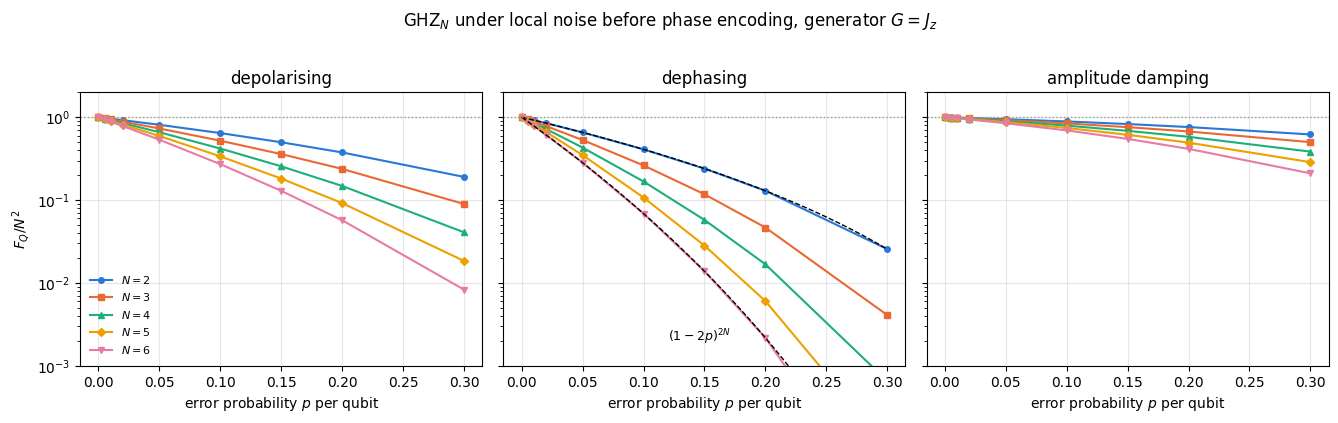

In [27]:
# ==============================================================================
# FIGURE: fragility of the Heisenberg limit
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.1), sharey=True)
for j, cname in enumerate(CHANNELS):
    for k, N in enumerate((2, 3, 4, 5, 6)):
        axes[j].semilogy(P_GRID, noise_data[(cname, N)] / N ** 2, MARKERS[k] + "-",
                         color=PALETTE[k], ms=4, label=f"$N={N}$")
    if cname == "dephasing":
        pp = np.linspace(0, 0.3, 200)
        for k, N in enumerate((2, 6)):
            axes[j].semilogy(pp, (1 - 2 * pp) ** (2 * N), "k--", lw=1)
        axes[j].text(0.12, 2e-3, r"$(1-2p)^{2N}$", fontsize=9)
    axes[j].axhline(1.0, color="0.6", ls=":", lw=1)
    axes[j].set_xlabel("error probability $p$ per qubit"); axes[j].set_title(cname)
axes[0].set_ylabel(r"$F_Q/N^2$"); axes[0].set_ylim(1e-3, 2.0); axes[0].legend(fontsize=8)
fig.suptitle(r"GHZ$_N$ under local noise before phase encoding, generator $G=J_z$", y=1.02)
fig.tight_layout(); plt.show()

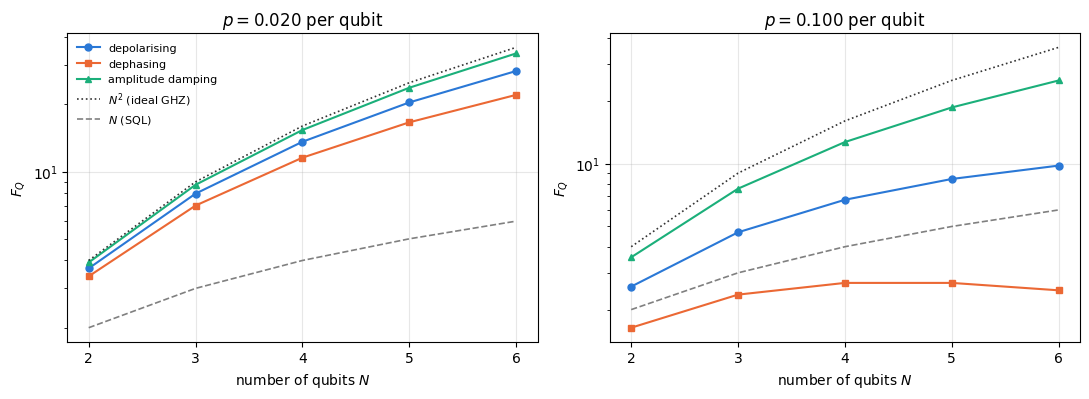

In [28]:
# ==============================================================================
# FIGURE: decay of the advantage with N at fixed p
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.1))
Nn = np.array([2, 3, 4, 5, 6])
for j, p_show in enumerate((0.02, 0.10)):
    ip = int(np.argmin(np.abs(P_GRID - p_show)))
    for k, cname in enumerate(CHANNELS):
        axes[j].semilogy(Nn, [noise_data[(cname, N)][ip] for N in Nn], MARKERS[k] + "-",
                         color=PALETTE[k], ms=5, label=cname)
    axes[j].semilogy(Nn, Nn ** 2.0, ":", color="0.2", lw=1.2, label=r"$N^2$ (ideal GHZ)")
    axes[j].semilogy(Nn, Nn * 1.0, "--", color="0.5", lw=1.2, label=r"$N$ (SQL)")
    axes[j].set_xlabel("number of qubits $N$"); axes[j].set_ylabel(r"$F_Q$")
    axes[j].set_title(f"$p = {P_GRID[ip]:.3f}$ per qubit"); axes[j].set_xticks(Nn)
axes[0].legend(fontsize=8)
fig.tight_layout(); plt.show()

In [29]:
# ==============================================================================
# STEP 15b: comparing two channels at the SAME physical strength, not the same label p
# ==============================================================================
# A single qubit under dephasing(p) keeps a fraction (1 - 2p) of its transverse Bloch components;
# under depolarising(p) it keeps (1 - 4p/3).  Matching those two contractions to a common value eta
# removes the parametrisation convention from the comparison and leaves only physics.
print("GHZ_N, G = J_z: dephasing vs depolarising at EQUAL transverse Bloch contraction eta\n")
print(f"{'eta':>5s} {'p(deph)':>8s} {'p(depol)':>9s} | " + " ".join(f"{'N=%d' % N:>21s}" for N in (2, 4, 6)))
print(f"{'':>5s} {'':>8s} {'':>9s} | " + " ".join(f"{'deph':>7s}{'depol':>8s}{'ratio':>6s}" for _ in (2, 4, 6)))
for eta in (0.98, 0.90, 0.80):
    p_deph, p_depol = (1 - eta) / 2, 3 * (1 - eta) / 4
    cells = []
    for N in (2, 4, 6):
        a = float(qfi_noisy(apply_local_channel(to_dm(ghz_state(N)), kraus_dephasing, p_deph), (0, 0, 1), N)) / N ** 2
        b = float(qfi_noisy(apply_local_channel(to_dm(ghz_state(N)), kraus_depolarizing, p_depol), (0, 0, 1), N)) / N ** 2
        cells.append(f"{a:7.4f}{b:8.4f}{b / a:6.2f}")
        assert abs(a - (1 - 2 * p_deph) ** (2 * N)) < 1e4 * TOL      # the dephasing column is still Eq. (111)
        assert b > a - 1e-12                                          # depolarising is never the harsher of the two
        # amplitude damping, Eq. (124), at its own parameter p_ad = 1 - eta^2 (same transverse contraction eta)
        p_ad = 1 - eta ** 2
        c_ad = float(qfi_noisy(apply_local_channel(to_dm(ghz_state(N)), kraus_amplitude_damping, p_ad), (0, 0, 1), N)) / N ** 2
        assert abs(c_ad - 2 * (1 - p_ad) ** N / (1 + p_ad ** N + (1 - p_ad) ** N)) < 1e4 * TOL
    print(f"{eta:5.2f} {p_deph:8.3f} {p_depol:9.3f} | " + " ".join(cells))

GHZ_N, G = J_z: dephasing vs depolarising at EQUAL transverse Bloch contraction eta

  eta  p(deph)  p(depol) |                   N=2                   N=4                   N=6
                         |    deph   depol ratio    deph   depol ratio    deph   depol ratio
 0.98    0.010     0.015 |  0.9224  0.9410  1.02  0.8508  0.8857  1.04  0.7847  0.8335  1.06
 0.90    0.050     0.075 |  0.6561  0.7250  1.10  0.4305  0.5285  1.23  0.2824  0.3842  1.36


 0.80    0.100     0.150 |  0.4096  0.4995  1.22  0.1678  0.2557  1.52  0.0687  0.1293  1.88


The dephasing panel confirms Eq. (111) again: the numerical points lie on the dashed analytic curves (STEP 9 printed the
deviations, at the level of round-off). All three channels behave the same way qualitatively: at fixed
per-qubit error probability the ratio $F_Q/N^2$ falls with $N$, so the curves for larger $N$ lie *below* the smaller ones.
Concretely, at $p=0.02$ (a very good gate) the dephased $N=6$ GHZ retains $F_Q/N^2=0.61$, while at $p=0.10$ it is down to
$0.069$. The right-hand figure shows what this means in absolute terms: at $p=0.10$ the *dephased* GHZ state sits below
the standard quantum limit at every $N$ shown, and its $F_Q$ stops growing altogether around $N\approx4$ (by
Eq. (112), $N^2(1-2p)^{2N}$ is maximised at $N^\ast=-1/\ln(1-2p)\approx4.5$ and decreases beyond it); the depolarised state still grows,
but far more slowly than $N^2$.

At equal nominal $p$ the measured ordering is the same at every $N$ and every $p$ we tried: **amplitude damping is the
gentlest, depolarising is intermediate, dephasing is the harshest** (at $N=6$, $p=0.05$: $0.85$, $0.54$, $0.28$ of the
ideal value). Part of that ordering is bookkeeping and part of it is physics, and the two must be separated.

**The bookkeeping.** Equal $p$ does not mean equal physical strength. A single qubit under our dephasing channel keeps a
fraction $1-2p$ of its transverse Bloch components; under our depolarising channel it keeps $1-4p/3$, because the $X$ and
$Y$ errors destroy transverse coherence just as the $Z$ error does; the convention factor is therefore $3/2$ (counting only
"$Z$ with probability $p/3$" would suggest $3$). Matching the two contractions, $p_{\text{depol}}=\tfrac32 p_{\text{deph}}$,
is what STEP 15b does.

**The physics that is left.** Even at matched contraction the depolarising channel is the milder of the two, and the gap
*grows* with $N$ and with noise strength: the measured ratio $F_Q^{\text{depol}}/F_Q^{\text{deph}}$ runs from $1.02$ at
$\eta=0.98$, $N=2$ to $1.88$ at $\eta=0.80$, $N=6$. The reason is visible in the structure of the two states. Local
dephasing keeps all the weight in the single two-dimensional block spanned by $\vert0\cdots0\rangle$ and
$\vert1\cdots1\rangle$ and merely shrinks its coherence, which is why Eq. (111) is exact. Local depolarising also flips
bits, and a flip on qubit $q$ maps the pair $(\vert0\cdots0\rangle,\vert1\cdots1\rangle)$ onto another *complementary*
pair $(\vert s\rangle,\vert\bar s\rangle)$. The state therefore stays block diagonal in complementary pairs, and each
block is again a small cat, with $J_z$ eigenvalues $\pm(N-2w_s)/2$ instead of $\pm N/2$, where $w_s$ is the number of
ones in $s$. Those blocks contribute less than the top one but not zero, and their contributions are what the
depolarising channel retains and the dephasing channel does not.

Amplitude damping is milder again, and the reason can be computed exactly. Its Kraus operators
$K_0=\mathrm{diag}(1,\sqrt{1-p})$ and $K_1=\sqrt p\,\vert0\rangle\langle1\vert$ multiply the GHZ coherence by
$(1-p)^{N/2}$ — a transverse contraction $\sqrt{1-p}\approx1-p/2$ per qubit, a much weaker channel than dephasing at the
same label $p$ (bookkeeping again). On top of that, the decay keeps the surviving cat *pure*. Within the block spanned by
$\vert0\cdots0\rangle$ and $\vert1\cdots1\rangle$ the populations are $a=\tfrac12(1+p^N)$ and $b=\tfrac12(1-p)^N$ and the
coherence is $c=\tfrac12(1-p)^{N/2}$, so $c^2=ab$ up to the tiny $p^N$ term: the block is an unbalanced cat
$\sqrt a\,\vert0\cdots0\rangle+\sqrt b\,\vert1\cdots1\rangle$ that is unbalanced but pure. The weight that has decayed sits on
strings that are eigenstates of $J_z$ with no coherence between them, and contributes nothing. The two-level formula
$F_Q=4N^2c^2/(a+b)$ for this block gives

$$\frac{F_Q^{\text{AD}}}{N^2}=\frac{2(1-p)^N}{1+p^N+(1-p)^N}, \tag{124}$$

which reproduces the amplitude-damping rows of the STEP 15 table (e.g. $0.8473$ at $N=6$, $p=0.05$) and is asserted in
STEP 15b at the three matched contractions. At matched transverse contraction,
$(1-p_{\text{AD}})^N=(1-2p_{\text{deph}})^{2N}$, amplitude damping beats dephasing by exactly the factor
$2/(1+p^N+(1-p)^N)>1$, the price of renormalising a block that has kept its coherence.
What is convention-independent — and what matters for an experiment — is the exponential-in-$N$ decay shared by all three.

> **Physics insight.** This is the central practical tension of quantum metrology. The GHZ state has the maximum possible
> $F_Q$ and the minimum possible robustness: a coherence spread over $N$ qubits decays $N$ times faster than a single-qubit
> coherence. Notebook 32 turns this into a statement about the *optimal* interrogation time; notebook 33 introduces
> spin-squeezed states, and notebook 34 compares Ramsey, squeezed, GHZ and one-axis-twisting interferometry under noise.

## 15. Losing particles: the QFI of a subsystem, and Schmidt compression

A different and equally common imperfection: the phase is imprinted on all $N$ qubits, but only $K$ of them reach the
detector — atoms escape the trap, photons are lost, a detector goes dark. What survives is the reduced state

$$\rho_A(\theta)=\mathrm{Tr}_B\left[U(\theta)\vert\psi\rangle\langle\psi\vert U^\dagger(\theta)\right],$$

a *mixed* state of the $K$ kept qubits. Its QFI is what an experiment can still achieve.

### 15.1 The reduced derivative without ever building $\rho_A(\theta)$

Because the partial trace is linear and $\partial_\theta\rho=-i[G,\rho]$,

$$\partial_\theta\rho_A=\mathrm{Tr}_B\left(-i\left[G,\rho\right]\right)
 =-i\,\mathrm{Tr}_B\Big(G\vert\psi\rangle\langle\psi\vert-\vert\psi\rangle\langle\psi\vert G\Big).$$

Now use the matrix view of a bipartite state (the Schmidt trick of
[06 — states, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb)):
reshape the tensor $\psi$ into a matrix $\Psi$ of shape $(d_A,d_B)$ with $d_A=2^K$, $d_B=2^{N-K}$, and reshape
$\vert\phi\rangle=G\vert\psi\rangle$ into $\Phi$ the same way. Partial traces become matrix products:

$$\rho_A=\Psi\Psi^\dagger,\qquad \mathrm{Tr}_B\left(\vert\phi\rangle\langle\psi\vert\right)=\Phi\Psi^\dagger,$$

so, with $T=\Phi\Psi^\dagger$,

$$\rho_A=\Psi\Psi^\dagger,\qquad \partial_\theta\rho_A=-i\left(T-T^\dagger\right). \tag{125}$$

Feed the pair into the general SLD formula, Eq. (48) of Section 5.3, written for the reduced state,

$$F_Q=2\sum_{m,n\,:\,\lambda_m+\lambda_n>0}\frac{\left\vert\langle m\vert\partial_\theta\rho_A\vert n\rangle\right\vert^2}{\lambda_m+\lambda_n},$$

and we are done. (Equation (49) is Eq. (48) specialised to a *full* state with unitary encoding; for a subsystem the
generator no longer acts inside $A$ alone, so we must use the derivative itself.)

### 15.2 Schmidt compression: making $K=N-1$ as cheap as $K=1$

Equation (48) needs an eigendecomposition of $\rho_A$, costing $O(d_A^3)=O(8^K)$. Losing *one* qubit would then be the
most expensive case, even though losing one qubit barely mixes the state. The cure is the **Schmidt rank bound**:
for a pure $\vert\psi\rangle$, $\;\mathrm{rank}(\rho_A)\le\min(d_A,d_B)$. Moreover both $\rho_A$ and $\partial_\theta\rho_A$
from Eq. (125) have all their rows and columns inside the span of the columns of $\Psi$ and $\Phi$ — a subspace of
dimension at most $2d_B$. So:

1. stack $B=\left[\;\Psi\;\;\Phi\;\right]$, of shape $(d_A,2d_B)$;
2. compute a thin QR decomposition $B=QR$; the columns of $Q$ (at most $2d_B$ of them) span the **active subspace**;
3. project, $\tilde\Psi=Q^\dagger\Psi$, $\tilde\Phi=Q^\dagger\Phi$, and rebuild $\rho_A$, $\partial_\theta\rho_A$ there;
4. diagonalise the small matrices.

The projection is an isometry, so the non-zero eigenvalues of $\rho_A$ and all the matrix elements in Eq. (48) are
unchanged, and the eigendecomposition drops from $O(8^{K})$ to $O(8^{N-K})$. Combining the two branches, the
diagonalisation costs $O\!\left(8^{\min(K,\,N-K)}\right)$, which is symmetric around the middle cut. Two cheaper
terms remain in every case and set the floor of the measured timings in Section 16: applying the generator, $O(N2^N)$,
and the QR plus the projections, $O(2^K4^{N-K})$.

In [30]:
# ==============================================================================
# STEP 16: QFI of a subsystem, with and without Schmidt (QR) compression
# ==============================================================================
def qfi_from_derivative(rho, drho, tol=1e-12):
    """General SLD quantum Fisher information from a state and its derivative, Eq. (48).

    MATH   F_Q = 2 sum_{m,n} |<m|drho|n>|^2 / (lam_m + lam_n),  summed over lam_m + lam_n > tol,
           with rho = sum_m lam_m |m><m|.   (Section 5.3; kernel treatment in notebook 30.)
    COST   one Hermitian eigendecomposition, O(d^3).
    """
    lam, v = jnp.linalg.eigh(rho)
    D = v.conj().T @ drho @ v
    den = lam[:, None] + lam[None, :]
    ok = den > tol
    return 2 * jnp.sum(jnp.where(ok, jnp.abs(D) ** 2 / jnp.where(ok, den, 1.0), 0.0))


def subsystem_qfi(psi, n_dir, K, compress=True, tol=1e-12):
    """QFI of the reduced state of the FIRST K qubits after encoding with G = n.J on all N qubits.

    MATH   Psi  = psi reshaped to (2^K, 2^{N-K}),   Phi = (G psi) reshaped the same way;
           rho_A = Psi Psi^dag,   d rho_A/d theta = -i (T - T^dag) with T = Phi Psi^dag     [Eq. (125)]
    IMPLEMENTATION  when 2^K > 2^{N-K} the two matrices span a subspace of dimension <= 2^{N-K+1};
           a thin QR of [Psi | Phi] gives an isometry Q onto it, and everything is done inside.
    COST   O(8^min(K, N-K)) for the eigendecomposition instead of O(8^K).
    """
    P = pauli_direction(n_dir)
    phi = 0.5 * apply_collective(psi, P)                      # |phi> = (n.J)|psi>, matrix-free
    Psi = psi.reshape(2 ** K, -1)
    Phi = phi.reshape(2 ** K, -1)
    if compress and Psi.shape[0] > Psi.shape[1]:
        Q, _ = jnp.linalg.qr(jnp.concatenate([Psi, Phi], axis=1))     # thin QR: active subspace
        Psi, Phi = Q.conj().T @ Psi, Q.conj().T @ Phi
    rho_A = Psi @ Psi.conj().T
    T = Phi @ Psi.conj().T
    return qfi_from_derivative(rho_A, -1j * (T - T.conj().T), tol)


# --- CHECKPOINT 1: no loss (K = N) must reproduce 4 Var(G) --------------------------
for name, psi, n in (("GHZ(6)", ghz_state(6), (0, 0, 1)), ("W(6)", w_state(6), (1, 0, 0)),
                     ("Haar(6)", haar_state(jax.random.PRNGKey(2), 6), (0, 0, 1))):
    a = float(subsystem_qfi(psi, n, 6))
    b = float(qfi_pure_direction(psi, n))
    print(f"K=N check {name:9s}: subsystem formula {a:12.8f}   4 Var(G) {b:12.8f}   err {abs(a - b):.2e}")
    assert abs(a - b) < 1e4 * TOL

# --- CHECKPOINT 2: compressed vs uncompressed, and vs an independent brute-force route ------
psi_t = haar_state(jax.random.PRNGKey(4), 7)
print()
for K in (2, 4, 6):
    a = float(subsystem_qfi(psi_t, (0, 0, 1), K, compress=True))
    b = float(subsystem_qfi(psi_t, (0, 0, 1), K, compress=False))
    # brute force: build rho_A(theta) explicitly and differentiate it with jax.jacfwd
    def rho_A_of_theta(th, K=K):
        U = jnp.cos(th / 2) * I2 - 1j * jnp.sin(th / 2) * Z
        p = psi_t
        for q in range(7):
            p = apply_gate(p, U, [q])
        return rdm(p, range(K))
    c = float(qfi_from_derivative(rho_A_of_theta(0.0), jax.jacfwd(rho_A_of_theta)(0.0)))
    print(f"K={K}: compressed {a:.10f}  uncompressed {b:.10f}  jacfwd brute force {c:.10f}  "
          f"max err {max(abs(a - b), abs(a - c)):.2e}")
    assert max(abs(a - b), abs(a - c)) < 1e4 * TOL

K=N check GHZ(6)   : subsystem formula  36.00000000   4 Var(G)  36.00000000   err 0.00e+00
K=N check W(6)     : subsystem formula  16.00000000   4 Var(G)  16.00000000   err 2.66e-14
K=N check Haar(6)  : subsystem formula   6.77522856   4 Var(G)   6.77522856   err 1.78e-15


K=2: compressed 0.0846140897  uncompressed 0.0846140897  jacfwd brute force 0.0846140897  max err 0.00e+00


K=4: compressed 2.1999559741  uncompressed 2.1999559741  jacfwd brute force 2.1999559741  max err 1.33e-15


K=6: compressed 5.7844875410  uncompressed 5.7844875410  jacfwd brute force 5.7844875410  max err 4.44e-15


Three independent implementations agree: the compressed and uncompressed versions of Eqs. (125)–(48), and a brute-force
route that applies the encoding $e^{-i\theta Z/2}$ gate by gate with `apply_gate`, traces out the lost qubits with `rdm`,
and differentiates the resulting $\rho_A(\theta)$ at $\theta=0$ with forward-mode automatic differentiation
(`jax.jacfwd` propagates one tangent through the whole computation; no finite differences and no step size). The last
check is the important one: it tests the claim that the derivative of the reduced state is $-i(T-T^\dagger)$, the only
non-obvious step of the derivation, and it does so without using `apply_collective` at all — so it also validates the
matrix-free generator that Sections 8–12 relied on.

In [31]:
# ==============================================================================
# STEP 17: the QFI that survives the loss of k qubits
# ==============================================================================
N_LOSS = 8
loss_states = [("GHZ", ghz_state(N_LOSS), (0, 0, 1)),
               ("W", w_state(N_LOSS), (1, 0, 0)),
               ("Dicke N/2", dicke_state(N_LOSS, N_LOSS // 2), (1, 0, 0)),
               ("|+>^N", product_state("+" * N_LOSS), (0, 1, 0)),
               ("cluster", cluster_state(N_LOSS), (0, 0, 1)),
               ("Haar", haar_state(jax.random.PRNGKey(1), N_LOSS), (0, 0, 1))]
loss_tab = {}
print(f"N = {N_LOSS}:  QFI of the reduced state of the first {N_LOSS}-k qubits\n")
print(f"{'state':>12s} | " + " ".join(f"k={k:<7d}" for k in range(N_LOSS)))
for name, psi, n in loss_states:
    vals = [float(subsystem_qfi(psi, n, N_LOSS - k)) for k in range(N_LOSS)]
    loss_tab[name] = np.array(vals)
    print(f"{name:>12s} | " + " ".join(f"{v:8.4f} " for v in vals))

N = 8:  QFI of the reduced state of the first 8-k qubits

       state | k=0       k=1       k=2       k=3       k=4       k=5       k=6       k=7      


         GHZ |  64.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000 
           W |  22.0000   14.4375    9.0000    5.3125    3.0000    1.6875    1.0000    0.5625 
   Dicke N/2 |  40.0000   15.0000    8.1818    4.7959    2.8313    1.5306    0.6494    0.0000 
       |+>^N |   8.0000    7.0000    6.0000    5.0000    4.0000    3.0000    2.0000    1.0000 
     cluster |   8.0000    6.0000    5.0000    4.0000    3.0000    2.0000    1.0000    0.0000 
        Haar |   7.8220    6.6000    5.3728    4.0040    1.5709    0.3737    0.0667    0.0238 


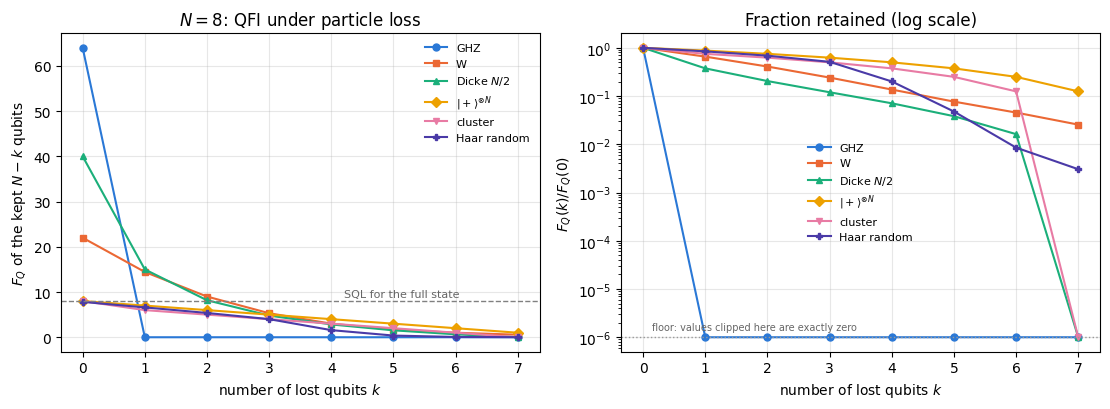

In [32]:
# ==============================================================================
# FIGURE: metrological power lost with the particles
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.2))
ks = np.arange(N_LOSS)
for j, (name, psi, n) in enumerate(loss_states):
    axes[0].plot(ks, loss_tab[name], MARKERS[j % 6] + "-", color=PALETTE[j % 6], ms=5, label=LBL[name])
    axes[1].semilogy(ks, np.clip(loss_tab[name] / max(loss_tab[name][0], 1e-12), 1e-6, None),
                     MARKERS[j % 6] + "-", color=PALETTE[j % 6], ms=5, label=LBL[name])
axes[1].axhline(1e-6, color="0.6", ls=":", lw=1)
axes[1].text(0.15, 1.4e-6, "floor: values clipped here are exactly zero", fontsize=7, color="0.4")
axes[0].axhline(N_LOSS, color="0.5", ls="--", lw=1)
axes[0].text(4.2, N_LOSS * 1.1, "SQL for the full state", fontsize=8, color="0.4")
axes[0].set_xlabel("number of lost qubits $k$"); axes[0].set_ylabel(r"$F_Q$ of the kept $N-k$ qubits")
axes[0].set_title(f"$N={N_LOSS}$: QFI under particle loss"); axes[0].legend(fontsize=8)
axes[1].set_xlabel("number of lost qubits $k$"); axes[1].set_ylabel(r"$F_Q(k)/F_Q(0)$")
axes[1].set_title("Fraction retained (log scale)"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

The GHZ curve drops discontinuously: losing a **single** qubit takes $F_Q$ from $N^2=64$ to exactly $0$, for the reason
derived in Section 10.1. The reduced state, Eq. (107), is a mixture of two $J_z$ eigenstates, which does not change
under the encoding. All of the GHZ phase information is stored in a single global coherence, and a single lost particle
carries it away.

Everything else degrades gracefully. The **W** state loses a roughly constant factor of about $0.6$ per lost qubit
($22\to14.44\to9.00\to5.31\to\ldots$); the **Dicke** state pays a steep price for the first loss ($40\to15$) and then
settles into a similar geometric decay; the **product** state loses exactly one unit of QFI per qubit
($F_Q=N-k$, as it must, since the survivors are just $N-k$ independent qubits); the **cluster** state drops by $2$ at the
first loss and then by one unit per qubit ($F_Q=N-k-1$ for $k\ge1$); the **Haar** state follows the product state at
first and then falls steeply once half of the qubits are gone ($4.00$ at $k=3$, $1.57$ at $k=4$, $0.37$ at $k=5$). For
a random state the reduced state of fewer than $N/2$ qubits is close to maximally mixed (the Page regime), and a
maximally mixed state carries no phase information. For a resource that must survive real detectors, a graceful
decay matters more than the largest ideal value. (In the right-hand panel, curves that touch the floor at $10^{-6}$ are exactly
zero: GHZ from $k=1$ on, cluster and Dicke at $k=7$.)

> **Physics insight.** This is the quantitative version of the folklore "GHZ states are fragile, Dicke and squeezed states
> are robust". Notebook 37 revisits it as a systematic study of QFI versus particle loss, and notebook 34 shows where along
> a one-axis-twisting evolution the trade-off is best.

## 16. Performance: the total cost

Three regimes, three scalings:

| quantity | algorithm | time | memory |
|---|---|---|---|
| $F_Q$ of a pure state | `qfi_pure`: $N$ einsums plus two inner products | $O(N2^N)$ | $O(2^N)$ |
| $3\times3$ QFI matrix | three collective applications plus a $3\times3$ `eigh` | $O(N2^N)$ | $O(2^N)$ |
| $F_Q$ of a mixed state, Eq. (49) | dense eigendecomposition of $\rho$ | $O(8^N)$ | $O(4^N)$ |
| $F_Q$ of a subsystem, compressed | thin QR plus a small `eigh` | $O\!\left(8^{\min(K,N-K)}\right)$ | $O(2^N)$ |

Let us measure the first and the last, separating compile time from run time as always.

In [33]:
# ==============================================================================
# STEP 18: measured cost of the matrix-free QFI, and of Schmidt compression
# ==============================================================================
print("Pure-state QFI, F_Q = 4 Var(J_z), matrix-free (jit-compiled)\n")
print(f"{'N':>3s} {'dim 2^N':>9s} | {'compile [ms]':>13s} {'run [ms]':>10s} {'F_Q':>10s}")
qfi_rows = []
for N in (6, 8, 10, 12, 14, 16):
    f = jax.jit(lambda p: qfi_pure(p, Z))
    val, tc, tr = timed(f, ghz_state(N))
    qfi_rows.append((N, tc, tr))
    print(f"{N:3d} {2 ** N:9d} | {tc * 1e3:13.1f} {tr * 1e3:10.3f} {float(val):10.1f}")

print("\nSubsystem QFI at N=12, keeping K qubits: compression on and off\n")
print(f"{'K':>3s} {'d_A':>7s} {'d_B':>6s} | {'compressed run [ms]':>20s} {'naive run [ms]':>16s} {'speed-up':>9s}")
psi12 = haar_state(jax.random.PRNGKey(2), 12)
comp_rows = []
for K in (2, 4, 6, 8, 9, 10, 11):
    fc = jax.jit(partial(subsystem_qfi, n_dir=(0, 0, 1), K=K, compress=True))
    _, _, tr_c = timed(fc, psi12)
    if K <= 9:                                     # the naive route becomes painfully slow beyond this
        fn = jax.jit(partial(subsystem_qfi, n_dir=(0, 0, 1), K=K, compress=False))
        _, _, tr_n = timed(fn, psi12)
    else:
        tr_n = float("nan")
    comp_rows.append((K, tr_c, tr_n))
    print(f"{K:3d} {2 ** K:7d} {2 ** (12 - K):6d} | {tr_c * 1e3:20.3f} {tr_n * 1e3:16.3f} {tr_n / tr_c:9.1f}")

Pure-state QFI, F_Q = 4 Var(J_z), matrix-free (jit-compiled)

  N   dim 2^N |  compile [ms]   run [ms]        F_Q
  6        64 |          85.4      0.017       36.0


  8       256 |         100.1      0.028       64.0
 10      1024 |         122.3      0.064      100.0


 12      4096 |         254.8      0.200      144.0


 14     16384 |         172.8      0.761      196.0


 16     65536 |         217.1      1.930      256.0

Subsystem QFI at N=12, keeping K qubits: compression on and off

  K     d_A    d_B |  compressed run [ms]   naive run [ms]  speed-up


...

  6      64     64 |                0.885            0.901       1.0


  8     256     16 |                0.522           10.541      20.2


  9     512      8 |                0.335           81.242     242.9


 10    1024      4 |                0.257              nan       nan


 11    2048      2 |                0.239              nan       nan


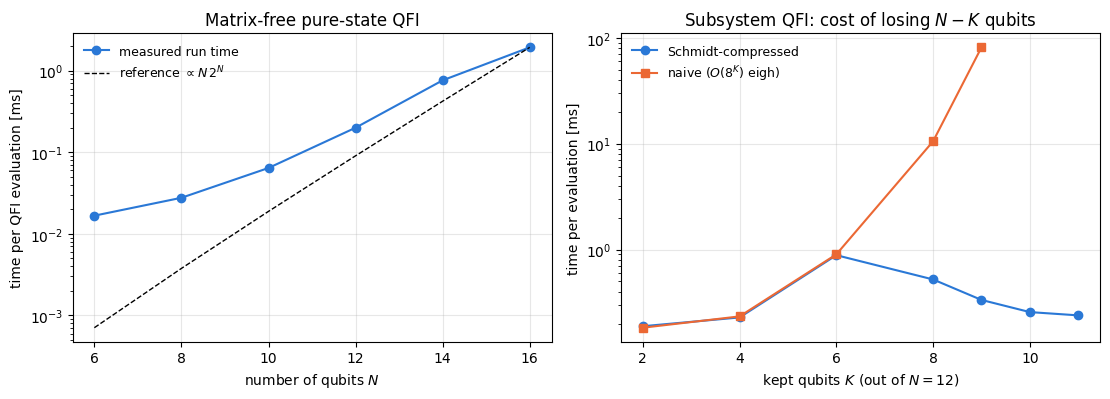

In [34]:
# ==============================================================================
# FIGURE: measured scaling
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.1))
Nq = np.array([r[0] for r in qfi_rows], dtype=float)
tq = np.array([r[2] for r in qfi_rows]) * 1e3
axes[0].semilogy(Nq, tq, "o-", color=PALETTE[0], label="measured run time")
ref = tq[-1] * (Nq / Nq[-1]) * 2.0 ** (Nq - Nq[-1])
axes[0].semilogy(Nq, ref, "k--", lw=1, label=r"reference $\propto N\,2^N$")
axes[0].set_xlabel("number of qubits $N$"); axes[0].set_ylabel("time per QFI evaluation [ms]")
axes[0].set_title("Matrix-free pure-state QFI"); axes[0].legend(fontsize=9)

Kk = np.array([r[0] for r in comp_rows], dtype=float)
axes[1].semilogy(Kk, np.array([r[1] for r in comp_rows]) * 1e3, "o-", color=PALETTE[0], label="Schmidt-compressed")
mask = ~np.isnan([r[2] for r in comp_rows])
axes[1].semilogy(Kk[mask], np.array([r[2] for r in comp_rows])[mask] * 1e3, "s-", color=PALETTE[1],
                 label=r"naive ($O(8^K)$ eigh)")
axes[1].set_xlabel("kept qubits $K$ (out of $N=12$)"); axes[1].set_ylabel("time per evaluation [ms]")
axes[1].set_title("Subsystem QFI: cost of losing $N-K$ qubits"); axes[1].legend(fontsize=9)
fig.tight_layout(); plt.show()

The left panel is to be read as a comparison of *slopes*: the dashed reference is only fixed up to a constant, and
it has been anchored at the last point. Below $N\approx10$ the measured curve is almost flat: the arithmetic there is
faster than the fixed cost of dispatching a compiled program from Python (a few tens of microseconds), so the
measurement reports the overhead rather than the algorithm. Above $N\approx10$ it turns over and climbs steadily. The ratio
of successive run times there depends on the machine and on its load: on an idle machine we measured a factor of about
$2.5$–$4$ per additional pair of qubits, below the $4\,(N+2)/N\approx4.7$ that counting operations predicts (the constant
overhead has not fully disappeared at $N=12$, and the largest einsums are the first ones big enough for XLA to spread
across several cores), while on a loaded machine the largest sizes compete for cores and the ratio can exceed $4.7$.
The lesson is the one every benchmark teaches: an $O(\cdot)$ is a statement about arithmetic, a timing is a statement
about one machine at one moment, and they coincide only in the window where neither dispatch nor parallelism dominates.
At $N=16$ (a $65\,536$-dimensional space) one QFI evaluation takes milliseconds (about $2$ ms on an idle machine; the
printed value depends on the load during the build), so a sweep over hundreds of parameters is a matter of seconds. Compare that with the dense alternative: a
$2^{16}\times2^{16}$ complex matrix
would need $69$ GB.

The right panel is the point of Schmidt compression. Without it the cost rises steeply with the number of *kept* qubits and
becomes unusable near $K=N$ — precisely the physically interesting regime of losing one or two particles. With compression
the run time is essentially flat in $K$; the two curves coincide for $K\le6$ (where $d_A\le d_B$ and the compression branch
is not taken at all) and separate sharply afterwards, reaching the speed-up printed above at $K=9$. At $K=11$ the naive
route would have to diagonalise a $2048\times2048$ matrix that we know in advance has rank at most $2$.

> **Numerical practice.** Whenever a matrix is built as $\Psi\Psi^\dagger$ from a tall-and-thin $\Psi$, its rank is bounded
> by the thin dimension. Never hand such a matrix to a general eigensolver — project onto the column span first. The same
> idea appears as "low-rank updates" in optimisation and as "active subspace" methods in uncertainty quantification.

## 17. Key takeaways

* **Estimation theory works for any meter.** A meter is described by the distribution $p(x\vert\theta)$ of its readings.
  The score $\partial_\theta\ln p$ has zero mean, its mean square is the classical Fisher information
  $F_C=\sum_x(\partial_\theta p)^2/p=-\mathbb E[\partial_\theta^2\ln p]$, which adds up over $M$ repetitions, and every
  locally unbiased estimator obeys $\mathrm{Var}\ge1/(MF_C)$ (Cauchy–Schwarz on the covariance of estimator and score,
  Section 4.5). Equality at finite $M$ requires an exponential family; maximum likelihood reaches the bound
  asymptotically, which we measured with error bars and confirmed by an exact binomial sum (bias $-\cot\theta/(2M)$,
  excess of $M\,\mathrm{Var}$ over $1/F_C$ of $1\%$ at $M=100$ for $\theta=\pi/2$).
* **For a quantum meter the measurement is a choice, and $F_Q$ bounds every choice.** With $p(x\vert\theta)=\mathrm{Tr}(E_x\rho_\theta)$
  and the symmetric logarithmic derivative $\partial_\theta\rho=\tfrac12(L\rho+\rho L)$, the quantum Fisher information
  $F_Q=\mathrm{Tr}(\rho L^2)$ satisfies $F_C\le F_Q$ for every POVM, with equality in the eigenbasis of $L$
  (Braunstein–Caves, proved in Section 5.3 and tested on 600 random POVMs); hence $\Delta\theta\ge1/\sqrt{MF_Q}$.
* **For pure states $F_Q$ reduces analytically to $4\,\mathrm{Var}(G)$.** $L=2\partial_\theta\rho$ solves the SLD
  equation, $F_Q=4(\langle\dot\psi\vert\dot\psi\rangle-\vert\langle\psi\vert\dot\psi\rangle\vert^2)$ for any curve, and
  $4\,\mathrm{Var}(G)$ for unitary encoding, independent of $\theta$. Geometrically $\sqrt{F_Q}/2$ is the speed of the
  state, since the fidelity of neighbouring states is $1-F_Q\delta^2/4$. Matrix-free it costs $O(N2^N)$.
* **Two limits, both proved and measured.** A product state has $F_Q\le N$ (single-spin variances add), every state
  $F_Q\le N^2$ (the spectrum of $J_z$ has width $N$), and the GHZ state reaches $N^2$ through its parity fringe
  $\cos(N\theta)$. The GHZ gain is a factor $N$ in Fisher information and $\sqrt N$ in error over $N$ unentangled spins,
  and simulated maximum-likelihood estimates follow $1/\sqrt{NM}$ and $1/(N\sqrt M)$.
* **The GHZ advantage is fragile.** One lost particle sets $F_Q$ to exactly zero; independent dephasing gives
  $N^2(1-2p)^{2N}$, optimal at $N^\ast=-1/\ln(1-2p)$ and below the product state beyond a crossing; collective dephasing
  destroys the GHZ coherence at a rate $\propto N^2$ (superdecoherence, fitted exponent $2$) and limits every probe to
  $F_Q\le F_Q^{(0)}/(1+F_Q^{(0)}\sigma^2)<1/\sigma^2$, and a detection error
  $\epsilon$ reduces the parity contrast by $(1-2\epsilon)^N$.
* **The state alone does not decide.** $F_Q$ is a property of the pair (state, generator). The $3\times3$ matrix
  $\mathcal F_{ab}=4C_{ab}$ makes the direction dependence explicit, $F_Q(\mathbf n)=\mathbf n^{\mathsf T}\mathcal F\mathbf n$,
  and the optimum over the sphere is the largest eigenvalue of a $3\times3$ matrix — one `eigh`, no optimisation.
* **Entanglement is necessary but not sufficient.** $F_Q>\lfloor N/k\rfloor k^2+(N\bmod k)^2$ certifies entanglement
  depth $k+1$; yet Haar-random states (near-maximal entropy) sit at $F_Q\approx N d/(d+1)$, just below the SQL, and the cluster state
  beats $N$ only by a boundary term $2$. Metrology rewards coherent superpositions of very different generator
  eigenvalues, which the entanglement entropy does not measure.
* **Noise and loss, beyond GHZ.** Mixed-state QFI under three channels decays exponentially in $N$ for the GHZ state at
  fixed error probability. States that degrade gracefully under loss, such as the Dicke state (which keeps $15$ of its
  $40$ after one lost qubit at $N=8$), are the better candidates for real detectors.
* **Implementation.** Validate every new quantity against at least two independent routes before plotting it (we used
  matrix-free, dense, SLD, finite differences and `jax.jacfwd`), and pair every check with a wrong control that must fail; exploit rank structure (Schmidt compression turned an
  $O(8^K)$ eigendecomposition into an $O(8^{N-K})$ one, more than two orders of magnitude at $K=9$, $N=12$ in our runs).

## 18. Exercises

1. ★ **Read the bound.** A magnetometer uses $N=100$ atoms and $M=10^4$ repetitions. Compute the smallest phase
   uncertainty $\Delta\theta$ allowed at the standard quantum limit and at the Heisenberg limit, and the factor between
   them. Then use Eq. (111) to find the per-qubit dephasing probability $p$ at which the GHZ advantage is entirely lost,
   i.e. at which $N^2(1-2p)^{2N}=N$.
2. ★ **Fisher information of a tilted readout.** For the single qubit of Section 6.6, compute analytically and then with
   `fisher_information_ad` the Fisher information of a measurement along the direction
   $\mathbf m=(\cos\alpha,\sin\alpha,0)$ in the equatorial plane. Show that $p(\pm)=\left(1\pm\cos(\theta-\alpha)\right)/2$
   and that $F_C(\theta)$ is the *same* for every $\alpha$, so that a whole family of readouts saturates the quantum
   Cramér–Rao bound. Then set $\alpha=\theta$, so that the fringe sits at an extremum: what does
   `fisher_information_ad` return, what is the limit of $F_C$ as $\alpha\to\theta$, and which of the two conditions of
   Section 4.7 has been violated?
3. ★★ **Dicke states are a family (physics).** Compute $F_Q$ for $\vert D_N^k\rangle$ with $G=J_x$ for all
   $k=0,\dots,N$ at $N=10$ and plot it against $k$. Derive the closed form from
   $\langle J_x^2\rangle=\tfrac12[j(j+1)-m^2]$ with $j=N/2$, $m=N/2-k$, and check your formula against the numbers.
   Which $k$ is optimal and why is $k=N/2$ not a coincidence?
4. ★★ **Superposition of the useless (extend the code).** Take two Haar-random states $\vert\psi_1\rangle,\vert\psi_2\rangle$
   at $N=8$ and compute $F_Q$ of $(\vert\psi_1\rangle+e^{i\varphi}\vert\psi_2\rangle)/\mathcal N$ for $\varphi\in[0,2\pi)$.
   Two metrologically useless states — how useful can their superposition be? Then repeat with the *pair*
   $\vert0\cdots0\rangle$ and $\vert1\cdots1\rangle$, each of which has $F_Q=0$ for $G=J_z$. Explain both results with
   Eq. (75): what property of the two summands decides whether the superposition gains anything?
5. ★★ **Optimal direction along a twisting evolution (extend the code).** Evolve $\vert+\rangle^{\otimes N}$ with the
   engine's `oat_evolve` for a range of twisting times, and plot $\lambda_{\max}(\mathcal F)$ together with the three
   Cartesian values $F_Q(J_x),F_Q(J_y),F_Q(J_z)$. By how much does choosing the optimal direction beat the best Cartesian
   one? (This is a preview of notebook 34.)
6. ★★ **Noise before or after (extend the code).** Section 14 applied the channel *before* the encoding. Redo the
   dephasing sweep with the channel applied *after* $U(\theta)$ and compare. Then do the same for $G=J_x$ instead of
   $G=J_z$. Which combinations give identical results, and what property of the channel explains it? (Notebook 30 answers
   this in detail — try to get there first.)
7. ★★★ **The cluster state's boundary (physics).** We found $\lambda_{\max}(\mathcal F)=N+2$ for the open cluster chain.
   Verify that the excess disappears for the *periodic* cluster state (`cluster_state(N, periodic=True)`), identify the
   stabiliser responsible for the off-diagonal elements of $\mathcal F$ in the open chain, and confirm your explanation by
   computing the relevant correlator with `expect_pauli_string`.
8. ★★★ **A better lossy resource (extend the code).** Search numerically for the pure symmetric state of $N=8$ qubits that
   maximises $F_Q$ of the reduced state *after losing one qubit*. Parametrise a state in the symmetric (Dicke) subspace by
   $N+1$ complex amplitudes, use `jax.grad` on `subsystem_qfi` and Adam, and compare the optimum with GHZ, with
   $\vert D_N^{N/2}\rangle$, and with the ideal $F_Q=N^2$. How much of the Heisenberg advantage can survive one lost particle?
   *Hint on the numerics:* `subsystem_qfi` differentiates through `jnp.linalg.eigh`, whose gradient is undefined when two
   eigenvalues coincide. Starting from a random complex vector of amplitudes the gradient is finite, but a symmetric
   starting point such as GHZ sits exactly on a degeneracy and returns `nan`; start away from it, and check
   `jnp.isfinite` on the gradient before feeding it to the optimiser.

## References

* C. W. Helstrom, *Quantum Detection and Estimation Theory* (Academic Press, New York, 1976) — the book that founded
  quantum estimation theory; the symmetric logarithmic derivative and the quantum Cramér–Rao bound.
* S. L. Braunstein and C. M. Caves, *Statistical distance and the geometry of quantum states*,
  Phys. Rev. Lett. **72**, 3439 (1994) — the inequality of Section 5.3: the classical Fisher information of every
  measurement is bounded by the quantum Fisher information, attained in the eigenbasis of the SLD; the geometric
  (statistical-distance) reading of Section 6.4.
* V. Giovannetti, S. Lloyd and L. Maccone, *Quantum-enhanced measurements: beating the standard quantum limit*,
  Science **306**, 1330 (2004), and *Quantum metrology*, Phys. Rev. Lett. **96**, 010401 (2006) — the standard quantum
  limit versus the Heisenberg limit.
* L. Pezzè and A. Smerzi, *Entanglement, nonlinear dynamics, and the Heisenberg limit*,
  Phys. Rev. Lett. **102**, 100401 (2009) — Eq. (121): $F_Q>N$ witnesses entanglement.
* P. Hyllus, W. Laskowski, R. Krischek, C. Schwemmer, W. Wieczorek, H. Weinfurter, L. Pezzè and A. Smerzi,
  *Fisher information and multiparticle entanglement*, Phys. Rev. A **85**, 022321 (2012), and
  G. Tóth, *Multipartite entanglement and high-precision metrology*, Phys. Rev. A **85**, 022322 (2012) — Eq. (122),
  the entanglement-depth bound for $k$-producible states.
* M. G. A. Paris, *Quantum estimation for quantum technology*, Int. J. Quantum Inf. **7**, 125–137 (2009) — a compact and
  very readable review of everything in Sections 3–7.
* L. Pezzè, A. Smerzi, M. K. Oberthaler, R. Schmied and P. Treutlein, *Quantum metrology with nonclassical states of
  atomic ensembles*, Rev. Mod. Phys. **90**, 035005 (2018) — the standard modern review; collective spins, Dicke states,
  squeezing, experiments.
* G. Tóth and I. Apellaniz, *Quantum metrology from a quantum information science perspective*,
  J. Phys. A **47**, 424006 (2014) — the entanglement-witness side of the QFI, with proofs of the convexity and of the
  $k$-producibility bounds.
* H. Cramér, *Mathematical Methods of Statistics* (Princeton University Press, 1946) — the classical Cramér–Rao bound and
  the asymptotic theory of maximum likelihood.
* E. L. Lehmann and G. Casella, *Theory of Point Estimation*, 2nd ed. (Springer, New York, 1998) — the information
  inequality, efficient estimators and exponential families, and the asymptotic efficiency of maximum likelihood.
* S. F. Huelga, C. Macchiavello, T. Pellizzari, A. K. Ekert, M. B. Plenio and J. I. Cirac, *Improvement of frequency
  standards with quantum entanglement*, Phys. Rev. Lett. **79**, 3865 (1997) — under Markovian dephasing during the
  interrogation, maximally entangled states give the same resolution as uncorrelated atoms (Section 10.4).
* T. Monz, P. Schindler, J. T. Barreiro, M. Chwalla, D. Nigg, W. A. Coish, M. Harlander, W. Hänsel, M. Hennrich and
  R. Blatt, *14-qubit entanglement: creation and coherence*, Phys. Rev. Lett. **106**, 130506 (2011) — GHZ coherence
  decaying with the square of the number of qubits under correlated phase noise (Section 10.3).

---
**About these lectures.** Written by Marcin Płodzień as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*.

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/